# Comparison of Machine Learning and Additive Approaches to a QSAR Study of Distamycin Analogues

### Baris Ganidagli and David E. Thurston

### School of Cancer & Pharmaceutical Sciences, King's College London, Faculty of Life Sciences & Medicine, Franklin-Wilkins Building, 150 Stamford Street, London SE1 9NH, United Kingdom

### Corresponding author: david.thurston@kcl.ac.uk

**Supporting Information**

This notebook contains the complete computational pipeline used in the manuscript. Running it from start to finish reproduces all figures and tables reported in the manuscript, except for Figures 1, 2 and 6, which are structure figures.

The dataset consists of distamycin analogues from Boger et al. (1, 2), divided into labelled and unlabelled sets, with the numbers given in Section 2.1. We use scaffold-based cross-validation and compare an interpretable Free-Wilson model with four fingerprint-based machine learning models. Bayesian Ridge gives the best results of the four fingerprint models and is the primary model throughout the analysis. An RF-GP ensemble was also constructed and is reported in Section 8 for comparison. Under scaffold cross-validation, the Free-Wilson model gives similar results to the fingerprint models, with the metrics reported in Section 9.6, 9.7 and 12. The complete pipeline takes around 60 minutes to run on an Apple M4 MacBook Air using all available cores (n_jobs=-1).

The 2,640 member library and the processed dataset are generated by `library_generation.ipynb`, which is included in the deposited archive. All code, data and trained models are available in the repository deposited at 10.5281/zenodo.22882946.

### Contents

Figures S1 to S8 and Tables S1 to S7 are numbered according to where they are cited in the manuscript, so their numbering is not sequential in this notebook. The remaining figures and tables are numbered in the order in which they appear. The table below lists the figures and tables in the order they appear here.

| Section | Item | Contents |
|---|---|---|
| 2 | Figure S9 | ChEMBL L1210 neighbour structures |
| 3.1 | Figure 3A | Distribution of pIC₅₀ across the labelled set |
| 3.2 | Figure S10 | Ten most frequent Bemis-Murcko scaffolds |
| 4.2 | Figure S11 | Descriptor correlation matrix |
| 4.3 | Figure S12 | First two principal components of the descriptors |
| 4.4 | Figure S13 | pIC₅₀ against each descriptor |
| 4.4 | Figure 3B | Descriptor correlations with pIC₅₀ |
| 5.1 | Table S8 | Composition of the scaffold-CV folds |
| 5.1 | Table S9 | Methods summary |
| 6.4 | Table S10 | Non-tuned model performance |
| 7.2 | Table S6 | Selected hyperparameters from the grid search |
| 7.3 | Table S11 | Non-tuned against tuned model performance |
| 7.4 | Figure S14 | Training against scaffold-CV performance |
| 7.5 | Table S4 | Nested scaffold-CV results |
| 7.6 | Table S1 | Scaffold-CV RMSE by feature block |
| 7.6 | Table S2 | Scaffold-CV R² by feature block |
| 7.6 | Table S3 | Full feature-block results |
| 8.1 | Table S12 | Per-fold ensemble weights |
| 8.1 | Table S7 | Ensemble weight search results |
| 8.2 | Figure S3 | Ensemble out-of-fold RMSE against GP contribution |
| 9.1 | Table S13 | Final scaffold-CV results |
| 9.2 | Table S14 | In-sample model performance |
| 9.4 | Figure S15 | Random Forest impurity-based feature importances |
| 9.5 | Figure S4 | SHAP beeswarm for the tuned Random Forest |
| 9.5 | Figure S5 | Mean absolute SHAP per feature |
| 9.5 | Figure S6 | Substructure encoded by fingerprint bit 192 |
| 9.6 | Figure S1 | Free-Wilson contributions, combined A coding |
| 9.7 | Table S15 | Free-Wilson and fingerprint ensemble on 90 compounds |
| 9.7 | Figure 4 | Fragment contributions, split A coding |
| 9.8 | Figure S7 | Predicted against measured pIC₅₀, external set |
| 9.8 | Figure S8 | Measured and predicted ranges, external set |
| 9.9 | Figure 5 | Fragment contributions against lipophilicity |
| 9.9 | Figure S16 | Panel A of Figure 5 split by cap |
| 11.2 | Table S16 | Calibration of GP uncertainty against RMSE |
| 11.2 | Figure S17 | Ensemble RMSE against mean GP uncertainty |
| 11.3 | Figure S2 | Reliability diagram for GP prediction intervals |
| 11.6 | Table S5 | Gaussian Process kernel comparison |
| 12 | Table S17 | Summary of key quantitative results |

## 1. Computational Environment and Reproducibility

A single seed (SEED = 42) fixes every randomised step in the main pipeline. That covers the Random Forest, the Gaussian Process kernel restarts, XGBoost subsampling, and scaffold fold assignment. There are two deliberate exceptions. The first is the outer loop of the nested cross-validation, which uses a different seed so its folds are independent of the tuning folds, and the second is the seed-sensitivity checks in Sections 8.1 and 9.7, which sweep a set of fold-construction seeds. Nothing inside the fold loop uses a random number, because the folds are built once before the loop and each estimator carries its own seed.

The repository copy of this notebook retains the input code, whereas the Supporting Information PDF is generated from the same notebook with inputs hidden. Table captions are emitted from the cells that produce them and are visible only in the executed form. Figure captions are markdown and are visible either way.

In [1]:
from pathlib import Path
import sys

def find_project_root(markers=("requirements.txt", ".git", "README.md")):
    here = Path.cwd().resolve()
    for parent in (here, *here.parents):
        if any((parent / m).exists() for m in markers):
            return parent
    raise RuntimeError(f"No project-root marker {markers} found above {here}")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

DATA_PROC = PROJECT_ROOT / "data" / "processed"
RESULTS_FIG = PROJECT_ROOT / "results" / "figures"
RESULTS_PRED = PROJECT_ROOT / "results" / "predictions"
MODELS_DIR = PROJECT_ROOT / "saved_models"

In [2]:
import random
import shap
import functools
from collections import Counter
import logging
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from importlib.metadata import version
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import norm, pearsonr, spearmanr, hypergeom, ConstantInputWarning
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown, HTML
import joblib
from itertools import combinations

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API"
)

try:
    from chembl_webresource_client.new_client import new_client
    from chembl_webresource_client.settings import Settings
except Exception:
    new_client = Settings = None

from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.linear_model import BayesianRidge, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBRegressor

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Draw, Descriptors, rdFingerprintGenerator, Descriptors3D, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D

from modules.scaffolds import get_scaffold, scaffold_split
from modules.standardise import canonical_smiles
from modules.kernels import TanimotoKernel
from modules.freewilson import build_X, ridge_cv, tobit_cv, scaffold_smiles
from modules.featurisation import smiles_to_fp_desc, featurise_molecules, get_morgan_fps
from modules.validation import foldwise_cv, run_grid_search
from modules.prediction import (
    load_and_clean_dataset,
    build_pipeline, gp_predict_with_std,
    ensemble_predictions, search_ensemble_weights,
    compute_applicability_domain
)
from modules.builders import build_rf, build_gp, build_xgb, build_br

In [3]:
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'axes.grid': False,
    'legend.frameon': False,
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.prop_cycle': mpl.cycler(color=['#2B6CB0', '#444444', '#E07A3F', '#3B9C77', '#9B59B6']),
})

def show(df):
    """Display a DataFrame without the row-index column."""
    display(HTML(df.to_html(index=False, na_rep="—")))

In [4]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

_pkgs = ["scikit-learn", "xgboost", "rdkit", "numpy", "pandas", "scipy",
         "matplotlib", "seaborn", "statsmodels", "shap", "joblib",
         "chembl-webresource-client", "pillow", "ipython"]
print("Python environment:")
print(" | ".join(f"{p} {version(p)}" for p in _pkgs))

Python environment:
scikit-learn 1.7.2 | xgboost 3.1.1 | rdkit 2025.9.1 | numpy 2.3.3 | pandas 2.3.2 | scipy 1.16.2 | matplotlib 3.10.6 | seaborn 0.13.2 | statsmodels 0.14.6 | shap 0.51.0 | joblib 1.5.2 | chembl-webresource-client 0.10.9 | pillow 11.3.0 | ipython 9.5.0


### Output Directory Initialisation

Output directories for figures, results tables and saved models are created at runtime.

In [5]:
for path in [
    RESULTS_FIG / "eda",
    RESULTS_FIG / "model_evaluation",
    RESULTS_FIG / "predictions",
    RESULTS_PRED / "labelled",
    MODELS_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

## 2. Dataset Cleaning and Processing

### 2.1 Dataset Loading and Cleaning

| Field | Value |
|-------|-------|
| Target | L1210 murine leukaemia cytotoxicity IC₅₀ |
| Assay type | Cell-based cytotoxicity assay |
| IC₅₀ units | µM |
| Primary data source 1 | Boger, Fink and Hedrick, JACS 2000 |
| Primary data source 2 | Boger, Dechantsreiter, Ishii, Fink and Hedrick, Bioorganic and Medicinal Chemistry 2000 |

The modelling dataset comes from `processed_data.csv`, which is generated by `library_generation.ipynb` from the enumerated Boger distamycin library together with a small set of hand-drawn literature additions. Duplicate canonical SMILES have already been removed.

The final dataset contains 116 labelled and 2,535 unlabelled compounds, giving 2,651 unique structures. The labelled compounds have L1210 IC₅₀ values taken from the Boger papers. Where the assay reported only an assay limit, the value is retained at that limit and flagged for the sensitivity analysis in Section 10.

The labelled and unlabelled compounds come from the same distamycin series. The unlabelled compounds are included to describe the full dataset but are not ranked or nominated. As shown by the external validation in Section 9.8, the predicted range is too narrow to distinguish compounds within this series.

In [6]:
labelled_df, unlabelled_df = load_and_clean_dataset(DATA_PROC / "processed_data.csv", verbose=False)

In [7]:
n_before = len(unlabelled_df)
unlabelled_df = unlabelled_df.drop_duplicates(subset="SMILES").reset_index(drop=True)
print(f"Unlabelled: {n_before} rows - {len(unlabelled_df)} unique SMILES "
      f"({n_before - len(unlabelled_df)} exact duplicates removed)")

Unlabelled: 2535 rows - 2535 unique SMILES (0 exact duplicates removed)


In [8]:
n_labelled = len(labelled_df)
n_unlabelled = len(unlabelled_df)
n_constructed = n_labelled + n_before
n_appended = n_constructed - 2640

print(f"Construction total: {n_constructed} ({n_constructed - n_appended} combinatorial + {n_appended} appended)")
print(f"Working set: {n_labelled} labelled + {n_unlabelled} unlabelled = {n_labelled + n_unlabelled}")

Construction total: 2651 (2640 combinatorial + 11 appended)
Working set: 116 labelled + 2535 unlabelled = 2651


The deduplication step above is only a check, since duplicate canonical SMILES have already been removed during library generation. A few unlabelled compounds are very similar to labelled compounds by Tanimoto similarity, but none are exact duplicates. The unlabelled compounds are not ranked or nominated anywhere in this notebook, so their similarity to the labelled set is only considered in the applicability-domain check in Section 10.2.

In [9]:
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

RDLogger.DisableLog("rdApp.*")
for _noisy in ("chembl_webresource_client", "urllib3", "requests"):
    logging.getLogger(_noisy).setLevel(logging.ERROR)

L1210_TARGET = "CHEMBL386"
SIM_THRESHOLD = 0.70

labelled_parents = [p for p in (canonical_smiles(s, desalt=True) for s in labelled_df["SMILES"]) if p]
labelled_canon = set(labelled_parents)
labelled_fps = get_morgan_fps(labelled_parents)
print(f"Labelled compounds after desalting: {len(labelled_parents)} ({len(labelled_canon)} unique)")

chembl_cache = DATA_PROC / "chembl_l1210_neighbours.csv"

if chembl_cache.exists():
    cached = pd.read_csv(chembl_cache)
    if "nn_library" not in cached.columns:
        _clean_lib = pd.read_csv(DATA_PROC / "cleandata.csv")
        _lib_parents = [p for p in (canonical_smiles(s, desalt=True)
                                    for s in _clean_lib["SMILES"]) if p]
        _lib_fps = get_morgan_fps(_lib_parents)
        cached["nn_library"] = [
            round(max(DataStructs.BulkTanimotoSimilarity(fp, _lib_fps)), 3)
            for fp in get_morgan_fps(cached["smiles"].tolist())
        ]
        print(f"Library similarity calculated against {len(_lib_fps)} enumerated compounds")
    hits = list(zip(cached["chembl_id"], cached["nn_tanimoto"],
                    cached["smiles"], cached["nn_library"]))
    print(f"Loaded {len(hits)} external L1210 neighbours from cached records ({chembl_cache.name})")
else:
    Settings.Instance().TIMEOUT = 60
    Settings.Instance().TOTAL_RETRIES = 5

    activity = new_client.activity
    records = activity.filter(target_chembl_id=L1210_TARGET).only(
        ["molecule_chembl_id", "canonical_smiles"])

    seen = {}
    for i, r in enumerate(records, start=1):
        cid = r.get("molecule_chembl_id")
        smi = r.get("canonical_smiles")
        if cid and smi and cid not in seen:
            seen[cid] = smi
        if i % 1000 == 0:
            print(f"Retrieved {i} activity records so far ({len(seen)} unique compounds)")
    print(f"Retrieved {len(seen)} unique L1210 compounds from ChEMBL ({L1210_TARGET})")

    new_ids, new_smiles = [], []
    for cid, smi in seen.items():
        parent = canonical_smiles(smi, desalt=True)
        if parent is None or parent in labelled_canon:
            continue
        if Chem.MolFromSmiles(parent) is None:
            continue
        new_ids.append(cid)
        new_smiles.append(parent)

    print(f"ChEMBL parents kept for comparison: {len(new_smiles)}")
    new_fps = get_morgan_fps(new_smiles)

    clean = pd.read_csv(DATA_PROC / "cleandata.csv")
    library_parents = [p for p in (canonical_smiles(s, desalt=True) for s in clean["SMILES"]) if p]
    library_fps = get_morgan_fps(library_parents)
    print(f"Retention reference: {len(labelled_fps)} labelled compounds | "
          f"reported for context only: {len(library_fps)} enumerated library members")

    hits = []
    for cid, smi, fp in zip(new_ids, new_smiles, new_fps):
        nn_lab = max(DataStructs.BulkTanimotoSimilarity(fp, labelled_fps))
        if nn_lab >= SIM_THRESHOLD:
            nn_lib = max(DataStructs.BulkTanimotoSimilarity(fp, library_fps))
            hits.append((cid, round(nn_lab, 3), smi, round(nn_lib, 3)))

print(f"External ChEMBL L1210 compounds with Tanimoto >= {SIM_THRESHOLD} to the 116 labelled compounds: {len(hits)}")
assert min(h[1] for h in hits) >= SIM_THRESHOLD, \
    "a retained neighbour falls below the labelled-set threshold, cache and live code disagree"
for h in sorted(hits, key=lambda h: -h[1]):
    cid, nn, smi = h[0], h[1], h[2]
    extra = f"  NN(library)={h[3]}"
    print(f"{cid}  NN Tanimoto={nn}{extra}  {smi}")

Labelled compounds after desalting: 116 (116 unique)
Library similarity calculated against 2640 enumerated compounds
Loaded 24 external L1210 neighbours from cached records (chembl_l1210_neighbours.csv)
External ChEMBL L1210 compounds with Tanimoto >= 0.7 to the 116 labelled compounds: 24
CHEMBL540264  NN Tanimoto=1.0  NN(library)=0.441  Cn1cc(NC(=O)c2cc(NC(=O)c3cc(NC(=O)c4cc(NC=O)cn4C)cn3C)cn2C)cc1C(=O)NCCC(=N)N
CHEMBL307254  NN Tanimoto=0.778  NN(library)=0.446  Cn1cc(NC(=O)c2cc(NC(=O)Nc3cc(C(=O)Nc4cc(C(=O)NCCC(=N)N)n(C)c4)n(C)c3)cn2C)cc1C(=O)NCCC(=N)N
CHEMBL76734  NN Tanimoto=0.766  NN(library)=0.556  Cn1cc(NC(=O)c2cc(NC(=O)CCCC(=O)Nc3cc(C(=O)Nc4cc(C(=O)NCCC(=N)N)n(C)c4)n(C)c3)cn2C)cc1C(=O)NCCC(=N)N
CHEMBL76369  NN Tanimoto=0.766  NN(library)=0.556  Cn1cc(NC(=O)c2cc(NC(=O)CCCCC(=O)Nc3cc(C(=O)Nc4cc(C(=O)NCCC(=N)N)n(C)c4)n(C)c3)cn2C)cc1C(=O)NCCC(=N)N
CHEMBL308990  NN Tanimoto=0.761  NN(library)=0.519  Cn1cc(NC(=O)c2cc(NC(=O)CCC(=O)Nc3cc(C(=O)Nc4cc(C(=O)NCCC(=N)N)n(C)c4)n(C)c3)cn2C)cc1

In [10]:
if not chembl_cache.exists():
    hits_df = pd.DataFrame([(h[0], h[1], h[2], h[3]) for h in hits],
                           columns=["chembl_id", "nn_tanimoto", "smiles", "nn_library"])
    hits_df = hits_df.drop_duplicates(subset="smiles").reset_index(drop=True)
    hits_df.to_csv(chembl_cache, index=False)
    print(f"Saved {len(hits_df)} distinct external neighbours to {chembl_cache.name}")
else:
    hits_df = pd.read_csv(chembl_cache)
    print(f"Using cached {chembl_cache.name} with {len(hits_df)} compounds, not rewritten")

Using cached chembl_l1210_neighbours.csv with 24 compounds, not rewritten


In [11]:
nbr = pd.read_csv(DATA_PROC / "chembl_l1210_neighbours.csv")
ids = nbr["chembl_id"].tolist()
_rec_cache = DATA_PROC / "chembl_l1210_activity_records.csv"

raw = None
if _rec_cache.exists():
    raw = pd.read_csv(_rec_cache)
    print(f"Loaded {len(raw)} activity records from cache ({_rec_cache.name})")
else:
    try:
        recs = new_client.activity.filter(
            target_chembl_id="CHEMBL386",
            molecule_chembl_id__in=ids,
        ).only(["molecule_chembl_id","standard_type","standard_relation",
                "standard_value","standard_units"])
        raw = pd.DataFrame(list(recs))
        raw.to_csv(_rec_cache, index=False)
        print(f"Retrieved {len(raw)} activity records from ChEMBL and saved to {_rec_cache.name}")
    except Exception as e:
        print(f"ChEMBL unavailable and no cache present, skipping this check. ({type(e).__name__})")

if raw is not None:
    print(f"\nTotal activity records for these {len(ids)} compounds: {len(raw)}")
    print("\nBy measurement type:")
    print(raw["standard_type"].value_counts(dropna=False))
    print("\nBy units:")
    print(raw["standard_units"].value_counts(dropna=False))
    print("\nUnique compounds with a numeric value:",
          raw.loc[raw["standard_value"].notna(),"molecule_chembl_id"].nunique())

Loaded 39 activity records from cache (chembl_l1210_activity_records.csv)

Total activity records for these 24 compounds: 39

By measurement type:
standard_type
ID50                19
IC50                 6
Inhibition           5
IPol                 3
Resistance index     2
OD                   2
R.I                  2
Name: count, dtype: int64

By units:
standard_units
ug ml-1    19
nM          8
NaN         6
%           5
ug.mL-1     1
Name: count, dtype: int64

Unique compounds with a numeric value: 24


In [12]:
alkylator_smarts = {
    "acrylamide":     "C=CC(=O)N",
    "haloacetyl":     "[Cl,Br,F]CC(=O)N",
    "dihaloacetyl":   "[Cl,Br,F][CH]([Cl,Br,F])C(=O)N",
    "trihaloacetyl":  "C([Cl,Br,F])([Cl,Br,F])([Cl,Br,F])C(=O)N",
    "haloacrylamide": "[Cl,Br,F]/C=C/C(=O)N",
}
alk_patts = {k: Chem.MolFromSmarts(v) for k, v in alkylator_smarts.items()}

alkylators = []
for cid, nn, smi in zip(hits_df["chembl_id"], hits_df["nn_tanimoto"], hits_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    flags = [k for k, p in alk_patts.items() if p and mol.HasSubstructMatch(p)]
    if flags:
        alkylators.append(cid)
        print(f"{cid:14} nn={nn}  {','.join(flags)}")

print(f"\nAlkylator-capped compounds: {len(alkylators)} of {len(hits_df)}")

CHEMBL332748   nn=0.7  haloacetyl,dihaloacetyl
CHEMBL116032   nn=0.714  haloacetyl,trihaloacetyl
CHEMBL116694   nn=0.714  haloacetyl
CHEMBL116666   nn=0.729  haloacetyl
CHEMBL554387   nn=0.735  acrylamide
CHEMBL539359   nn=0.735  acrylamide
CHEMBL544214   nn=0.72  acrylamide,haloacrylamide
CHEMBL2093930  nn=0.72  acrylamide,haloacrylamide

Alkylator-capped compounds: 8 of 24


Eight of the 24 ChEMBL neighbours have a reactive alkylating cap, including acrylamide, haloacetyl, dihaloacetyl, trihaloacetyl or haloacrylamide. These compounds act through covalent DNA alkylation rather than by reversible minor groove binding, so they differ from the mechanism of the labelled compounds. They are kept in the external comparison set because the measured endpoint is 50% growth inhibition in L1210 in all cases, but they are excluded from interpretation of the additive fragment model and any SAR conclusions.

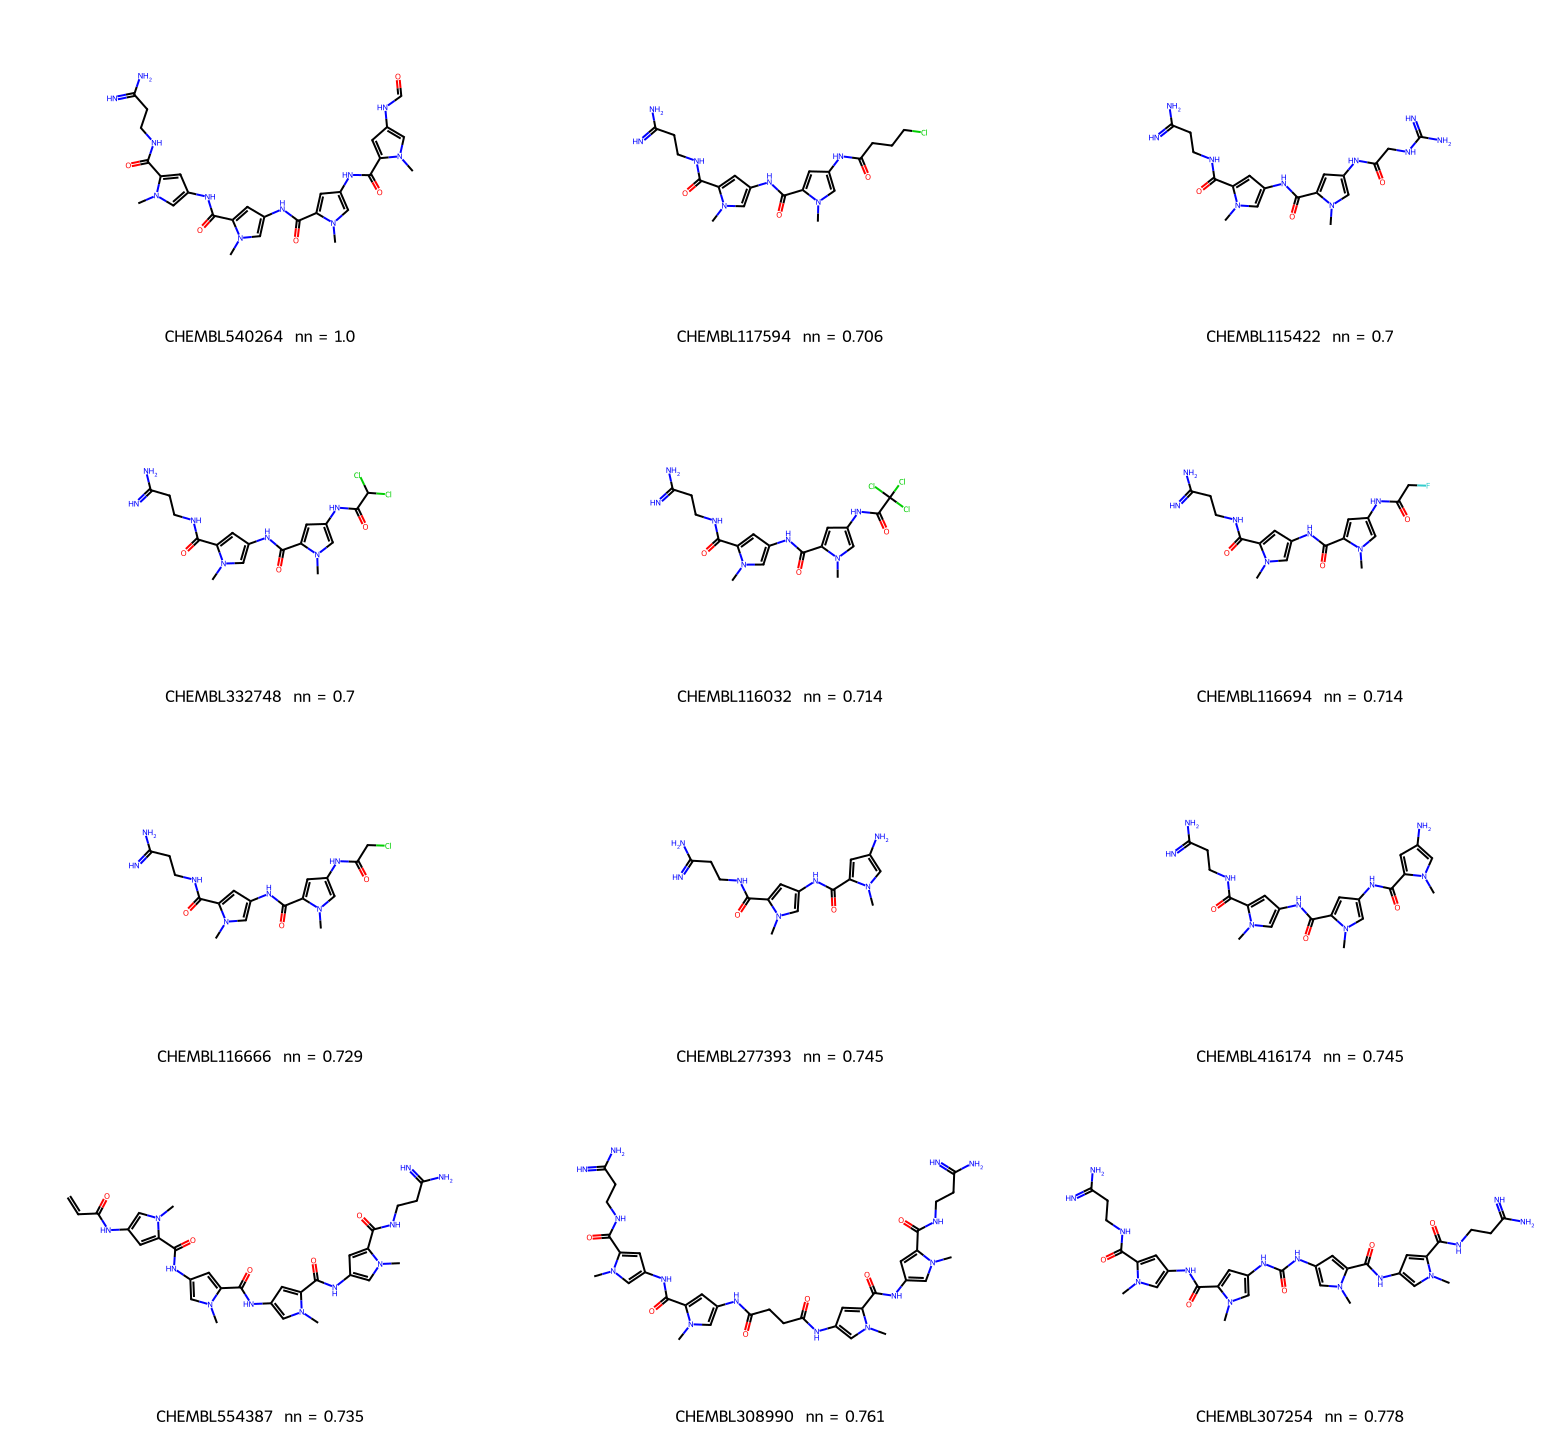

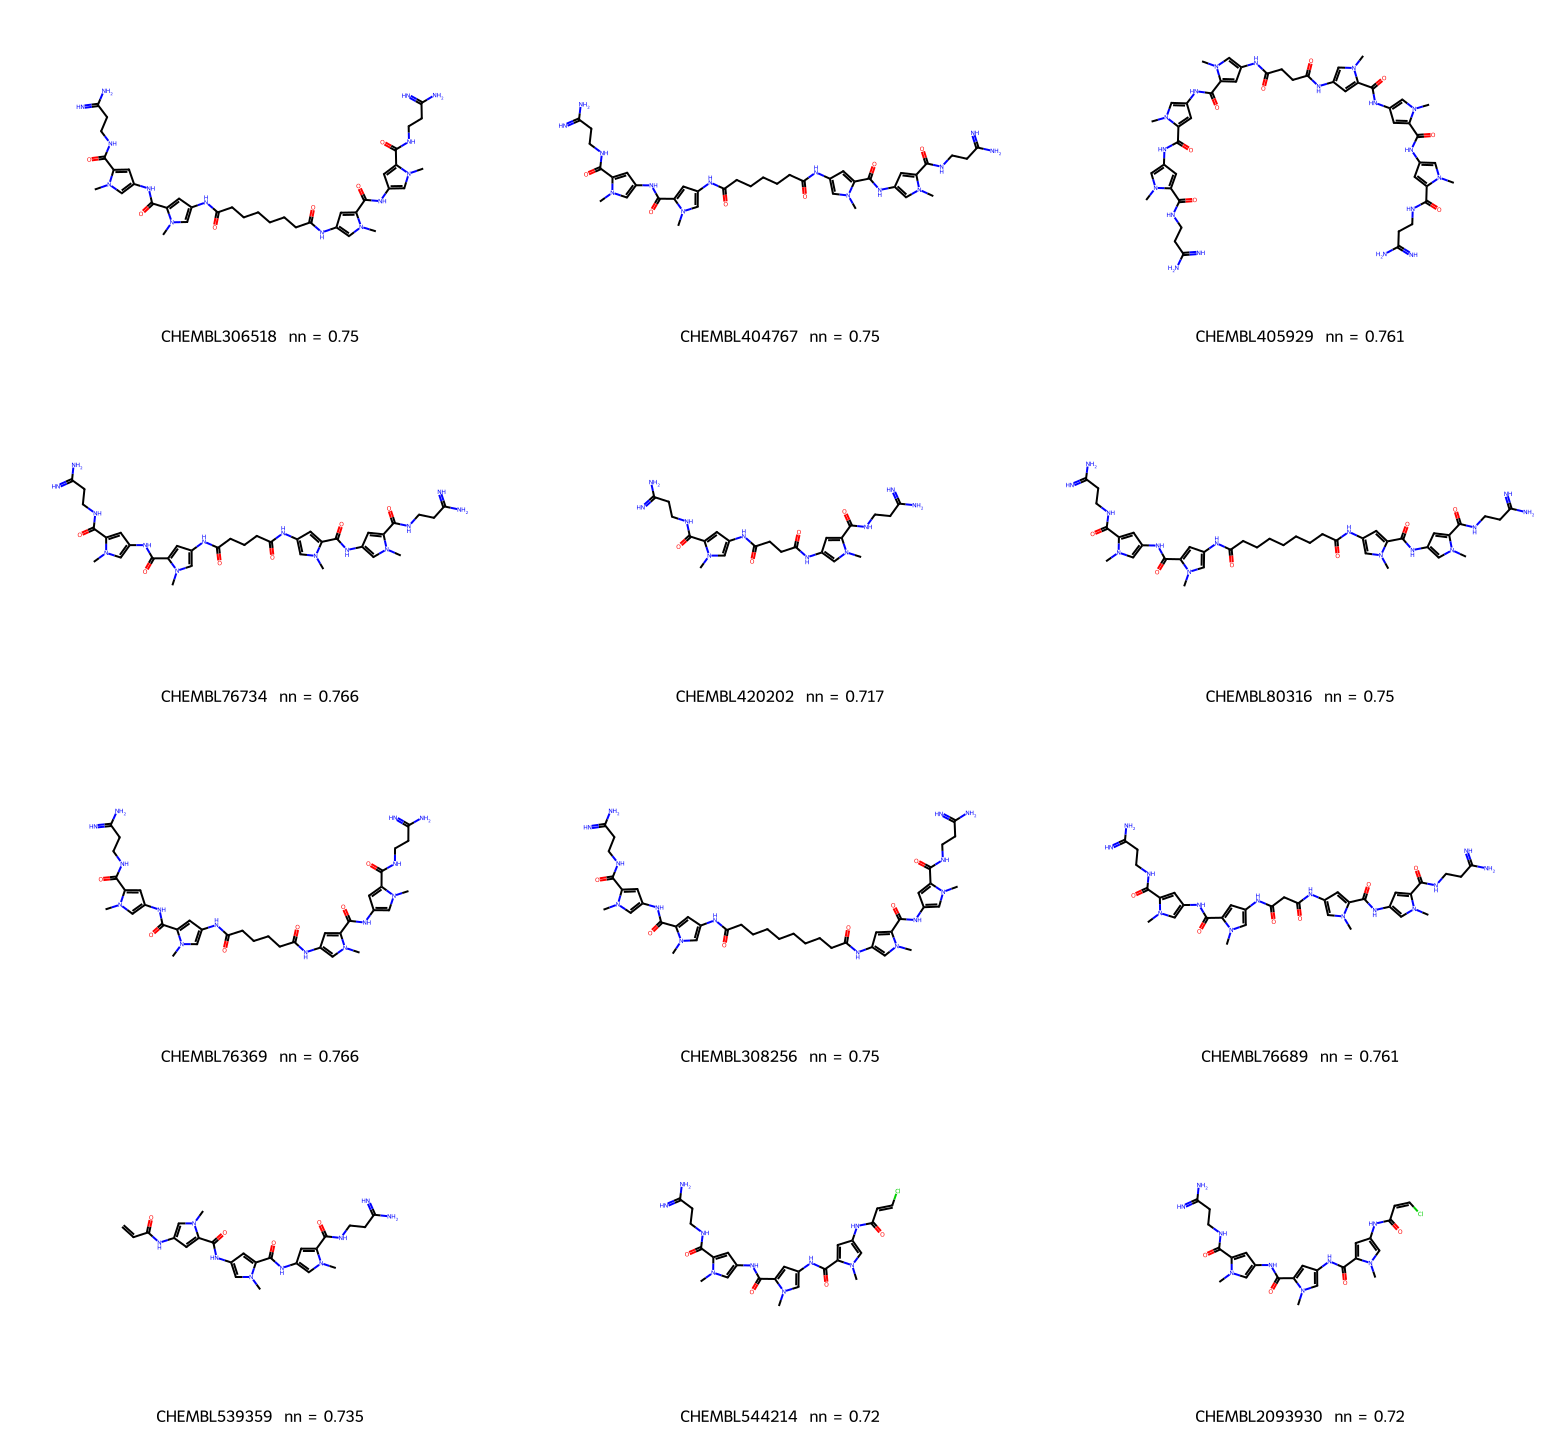

In [13]:
mols = [Chem.MolFromSmiles(s) for s in hits_df["smiles"]]
legends = [f"{cid}  nn = {nn}" for cid, nn in zip(hits_df["chembl_id"], hits_df["nn_tanimoto"])]

img_a = Draw.MolsToGridImage(mols[:12], molsPerRow=3, subImgSize=(520, 360),
                             legends=legends[:12], returnPNG=False)
img_b = Draw.MolsToGridImage(mols[12:], molsPerRow=3, subImgSize=(520, 360),
                             legends=legends[12:], returnPNG=False)
img_a.save(RESULTS_FIG / "eda" / "chembl_l1210_neighbours_a.png")
img_b.save(RESULTS_FIG / "eda" / "chembl_l1210_neighbours_b.png")
display(img_a)
display(img_b);

**Figure S9.** Structures of the 24 ChEMBL L1210 neighbours with Tanimoto similarity of 0.70 or higher to the 116 labelled compounds, shown in two groups of twelve. Each structure is labelled with its ChEMBL ID and nearest neighbour Tanimoto similarity.

Similarity to the enumerated library ranges from 0.410 to 0.556 across the 24 compounds, despite their Tanimoto similarity of 0.70 or higher to the labelled set. Their closest labelled compounds are the non-combinatorial literature additions rather than compounds from the combinatorial library. The external check in Section 9.8 therefore tests the model close to the 11 literature additions rather than across the wider enumerated library.

### 2.2 Dataset Summary

In [14]:
print("Labelled compounds:")
print(labelled_df[["IC50", "pIC50"]].describe())

_unc = labelled_df.loc[~labelled_df["censored"].fillna(False).astype(bool), "IC50"].astype(float)
_all = labelled_df["IC50"].astype(float)
print(f"\nIC₅₀ range (all 116 compounds): {_all.min():g}-{_all.max():g} µM "
      f"({_all.max()/_all.min():.0f}-fold)")
print(f"IC₅₀ range ({len(_unc)} uncensored compounds): {_unc.min():g}-{_unc.max():g} µM "
      f"({_unc.max()/_unc.min():.0f}-fold)")

print(f"\nUnlabelled compounds: {len(unlabelled_df)} (no measured IC50)")

Labelled compounds:
              IC50       pIC50
count   116.000000  116.000000
mean     55.847569    4.894676
std     137.649261    0.898903
min       0.029000    3.000000
25%       2.700000    4.332621
50%      30.500000    4.515759
75%      46.500000    5.568636
max    1000.000000    7.537602

IC₅₀ range (all 116 compounds): 0.029-1000 µM (34483-fold)
IC₅₀ range (101 uncensored compounds): 0.029-420 µM (14483-fold)

Unlabelled compounds: 2535 (no measured IC50)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of Labelled pIC₅₀

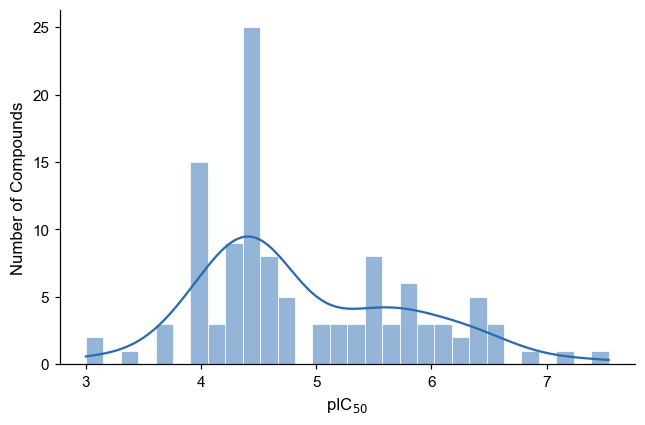

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(labelled_df['pIC50'], bins=30, kde=True,
             color='#2B6CB0', edgecolor='white', linewidth=0.5)
plt.xlabel('pIC$_{50}$')
plt.ylabel('Number of Compounds')
plt.tight_layout()
plt.savefig(RESULTS_FIG / "eda" / "pIC50_distribution.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure 3A.** Distribution of pIC₅₀ across the 116 labelled compounds using 30 equal width bins. The 15 censored labels are included at their substituted boundary values.

Most of the potency values are around pIC₅₀ 4.5 and decrease towards 7.5. Fifteen of the labelled compounds are censored values recorded at the assay boundary rather than measured at that value. These occur at three limits, with two at pIC₅₀ 3.0 (>1000 µM), twelve at 4.0 (>100 µM) and one at 5.0 (>10 µM). The IC₅₀ values are lower bounds and therefore the corresponding pIC₅₀ values are upper bounds. The effect of these censored values is assessed in Section 10.

### 3.2 Molecular Scaffold Analysis

Murcko scaffold frequencies (3) show the 116 compounds across different scaffolds. The same scaffold groups are used in Section 5 to construct the cross-validation folds.

Ten most frequent scaffolds:
                                                Scaffold  Count
            O=C(Nc1c[nH]c(C(=O)Nc2cc[nH]c2)c1)c1ccc[nH]1      8
   O=C(Nc1ccc2sc(C(=O)Nc3cc[nH]c3)cc2c1)c1cc2ccccc2[nH]1      6
              O=C(Nc1c[nH]c(C(=O)Nc2cc[nH]c2)c1)c1ccccc1      4
       O=C(Nc1csc(C(=O)N2CCc3c2ccc2[nH]ccc32)c1)c1ccccc1      4
  O=C(Nc1c[nH]cn1)c1cc2c3c(ccc2[nH]1)N(C(=O)c1ccccc1)CC3      4
           O=C(Nc1ccc2sc(C(=O)Nc3cc[nH]c3)cc2c1)c1ccccc1      4
     O=C(Nc1csc(C(=O)N2CCc3c2ccc2[nH]ccc32)c1)c1ccc[nH]1      2
O=C(Nc1c[nH]cn1)c1cc2c3c(ccc2[nH]1)N(C(=O)c1ccc[nH]1)CC3      2
         O=C(Nc1ccc2sc(C(=O)Nc3cc[nH]c3)cc2c1)c1ccc[nH]1      2
           O=C(Nc1ccc2oc(C(=O)Nc3c[nH]cn3)cc2c1)c1ccccc1      2


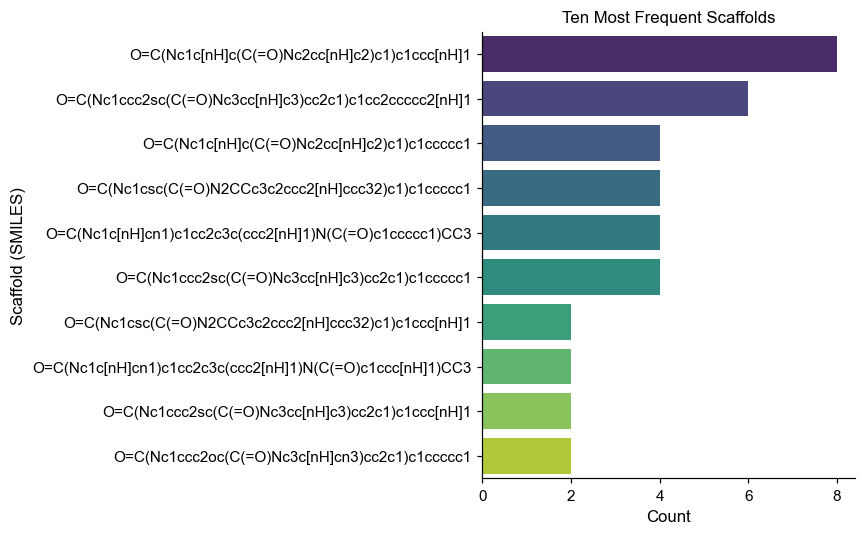

In [16]:
scaffolds = [
    Chem.MolToSmiles(get_scaffold(smi))
    for smi in labelled_df['SMILES']
    if Chem.MolFromSmiles(smi) is not None
]

counts = Counter(scaffolds)
scaffold_counts_df = pd.DataFrame(counts.most_common(10), columns=['Scaffold', 'Count'])

print("Ten most frequent scaffolds:")
print(scaffold_counts_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Count', y='Scaffold', data=scaffold_counts_df,
            hue='Scaffold', palette='viridis', legend=False)
plt.title('Ten Most Frequent Scaffolds')
plt.xlabel('Count')
plt.ylabel('Scaffold (SMILES)')
plt.tight_layout()
plt.savefig(RESULTS_FIG / "eda" / "top_scaffolds.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S10.** Ten most frequent Bemis-Murcko scaffolds in the labelled set, shown by compound count (n = 116).

In [17]:
sizes = Counter(counts.values())
n_scaffolds = len(counts)
n_singletons = sizes.get(1, 0)
print(f"{n_scaffolds} distinct Murcko scaffolds within {len(scaffolds)} labelled compounds")
print(f"Singleton scaffolds: {n_singletons}")
print(f"Largest scaffold: {max(counts.values())} compounds")

print("\nScaffold size and number of scaffolds:")
for size in sorted(sizes):
    print(f"  {size:>2} : {sizes[size]}")

61 distinct Murcko scaffolds within 116 labelled compounds
Singleton scaffolds: 24
Largest scaffold: 8 compounds

Scaffold size and number of scaffolds:
   1 : 24
   2 : 31
   4 : 4
   6 : 1
   8 : 1


## 4. Molecular Featurisation and Descriptor Analysis

### 4.1 Molecular Featurisation

Each molecule is represented by 1030 features derived from a 1024-bit Morgan fingerprint and six physicochemical descriptors. All features are retained throughout the modelling process. The same 1024-bit fingerprints are used for the models and the Tanimoto similarity in the applicability domain analysis.

In [18]:
X_labelled_full = featurise_molecules(labelled_df['SMILES'])
X_unlabelled_full = featurise_molecules(unlabelled_df['SMILES'])
y_labelled = labelled_df['pIC50'].values

train_fps = get_morgan_fps(labelled_df['SMILES'])
unlabelled_fps = get_morgan_fps(unlabelled_df['SMILES'])

print(f"Featurised {len(train_fps)} labelled and {len(unlabelled_fps)} unlabelled compounds")
print(f"Feature matrix: {X_labelled_full.shape}")

Featurised 116 labelled and 2535 unlabelled compounds
Feature matrix: (116, 1030)


In [19]:
variance_selector = VarianceThreshold(threshold=0.01)
variance_selector.fit(X_labelled_full)
n_original = X_labelled_full.shape[1]
n_remaining = variance_selector.transform(X_labelled_full).shape[1]

print(f"Original features: {n_original}")
print(f"Low-variance features (variance < 0.01): {n_original - n_remaining} of {n_original} "
      f"({100*(n_original - n_remaining)/n_original:.1f}%)")

Original features: 1030
Low-variance features (variance < 0.01): 846 of 1030 (82.1%)


### 4.2 Physicochemical Descriptor Analysis

Descriptor matrix shape: (116, 6)


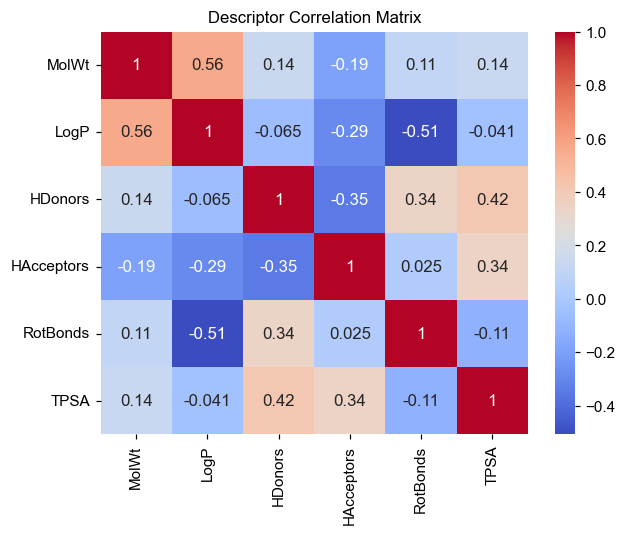

In [20]:
desc_cols = ['MolWt', 'LogP', 'HDonors', 'HAcceptors', 'RotBonds', 'TPSA']

desc_array = np.vstack([
    np.array(smiles_to_fp_desc(smi)[1]).flatten()
    for smi in labelled_df['SMILES']
])
desc_df = pd.DataFrame(desc_array, columns=desc_cols)
print(f"Descriptor matrix shape: {desc_array.shape}")

plt.figure(figsize=(6,5))
sns.heatmap(desc_df.corr(), annot=True, cmap='coolwarm')
plt.title("Descriptor Correlation Matrix")
plt.tight_layout()
plt.savefig(RESULTS_FIG / "eda" / "descriptor_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

**Figure S11.** Pearson correlation matrix for the six physicochemical descriptors in the labelled set (n = 116).

### 4.3 PCA of Physicochemical Descriptors

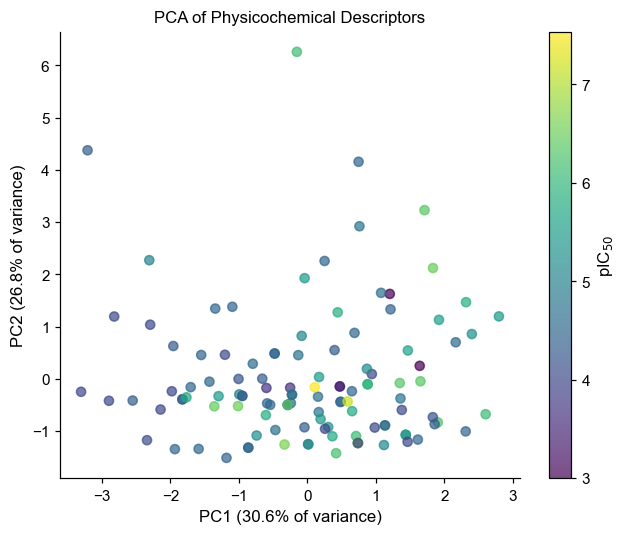

Variance explained: PC1 30.6%, PC2 26.8%, cumulative 57.4%


In [21]:
pca = PCA(n_components=2, svd_solver='randomized', random_state=SEED)
pca_proj = pca.fit_transform(StandardScaler().fit_transform(desc_array))
_ev = 100 * pca.explained_variance_ratio_

plt.figure(figsize=(6,5))
plt.scatter(pca_proj[:,0], pca_proj[:,1], c=y_labelled, cmap='viridis', alpha=0.7)
plt.colorbar(label='pIC$_{50}$')
plt.xlabel(f'PC1 ({_ev[0]:.1f}% of variance)')
plt.ylabel(f'PC2 ({_ev[1]:.1f}% of variance)')
plt.title('PCA of Physicochemical Descriptors')
plt.tight_layout()
plt.savefig(RESULTS_FIG / "eda" / "pca_descriptors.png", dpi=300, bbox_inches='tight')
plt.show();
print(f"Variance explained: PC1 {_ev[0]:.1f}%, PC2 {_ev[1]:.1f}%, cumulative {_ev.sum():.1f}%")

**Figure S12.** First two principal components of the six standardised physicochemical descriptors in the labelled set (n = 116). The percentage of variance explained is shown on each axis.

The PCA does not show a clear separation by potency. The most potent compounds are spread across the plot rather than grouped together. The six physicochemical descriptors therefore do not show a clear pattern in the data. Section 9.9 examines this further. The first two components explain 57.4% of the total variance, meaning that 42.6% of the variance is represented by the remaining four components.

### 4.4 pIC₅₀ vs Physicochemical Descriptors

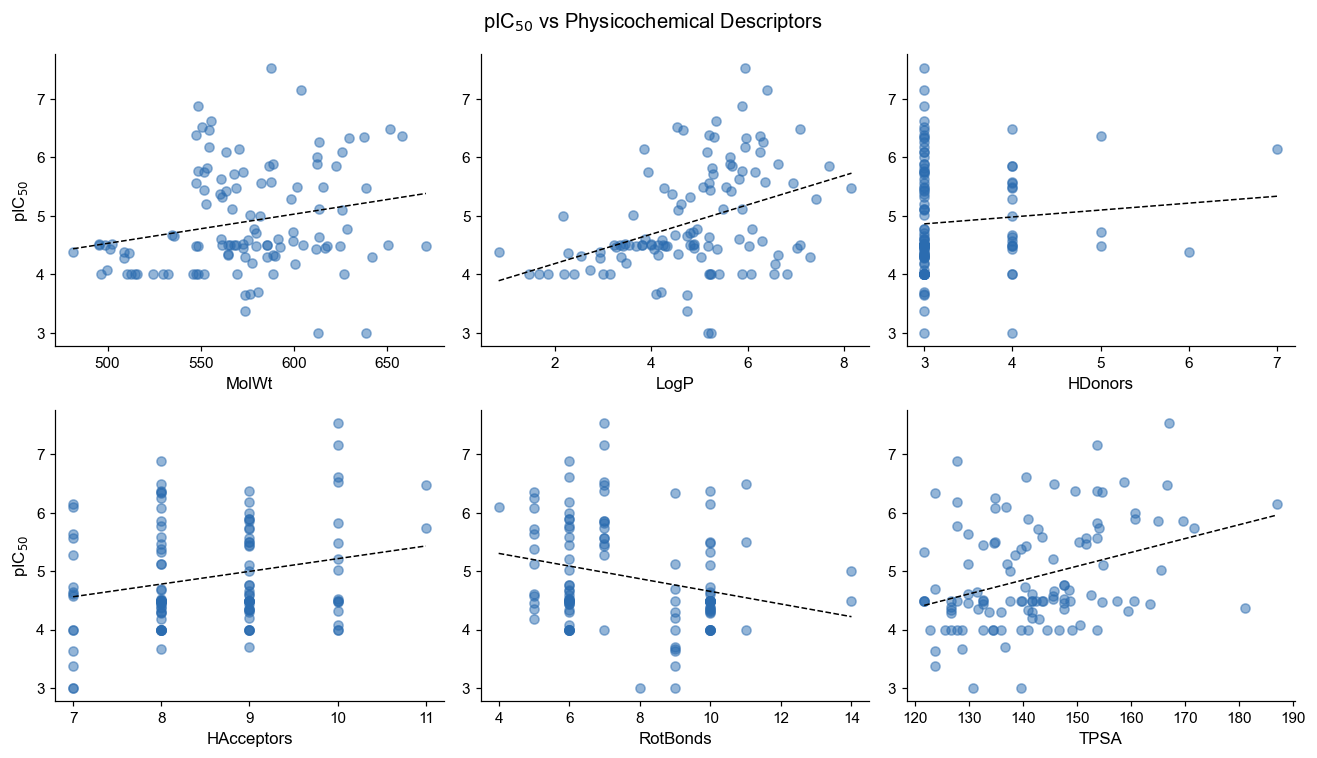

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.flatten(), desc_cols):
    ax.scatter(desc_df[col], y_labelled, alpha=0.5)
    _m, _b = np.polyfit(desc_df[col], y_labelled, 1)
    _xs = np.linspace(desc_df[col].min(), desc_df[col].max(), 50)
    ax.plot(_xs, _m * _xs + _b, "k--", lw=1)
    ax.set_xlabel(col)
for ax in axes[:, 0]:
    ax.set_ylabel('pIC$_{50}$')
plt.suptitle('pIC$_{50}$ vs Physicochemical Descriptors')
plt.tight_layout()
plt.savefig(RESULTS_FIG / "eda" / "pIC50_vs_descriptors.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S13.** pIC₅₀ against each of the six physicochemical descriptors for the labelled set (n = 116), with least squares trend lines.

Descriptor correlations with pIC₅₀ (Bonferroni corrected for 6 tests):
  LogP        r=+0.396  p_raw=1.09e-05  p_bonf=6.57e-05  Significant
  TPSA        r=+0.350  p_raw=0.000119  p_bonf=0.000714  Significant
  RotBonds    r=-0.258  p_raw=0.00525  p_bonf=0.0315  Significant
  HAcceptors  r=+0.229  p_raw=0.0134  p_bonf=0.0807  Not significant
  MolWt       r=+0.223  p_raw=0.0159  p_bonf=0.0953  Not significant
  HDonors     r=+0.084  p_raw=0.368  p_bonf=1  Not significant


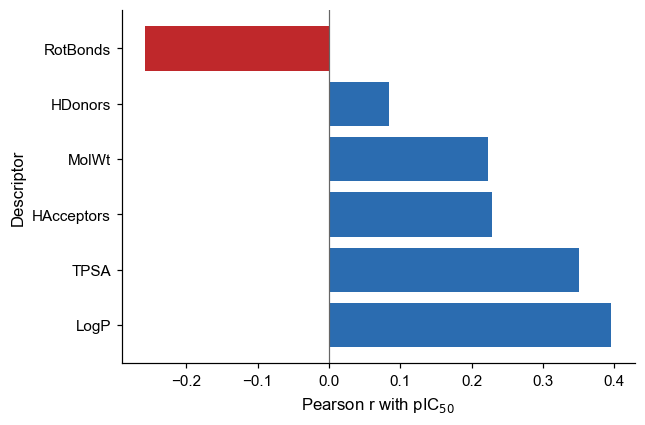

In [23]:
corr_rows = []
for col in desc_cols:
    r_d, p_d = pearsonr(desc_df[col], y_labelled)
    corr_rows.append({"Descriptor": col, "Pearson_r": r_d, "p_raw": p_d})

corr_desc_df = pd.DataFrame(corr_rows)
corr_desc_df["p_bonferroni"] = multipletests(corr_desc_df["p_raw"], method="bonferroni")[1]
corr_desc_df["resolved_at_0.05"] = corr_desc_df["p_bonferroni"] < 0.05
corr_desc_df = (corr_desc_df
                .reindex(corr_desc_df["Pearson_r"].abs()
                         .sort_values(ascending=False).index)
                .reset_index(drop=True))

print("Descriptor correlations with pIC₅₀ (Bonferroni corrected for 6 tests):")
for row in corr_desc_df.itertuples():
    print(f"  {row.Descriptor:11s} r={row.Pearson_r:+.3f}  p_raw={row.p_raw:.3g}  "
          f"p_bonf={row.p_bonferroni:.3g}  {'Significant' if row._5 else 'Not significant'}")

_plot_df = corr_desc_df.sort_values("Pearson_r").reset_index(drop=True)

plt.figure(figsize=(6, 4))
_bar_colours = ['#2B6CB0' if r > 0 else '#bf282b' for r in _plot_df["Pearson_r"]]
plt.barh(_plot_df["Descriptor"], _plot_df["Pearson_r"], color=_bar_colours)
plt.axvline(0, color='0.4', linewidth=0.8)
plt.xlabel('Pearson r with pIC$_{50}$')
plt.ylabel('Descriptor')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_FIG / "eda" / "descriptor_pIC50_correlations.png",
            dpi=300, bbox_inches='tight')
plt.show()

corr_desc_df.to_csv(RESULTS_PRED / "labelled" / "descriptor_pIC50_correlations.csv",
                    index=False)

**Figure 3B.** Pearson correlation between each of the six physicochemical descriptors and pIC₅₀ across the 116 labelled compounds, ordered from strongest negative to strongest positive correlation. LogP, TPSA and rotatable bonds remain significant after Bonferroni correction. Molecular weight, hydrogen bond acceptors and hydrogen bond donors do not.

LogP shows the clearest positive correlation, which is consistent with hydrophobic contact contributing to potency in this series. TPSA also shows a positive correlation while rotatable bonds show a negative correlation. All three remain significant after Bonferroni correction. Molecular weight and hydrogen bond acceptors show weak positive correlations, while hydrogen bond donors show almost no correlation. These three are not significant after correction, so we report the direction and strength of the correlations without interpreting them further.

## 5. Scaffold-Based Cross-Validation

Scaffold-based cross-validation groups molecules by their Bemis-Murcko scaffold (3). The scaffold contains the ring systems and the linkers connecting them, with the side chains removed. We generate the scaffolds using RDKit's `MurckoScaffold.GetScaffoldForMol` and keep all compounds with the same scaffold in the same fold. This prevents similar compounds from appearing in both the training and test sets and gives a more realistic estimate of model performance on compounds with different scaffolds.

In [24]:
n_splits = 5
folds = scaffold_split(labelled_df, n_splits=n_splits, random_state=SEED)
print(f"Created {n_splits} scaffold-based folds")

Created 5 scaffold-based folds


In [25]:
scaffold_folds = {}
for fold_id, test_idx in enumerate(folds):
    for idx in test_idx:
        scaf = get_scaffold(labelled_df.iloc[idx]['SMILES'])
        key = Chem.MolToSmiles(scaf) if scaf is not None else None
        scaffold_folds.setdefault(key, set()).add(fold_id)

leaked = [s for s, fs in scaffold_folds.items() if len(fs) > 1]
assert not leaked, f"Scaffold leakage: {len(leaked)} scaffold(s) span multiple folds"
assert sum(len(f) for f in folds) == len(labelled_df), "Fold sizes do not sum to N"
print(f"{len(scaffold_folds)} scaffold groups across {n_splits} folds")

61 scaffold groups across 5 folds


Groups are assigned from largest to smallest, with each group placed in the smallest fold at the time. This keeps the fold sizes as even as possible.

Fold size is the main limitation here. Each test fold holds about 23 molecules, so fold level R² is unstable. It can be negative, as seen in the worst outer fold in Section 7.5. RMSE and Pearson r are more stable at this fold size, so we use them as the main metrics and treat R² as secondary. The pooled out-of-fold metrics with bootstrap intervals in Section 8.1 are more reliable and are reported for the primary model in Table S17. Differences between models smaller than the fold-to-fold RMSE variation, about 0.04 to 0.11 pIC₅₀ units, are treated as too small to interpret and are not tested for significance.

### 5.1 Methods Summary

Table S8 shows the five scaffold-based folds and the number of compounds and distinct scaffolds in each fold.

In [26]:
fold_rows = []
for i, test_idx in enumerate(folds):
    test_set = set(test_idx)
    train_idx = [j for j in range(len(labelled_df)) if j not in test_set]
    test_scaffolds = {
        Chem.MolToSmiles(get_scaffold(smi))
        for smi in labelled_df.iloc[test_idx]['SMILES']
    }
    fold_rows.append({
        'Fold': i + 1,
        'N_train': len(train_idx),
        'N_test': len(test_idx),
        'N_scaffolds_test': len(test_scaffolds),
    })

fold_df = pd.DataFrame(fold_rows)
display(Markdown("**Table S8.** Composition of the scaffold-CV folds."))
show(fold_df)

**Table S8.** Composition of the scaffold-CV folds.

Fold,N_train,N_test,N_scaffolds_test
1,92,24,11
2,93,23,12
3,93,23,12
4,93,23,13
5,93,23,13


**Table S9.** Methods summary.

| Component | Choice | Justification |
|-----------|--------|---------------|
| CV strategy | Scaffold-based (Murcko) | Simulates structural novelty and prevents interpolation bias |
| N folds | 5 | Balances fold size and training set size |
| Fold assignment | Greedy largest-first | Reduces differences in fold size |
| Feature selection | None, full 1030-dimensional matrix | No feature selection was used. Low-variance features were only reported as a diagnostic |
| Hyperparameter selection | Scaffold-CV grid search | Used for model selection, with a nested-CV diagnostic reported for Random Forest only in Section 7.5 |
| Ensemble weights (comparison) | OOF-scored weight search, w_RF in [0, 1] | Leakage-free, but the weighting is not identifiable (Section 8) |

## 6. Model Definitions and Baseline Performance

### 6.1 Linear Models

Bayesian Ridge is used as the linear baseline. It estimates the noise precision and weight precision from the data by maximising the marginal likelihood, so the regularisation is learned from the data rather than fixed by hand. On this small and congeneric dataset, it performs better than expected and gives the lowest RMSE of the four model families under scaffold-CV (Section 7.3).

The four model families cover the main regression approaches used at this scale. These are a regularised linear model (Bayesian Ridge), a kernel model (Gaussian Process), bagging (Random Forest) and boosting (XGBoost). Support vector regression was not included because it falls into the same kernel based category as the Gaussian Process. Bayesian Ridge also provides a predictive standard deviation, so the uncertainty analysis in Section 11 is not limited to a single model. The Gaussian Process was used as the main uncertainty estimate because its uncertainty depends on the compound's position in feature space. Section 11.7 compares this with the Bayesian Ridge estimate.

In [27]:
br = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BayesianRidge())
])

### 6.2 Tree-Based Models

Random Forest and XGBoost are the two main forms of tree ensembling. Random Forest bags decorrelated trees, while XGBoost boosts trees in sequence. Both work well with high-dimensional sparse fingerprint input, but neither provides calibrated uncertainty.

In [28]:
rf_default = build_pipeline("random_forest", random_state=SEED, n_jobs=-1)

xgb_default = Pipeline([
    ('model', XGBRegressor(
        n_estimators=200,
        tree_method="hist",
        random_state=SEED,
        objective='reg:squarederror',
        n_jobs=-1,
    ))
])

### 6.3 Non-Parametric Models

The Gaussian Process (RBF + WhiteKernel) returns a full posterior, so every prediction comes with an uncertainty estimate as well as a point value. It is the expensive option at O(n³), and provides the uncertainty estimate used in the ensemble analysis. Bayesian Ridge also returns a predictive standard deviation and is compared in Section 11.7.

In [29]:
kernel_default = RBF(length_scale=5.0) + WhiteKernel(noise_level=1e-2)

gpr_default = build_pipeline("gp", kernel=kernel_default, n_restarts_optimizer=2, random_state=SEED)

### 6.4 Non-Tuned Results

In [30]:
models_baseline = {
    "Bayesian Ridge": br,
    "Random Forest": rf_default,
    "XGBoost": xgb_default,
    "Gaussian Process": gpr_default,
}

non_tuned_results = []
for name, model in models_baseline.items():
    metrics, _ = foldwise_cv(model, X_labelled_full, y_labelled, folds, return_oof=False)
    non_tuned_results.append({
        "Model": name,
        "RMSE_mean": round(metrics['RMSE_mean'], 3),
        "RMSE_std": round(metrics['RMSE_std'], 3),
        "R2_mean": round(metrics['R2_mean'], 3),
        "Pearson_r": round(metrics['Pearson_mean'], 3),
    })

non_tuned_df = pd.DataFrame(non_tuned_results)
display(Markdown("**Table S10.** Non-tuned model performance (5-fold scaffold CV)."))
show(non_tuned_df)

**Table S10.** Non-tuned model performance (5-fold scaffold CV).

Model,RMSE_mean,RMSE_std,R2_mean,Pearson_r
Bayesian Ridge,0.732,0.102,0.294,0.575
Random Forest,0.800,0.054,0.128,0.458
XGBoost,0.856,0.041,-0.017,0.414
Gaussian Process,0.747,0.112,0.264,0.547


## 7. Hyperparameter Tuning, Retraining and Performance

Each of the four models is tuned by grid search using scaffold-based CV RMSE, then retrained on the full labelled set with the chosen parameters before making any predictions. Model comparison uses the scaffold-CV metrics. The nested-CV check in Section 7.5 is run for Random Forest only.

### 7.1 Hyperparameter Tuning

The grids below cover the main regularisation parameter for each model family. Each candidate is scored using scaffold-based CV RMSE.

| Model | Parameter | Values searched |
|-------|-----------|----------------|
| Random Forest | `n_estimators` | 200, 300, 500 |
| | `max_depth` | 3, 5, 10, 20, None |
| | `min_samples_split` | 2, 5, 10 |
| | `min_samples_leaf` | 1, 2, 4 |
| Gaussian Process | `length_scale` (RBF) | 1.0, 5.0, 10.0, 20.0, 50.0 |
| | `noise_level` (WhiteKernel) | 1e-3, 1e-2, 1e-1, 3e-1, 1.0 |
| XGBoost | `n_estimators` | 200, 300, 500, 800 |
| | `max_depth` | 2, 3, 5, 7 |
| | `learning_rate` | 0.003, 0.01, 0.05, 0.1 |
| | `subsample` | 0.5, 0.7, 0.85, 1.0 |
| Bayesian Ridge | `alpha_1`, `alpha_2`, `lambda_1`, `lambda_2` | 1e-6, 1e-5, 1e-4 |
| | `fit_intercept` | True, False |

In [31]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

tuning_results = {}

def report_best(name, params, metrics):
    p = ", ".join(f"{k} = {v}" for k, v in sorted(params.items()))
    print(f"{name}\n    {p}\n"
          f"    RMSE {metrics['RMSE_mean']:.3f} ± {metrics['RMSE_std']:.3f}, "
          f"R² {metrics['R2_mean']:.3f}, Pearson r {metrics['Pearson_mean']:.3f}")

# Random Forest
rf_param_grid = {'n_estimators': [200, 300, 500],
                 'max_depth': [3, 5, 10, 20, None],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 4]}
best_rf_params, best_rf_metrics, tuning_results['Random Forest'] = run_grid_search(
    functools.partial(build_rf, SEED), rf_param_grid, folds, X_labelled_full, y_labelled)
report_best("Best RF", best_rf_params, best_rf_metrics)

# Gaussian Process
gp_param_grid = {'length_scale': [1.0, 5.0, 10.0, 20.0, 50.0],
                 'noise_level': [1e-3, 1e-2, 1e-1, 3e-1, 1.0]}
best_gp_params, best_gp_metrics, tuning_results['Gaussian Process'] = run_grid_search(
    functools.partial(build_gp, SEED), gp_param_grid, folds, X_labelled_full, y_labelled)
report_best("Best GP", best_gp_params, best_gp_metrics)

# XGBoost
xgb_param_grid = {'n_estimators': [200, 300, 500, 800],
                  'max_depth': [2, 3, 5, 7],
                  'learning_rate': [0.003, 0.01, 0.05, 0.1],
                  'subsample': [0.5, 0.7, 0.85, 1.0]}
best_xgb_params, best_xgb_metrics, tuning_results['XGBoost'] = run_grid_search(
    functools.partial(build_xgb, SEED), xgb_param_grid, folds, X_labelled_full, y_labelled)
report_best("Best XGBoost", best_xgb_params, best_xgb_metrics)

# Bayesian Ridge
br_param_grid = {'alpha_1': [1e-6, 1e-5, 1e-4],
                 'alpha_2': [1e-6, 1e-5, 1e-4],
                 'lambda_1': [1e-6, 1e-5, 1e-4],
                 'lambda_2': [1e-6, 1e-5, 1e-4],
                 'fit_intercept': [True, False]}
best_br_params, best_br_metrics, tuning_results['Bayesian Ridge'] = run_grid_search(
    build_br, br_param_grid, folds, X_labelled_full, y_labelled)
report_best("Best BR", best_br_params, best_br_metrics)

Best RF
    max_depth = 3, min_samples_leaf = 1, min_samples_split = 5, n_estimators = 200
    RMSE 0.790 ± 0.066, R² 0.161, Pearson r 0.459
Best GP
    length_scale = 1.0, noise_level = 0.001
    RMSE 0.747 ± 0.112, R² 0.264, Pearson r 0.547
Best XGBoost
    learning_rate = 0.01, max_depth = 3, n_estimators = 200, subsample = 1.0
    RMSE 0.785 ± 0.044, R² 0.177, Pearson r 0.490
Best BR
    alpha_1 = 1e-06, alpha_2 = 1e-06, fit_intercept = True, lambda_1 = 1e-06, lambda_2 = 1e-06
    RMSE 0.732 ± 0.102, R² 0.294, Pearson r 0.575


### 7.2 Retrain All Models on Full Dataset

In [32]:
rf = build_pipeline(
    "random_forest",
    random_state=SEED,
    n_jobs=-1,
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    min_samples_split=best_rf_params['min_samples_split'],
    min_samples_leaf=best_rf_params['min_samples_leaf']
)
rf.fit(X_labelled_full, y_labelled)

kernel_best = RBF(length_scale=best_gp_params['length_scale']) + WhiteKernel(noise_level=best_gp_params['noise_level'])
gpr = build_pipeline("gp", kernel=kernel_best, n_restarts_optimizer=2, random_state=SEED)
gpr.fit(X_labelled_full, y_labelled)

xgb = Pipeline([
    ('model', XGBRegressor(
        n_estimators=best_xgb_params['n_estimators'],
        max_depth=best_xgb_params['max_depth'],
        learning_rate=best_xgb_params['learning_rate'],
        subsample=best_xgb_params['subsample'],
        objective='reg:squarederror',
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
    ))
])
xgb.fit(X_labelled_full, y_labelled)

br = build_br(
    alpha_1=best_br_params['alpha_1'],
    alpha_2=best_br_params['alpha_2'],
    lambda_1=best_br_params['lambda_1'],
    lambda_2=best_br_params['lambda_2'],
    fit_intercept=best_br_params['fit_intercept']
)
br.fit(X_labelled_full, y_labelled)
print("All models retrained on the full dataset")

All models retrained on the full dataset


In [33]:
param_sets = {
    "Random Forest": best_rf_params,
    "Gaussian Process": best_gp_params,
    "XGBoost": best_xgb_params,
    "Bayesian Ridge": best_br_params,
}
param_rows = [
    {"Model": model, "Parameter": param, "Value": str(val)}
    for model, params in param_sets.items()
    for param, val in params.items()
]
best_params_df = pd.DataFrame(param_rows)
display(Markdown("**Table S6.** Selected hyperparameters from scaffold-CV grid search."))
show(best_params_df)

**Table S6.** Selected hyperparameters from scaffold-CV grid search.

Model,Parameter,Value
Random Forest,max_depth,3
Random Forest,min_samples_leaf,1
Random Forest,min_samples_split,5
Random Forest,n_estimators,200
Gaussian Process,length_scale,1.0
Gaussian Process,noise_level,0.001
XGBoost,learning_rate,0.01
XGBoost,max_depth,3
XGBoost,n_estimators,200
XGBoost,subsample,1.0


Bayesian Ridge gives the same scaffold-CV RMSE before and after tuning, 0.732 in both cases. This is expected because the two precisions are already estimated from the data during fitting. The selected values therefore do not indicate a meaningful tuned setting.

In [34]:
print("Grid boundary check (scaffold-CV RMSE):")
for ls, nl, tag in [(50.0, 1.0, 'GP selected (boundary)'),
                    (100.0, 1.0, 'GP length_scale=100 (beyond boundary)'),
                    (50.0, 2.0, 'GP noise_level=2.0 (beyond boundary)')]:
    kernel = RBF(length_scale=ls) + WhiteKernel(noise_level=nl)
    gp_model = build_pipeline("gp", kernel=kernel, n_restarts_optimizer=2, random_state=SEED)
    metrics, _ = foldwise_cv(gp_model, X_labelled_full, y_labelled, folds, return_oof=False)
    print(f"{tag}: RMSE={metrics['RMSE_mean']:.3f}")

Grid boundary check (scaffold-CV RMSE):
GP selected (boundary): RMSE=0.747
GP length_scale=100 (beyond boundary): RMSE=0.747
GP noise_level=2.0 (beyond boundary): RMSE=0.747


The GP optimum (length_scale = 1.0, noise_level = 0.001) occurs at the lower boundary of both parameter grids. Increasing the length scale to 100 and the noise level to 2.0 gives the same scaffold-CV RMSE as the optimum (Section 7.1). The three parameter settings therefore give the same RMSE values.

### 7.3 Final Results Comparison (Non-Tuned vs Tuned)

In [35]:
results_comparison = []

models_tuned = {
    "Bayesian Ridge": br,
    "Random Forest": rf,
    "XGBoost": xgb,
    "Gaussian Process": gpr
}

for name, model in models_tuned.items():
    metrics_tuned, _ = foldwise_cv(model, X_labelled_full, y_labelled, folds, return_oof=False)
    rmse_tuned = metrics_tuned['RMSE_mean']
    r2_tuned = metrics_tuned['R2_mean']
    r_tuned = metrics_tuned['Pearson_mean']

    row = non_tuned_df.loc[non_tuned_df['Model'] == name]
    rmse_non = row['RMSE_mean'].iloc[0]
    r2_non = row['R2_mean'].iloc[0]
    r_non = row['Pearson_r'].iloc[0]

    rmse_impr = 100 * (rmse_non - rmse_tuned) / rmse_non
    r2_delta = r2_tuned - r2_non
    r_delta  = r_tuned  - r_non

    results_comparison.append({
        "Model": name,
        "RMSE_NonTuned": round(rmse_non, 3),
        "RMSE_Tuned": round(rmse_tuned, 3),
        "RMSE_pct_Impr": round(rmse_impr, 1),
        "R2_NonTuned": round(r2_non, 3),
        "R2_Tuned": round(r2_tuned, 3),
        "R2_Delta": round(r2_delta, 3),
        "Pearson_NonTuned": round(r_non, 3),
        "Pearson_Tuned": round(r_tuned, 3),
        "Pearson_Delta": round(r_delta, 3),
        "RMSE_std": round(metrics_tuned['RMSE_std'], 3)
    })

results_df = pd.DataFrame(results_comparison)
display(Markdown("**Table S11.** Comparison of non-tuned vs tuned model performance metrics (5-fold scaffold CV)."))
show(results_df
     .drop(columns=["RMSE_pct_Impr", "R2_Delta", "Pearson_Delta"])
     .rename(columns={"RMSE_NonTuned": "RMSE_non", "RMSE_Tuned": "RMSE_tuned",
                      "R2_NonTuned": "R2_non", "R2_Tuned": "R2_tuned",
                      "Pearson_NonTuned": "r_non", "Pearson_Tuned": "r_tuned",
                      "RMSE_std": "RMSE_sd"}))

**Table S11.** Comparison of non-tuned vs tuned model performance metrics (5-fold scaffold CV).

Model,RMSE_non,RMSE_tuned,R2_non,R2_tuned,r_non,r_tuned,RMSE_sd
Bayesian Ridge,0.732,0.732,0.294,0.294,0.575,0.575,0.102
Random Forest,0.800,0.790,0.128,0.161,0.458,0.459,0.066
XGBoost,0.856,0.785,-0.017,0.177,0.414,0.490,0.044
Gaussian Process,0.747,0.747,0.264,0.264,0.547,0.547,0.112


The four scaffold-CV RMSEs fall within the range of the fold-to-fold variation, so the differences between models are not clearly distinguishable and no significance is claimed.

### 7.4 Overfitting Diagnostics

Overfitting Check: Training vs Scaffold-CV

Bayesian Ridge:
Train: RMSE=0.610, R²=0.535, r=0.749
CV: RMSE=0.732, R²=0.294, r=0.575

Random Forest:
Train: RMSE=0.551, R²=0.621, r=0.826
CV: RMSE=0.790, R²=0.161, r=0.459

XGBoost:
Train: RMSE=0.502, R²=0.686, r=0.881
CV: RMSE=0.785, R²=0.177, r=0.490

Gaussian Process:
Train: RMSE=0.587, R²=0.569, r=0.782
CV: RMSE=0.747, R²=0.264, r=0.547


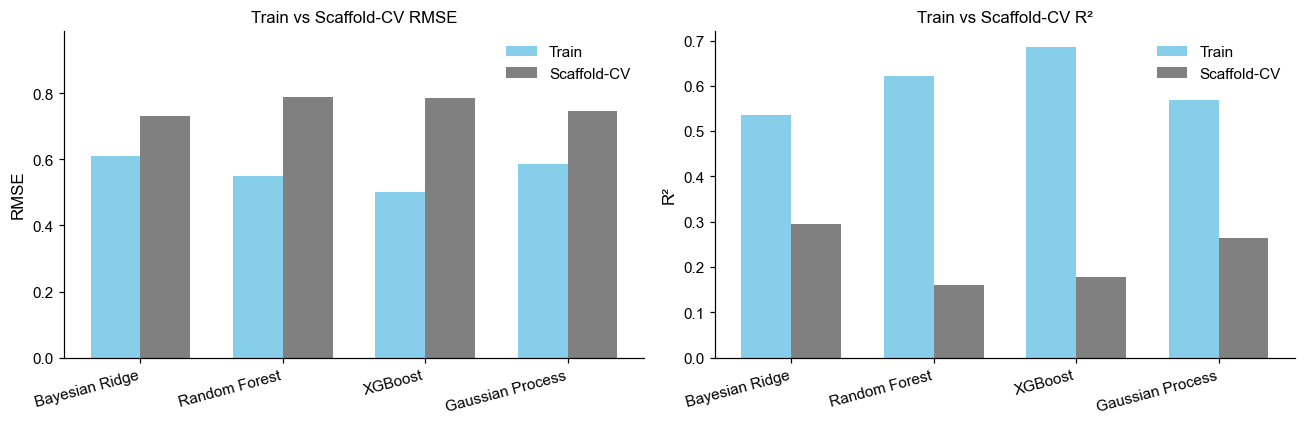

In [36]:
print("Overfitting Check: Training vs Scaffold-CV")

models_check = {
    "Bayesian Ridge": br,
    "Random Forest": rf,
    "XGBoost": xgb,
    "Gaussian Process": gpr
}

overfitting_results = []

for name, model in models_check.items():
    y_train_pred = model.predict(X_labelled_full)
    rmse_train = np.sqrt(mean_squared_error(y_labelled, y_train_pred))
    r2_train = r2_score(y_labelled, y_train_pred)
    r_train, _ = pearsonr(y_labelled, y_train_pred)

    _row = results_df.loc[results_df['Model'] == name].iloc[0]
    rmse_cv = _row['RMSE_Tuned']
    r2_cv = _row['R2_Tuned']
    r_cv = _row['Pearson_Tuned']

    print(f"\n{name}:")
    print(f"Train: RMSE={rmse_train:.3f}, R²={r2_train:.3f}, r={r_train:.3f}")
    print(f"CV: RMSE={rmse_cv:.3f}, R²={r2_cv:.3f}, r={r_cv:.3f}")

    overfitting_results.append({
        "Model": name,
        "RMSE_train": rmse_train,
        "RMSE_CV": rmse_cv,
        "R2_train": r2_train,
        "R2_CV": r2_cv,
        "Pearson_train": r_train,
        "Pearson_CV": r_cv,
    })

overfit_df = pd.DataFrame(overfitting_results)
overfit_df = overfit_df.merge(
    results_df[['Model', 'RMSE_std']], on='Model', how='left')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(overfit_df))
width = 0.35

ax1.bar(x - width/2, overfit_df['RMSE_train'], width, label='Train', color='skyblue')
ax1.bar(x + width/2, overfit_df['RMSE_CV'], width, label='Scaffold-CV', color='grey')
ax1.set_xticks(x)
ax1.set_xticklabels(overfit_df['Model'], rotation=15, ha='right')
ax1.set_ylim(0, overfit_df[['RMSE_train', 'RMSE_CV']].max().max() * 1.25)
ax1.set_ylabel('RMSE')
ax1.set_title('Train vs Scaffold-CV RMSE')
ax1.legend()

ax2.bar(x - width/2, overfit_df['R2_train'], width, label='Train', color='skyblue')
ax2.bar(x + width/2, overfit_df['R2_CV'], width, label='Scaffold-CV', color='grey')
ax2.set_xticks(x)
ax2.set_xticklabels(overfit_df['Model'], rotation=15, ha='right')
ax2.set_ylabel('R²')
ax2.set_title('Train vs Scaffold-CV R²')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "train_vs_cv_rmse.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S14.** Training vs scaffold-CV performance for the four model families. RMSE is shown on the left and R² on the right. The gap between paired bars is the difference between training and scaffold-CV performance.

Random Forest has the widest train-to-CV gap at 0.239 and Bayesian Ridge the narrowest at 0.122. This is consistent with the regularised linear model being less sensitive to which scaffolds fall into each fold. For all four models, the training RMSE is more than one tenth lower than the scaffold-CV RMSE. With scaffold splitting, this difference is expected because the training and test sets are structurally separated. The size of the gap reflects the difficulty of generalising across scaffolds. Scaffold-CV RMSE remains the primary measure of performance.

### 7.5 Nested Cross-Validation (Unbiased Performance Estimate)

In [37]:
outer_folds = scaffold_split(labelled_df, n_splits=5, random_state=SEED + 1)

nested_results = []

for outer_idx, outer_test_idx in enumerate(outer_folds):

    outer_test_set = set(outer_test_idx)
    outer_train_idx = np.array([i for i in range(len(y_labelled)) if i not in outer_test_set])
    outer_test_idx = np.array(outer_test_idx)

    X_out_train = X_labelled_full[outer_train_idx]
    y_out_train = y_labelled[outer_train_idx]
    X_out_test = X_labelled_full[outer_test_idx]
    y_out_test = y_labelled[outer_test_idx]

    outer_train_df = labelled_df.iloc[outer_train_idx].reset_index(drop=True)
    inner_folds = scaffold_split(outer_train_df, n_splits=4, random_state=SEED)

    best_inner_rmse = np.inf
    best_inner_params = None

    for params in ParameterGrid(rf_param_grid):
        rf_inner = build_pipeline(
            "random_forest", random_state=SEED, n_jobs=-1,
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            min_samples_leaf=params['min_samples_leaf']
        )
        inner_metrics, _ = foldwise_cv(
            rf_inner, X_out_train, y_out_train,
            inner_folds, return_oof=False
        )
        if inner_metrics['RMSE_mean'] < best_inner_rmse:
            best_inner_rmse = inner_metrics['RMSE_mean']
            best_inner_params = params

    rf_outer = build_pipeline("random_forest", random_state=SEED, n_jobs=-1, **best_inner_params)
    rf_outer.fit(X_out_train, y_out_train)

    y_pred = rf_outer.predict(X_out_test)
    outer_rmse = np.sqrt(mean_squared_error(y_out_test, y_pred))
    outer_r2 = r2_score(y_out_test, y_pred)
    outer_r, _ = pearsonr(y_out_test, y_pred)

    nested_results.append({
        'Outer Fold': outer_idx + 1,
        'N_test': len(outer_test_idx),
        'Best Params': str(best_inner_params),
        'RMSE': round(outer_rmse, 3),
        'R2': round(outer_r2, 3),
        'Pearson_r': round(outer_r, 3)
    })

    inner_txt = ", ".join(f"{k} = {v}" for k, v in sorted(best_inner_params.items()))
    print(f"Outer fold {outer_idx+1}: "
          f"RMSE={outer_rmse:.3f}, R²={outer_r2:.3f}, r={outer_r:.3f}\n"
          f"  {inner_txt}")

nested_df = pd.DataFrame(nested_results)

nested_rmse_mean = nested_df['RMSE'].mean()
nested_rmse_std = nested_df['RMSE'].std()
nested_r2_mean = nested_df['R2'].mean()
nested_r_mean = nested_df['Pearson_r'].mean()

display(Markdown("**Table S4.** Nested scaffold-CV results (unbiased estimate)."))
show(nested_df.drop(columns=["Best Params"]))

print(f"\nNested CV RMSE: {nested_rmse_mean:.3f} ± {nested_rmse_std:.3f}")
print(f"Nested CV R²: {nested_r2_mean:.3f}")
print(f"Nested CV Pearson r: {nested_r_mean:.3f}")

rf_cv_rmse = results_df.loc[results_df['Model'] == 'Random Forest', 'RMSE_Tuned'].iloc[0]
print(f"\nStandard CV RMSE (Section 7.3): {rf_cv_rmse:.3f}")
print(f"Nested CV RMSE (Section 7.5): {nested_rmse_mean:.3f}")
print(f"Difference in RMSE: {nested_rmse_mean - rf_cv_rmse:+.3f} pIC₅₀ units")

Outer fold 1: RMSE=0.820, R²=-0.139, r=0.520
  max_depth = None, min_samples_leaf = 1, min_samples_split = 5, n_estimators = 300
Outer fold 2: RMSE=0.824, R²=0.148, r=0.568
  max_depth = 20, min_samples_leaf = 1, min_samples_split = 2, n_estimators = 300
Outer fold 3: RMSE=0.501, R²=0.476, r=0.699
  max_depth = 3, min_samples_leaf = 1, min_samples_split = 2, n_estimators = 200
Outer fold 4: RMSE=0.821, R²=0.443, r=0.727
  max_depth = 3, min_samples_leaf = 4, min_samples_split = 2, n_estimators = 300
Outer fold 5: RMSE=0.829, R²=0.068, r=0.347
  max_depth = 10, min_samples_leaf = 2, min_samples_split = 2, n_estimators = 500


**Table S4.** Nested scaffold-CV results (unbiased estimate).

Outer Fold,N_test,RMSE,R2,Pearson_r
1,24,0.820,-0.139,0.520
2,23,0.824,0.148,0.568
3,23,0.501,0.476,0.699
4,23,0.821,0.443,0.727
5,23,0.829,0.068,0.347



Nested CV RMSE: 0.759 ± 0.144
Nested CV R²: 0.199
Nested CV Pearson r: 0.572

Standard CV RMSE (Section 7.3): 0.790
Nested CV RMSE (Section 7.5): 0.759
Difference in RMSE: -0.031 pIC₅₀ units


We ran nested cross-validation on Random Forest to obtain a generalisation estimate that is independent of hyperparameter tuning. In the grid search (Section 7.1), the same scaffold folds are used to select the hyperparameters and calculate the score. Nested cross-validation separates these steps. Five outer scaffold folds give the performance estimate, while an inner loop of four folds within each outer training set selects the hyperparameters. The outer test fold is not used for tuning.

Table S4 gives the nested RMSE and the per-fold results. The nested RMSE is 0.759 ± 0.144, compared with 0.790 from the standard scaffold CV. The nested estimate is therefore 0.031 pIC₅₀ units lower than the standard estimate.

Performance varies between folds with one generalising well, while another performs worse than the series mean and gives a negative R². In that fold, 16 of the 24 compounds belong to scaffold groups containing only one or two compounds.

Nested CV provides a check on the effect of hyperparameter selection, but the nested and standard estimates do not show evidence that tuning inflated the reported Random Forest performance. The four model families were compared using the same scaffold folds in Section 7.3, and Random Forest was then used as the base model for the ensemble.

In [38]:
worst_row = nested_df.loc[nested_df['R2'].idxmin()]
worst_fold_num = int(worst_row['Outer Fold'])
worst_fold_idx = np.array(outer_folds[worst_fold_num - 1])

worst_smiles = labelled_df.iloc[worst_fold_idx]['SMILES'].tolist()
worst_scaffolds = {Chem.MolToSmiles(get_scaffold(s)) for s in worst_smiles}

print(f"Worst outer fold = Fold {worst_fold_num} (R²={worst_row['R2']:.3f}): "
      f"{len(worst_fold_idx)} molecules, {len(worst_scaffolds)} scaffold(s)")
print("Scaffold(s):")
for sc in sorted(worst_scaffolds):
    print(f"  {sc}")

_sizes = Counter(Chem.MolToSmiles(get_scaffold(s)) for s in labelled_df["SMILES"])
_rare = sum(1 for s in worst_smiles
            if _sizes[Chem.MolToSmiles(get_scaffold(s))] <= 2)
print(f"Of the {len(worst_smiles)} compounds, {_rare} sit in scaffold groups of one or two")

Worst outer fold = Fold 1 (R²=-0.139): 24 molecules, 11 scaffold(s)
Scaffold(s):
  O=C(Nc1c[nH]c(C(=O)Nc2cc[nH]c2)c1)c1ccc[nH]1
  O=C(Nc1c[nH]c(C(=O)Nc2cc[nH]c2)c1)c1cscn1
  O=C(Nc1c[nH]cn1)c1cc2c3c(ccc2[nH]1)N(C(=O)c1ccc[nH]1)CC3
  O=C(Nc1cc[nH]c1)c1cc(NC(=O)c2cc3ccccc3o2)c[nH]1
  O=C(Nc1cc[nH]c1)c1cc2cc(NC(=O)c3cc4ccccc4s3)ccc2o1
  O=C(Nc1cc[nH]c1)c1ccc(NC(=O)c2cc3ccccc3o2)cc1
  O=C(Nc1ccc2oc(C(=O)Nc3c[nH]cn3)cc2c1)c1cc2ccccc2o1
  O=C(Nc1ccc2oc(C(=O)Nc3c[nH]cn3)cc2c1)c1ccccc1
  O=C(Nc1ccc2oc(C(=O)Nc3cc[nH]c3)cc2c1)c1cc2ccccc2o1
  O=C(Nc1ccc2sc(C(=O)Nc3cc[nH]c3)cc2c1)c1cc2ccccc2s1
  O=C(Nc1ccc2sc(C(=O)Nc3cc[nH]c3)cc2c1)c1ccc[nH]1
Of the 24 compounds, 16 sit in scaffold groups of one or two


This nested estimate is for Random Forest only, since nested CV was not run for the RF-GP ensemble or Bayesian Ridge. Table S4 therefore gives the generalisation estimate for Random Forest.

### 7.6 Feature-Block Comparison

The 1,030 features exceed the 116 compounds by approximately nine to one, whereas the commonly cited guideline suggests at least five compounds per feature. Rather than assuming regularisation is sufficient, the contribution of the 1024 fingerprint bits is measured directly. Each model family is retuned from scratch on the same scaffold folds and hyperparameter grids as Section 7.1 across four feature blocks. These are LogP alone, the six physicochemical descriptors, the fingerprint alone, and the full matrix. Tables S1 and S2 give scaffold-CV RMSE and R² for each tuned model and feature block. Table S3 gives the full results including fold-level standard deviations.

In [39]:
assert X_labelled_full.shape[1] == len(desc_cols) + 1024, "unexpected feature matrix width"
np.testing.assert_allclose(
    X_labelled_full[:, -6:], desc_array, rtol=0, atol=1e-8,
    err_msg="descriptor block is not the trailing 6 columns of X_labelled_full")

_logp_col = X_labelled_full.shape[1] - 6 + desc_cols.index('LogP')

feature_blocks = {
    "LogP only (1)": X_labelled_full[:, [_logp_col]],
    "Descriptors only (6)": X_labelled_full[:, -6:],
    "Fingerprint only (1024)": X_labelled_full[:, :-6],
}

_block_models = {
    "Bayesian Ridge": (build_br, br_param_grid),
    "Random Forest": (functools.partial(build_rf, SEED), rf_param_grid),
    "Gaussian Process": (functools.partial(build_gp, SEED), gp_param_grid),
    "XGBoost": (functools.partial(build_xgb, SEED), xgb_param_grid),
}

print("Feature-block comparison (tuned, 5-fold scaffold-CV, same folds as Table S11)\n")
block_rows = []
for block_name, X_block in feature_blocks.items():
    for model_name, (builder, grid) in _block_models.items():
        bp, _, _ = run_grid_search(builder, grid, folds, X_block, y_labelled)
        m, _ = foldwise_cv(builder(**bp), X_block, y_labelled, folds,
                           return_oof=False)
        block_rows.append({
            "Features": block_name,
            "Model": model_name,
            "N_feat": X_block.shape[1],
            "RMSE_CV": round(m['RMSE_mean'], 3),
            "RMSE_sd": round(m['RMSE_std'], 3),
            "R2_CV": round(m['R2_mean'], 3),
            "Pearson_r": round(m['Pearson_mean'], 3),
            "Best_params": str(bp),
        })
        print(f"{block_name} | {model_name} | "
              f"RMSE {m['RMSE_mean']:.3f} ± {m['RMSE_std']:.3f} | "
              f"R² {m['R2_mean']:.3f} | r {m['Pearson_mean']:.3f}")

for _, r in results_df.iterrows():
    block_rows.append({
        "Features": "Fingerprint + descriptors (1030)", "Model": r['Model'],
        "N_feat": X_labelled_full.shape[1],
        "RMSE_CV": r['RMSE_Tuned'], "RMSE_sd": r['RMSE_std'],
        "R2_CV": r['R2_Tuned'], "Pearson_r": r['Pearson_Tuned'],
        "Best_params": "see Section 7.1",
    })

block_df = pd.DataFrame(block_rows)
_order = ["LogP only (1)", "Descriptors only (6)", "Fingerprint only (1024)",
          "Fingerprint + descriptors (1030)"]
_order = [b for b in _order if b in set(block_df["Features"])]

assert len(_order) == 4, f"feature-block table is incomplete, only {_order} present"

display(Markdown("**Table S1.** Scaffold-CV RMSE by feature block (tuned)."))
display(block_df.pivot(index="Features", columns="Model", values="RMSE_CV").reindex(_order))
display(Markdown("**Table S2.** Scaffold-CV R² by feature block (tuned)."))
display(block_df.pivot(index="Features", columns="Model", values="R2_CV").reindex(_order))
display(Markdown("**Table S3.** Full feature-block results."))
show(block_df.drop(columns=["Best_params"]))

block_df.to_csv(RESULTS_PRED / "labelled" / "feature_block_comparison.csv", index=False)

Feature-block comparison (tuned, 5-fold scaffold-CV, same folds as Table S11)

LogP only (1) | Bayesian Ridge | RMSE 0.823 ± 0.140 | R² 0.118 | r 0.405
LogP only (1) | Random Forest | RMSE 0.822 ± 0.101 | R² 0.113 | r 0.403
LogP only (1) | Gaussian Process | RMSE 0.819 ± 0.143 | R² 0.125 | r 0.413
LogP only (1) | XGBoost | RMSE 0.823 ± 0.111 | R² 0.116 | r 0.395
Descriptors only (6) | Bayesian Ridge | RMSE 0.770 ± 0.055 | R² 0.203 | r 0.532
Descriptors only (6) | Random Forest | RMSE 0.819 ± 0.079 | R² 0.098 | r 0.410
Descriptors only (6) | Gaussian Process | RMSE 0.781 ± 0.056 | R² 0.183 | r 0.496
Descriptors only (6) | XGBoost | RMSE 0.796 ± 0.087 | R² 0.157 | r 0.447
Fingerprint only (1024) | Bayesian Ridge | RMSE 0.735 ± 0.108 | R² 0.289 | r 0.571
Fingerprint only (1024) | Random Forest | RMSE 0.778 ± 0.090 | R² 0.186 | r 0.494
Fingerprint only (1024) | Gaussian Process | RMSE 0.748 ± 0.117 | R² 0.263 | r 0.546
Fingerprint only (1024) | XGBoost | RMSE 0.748 ± 0.087 | R² 0.254 | r 0

**Table S1.** Scaffold-CV RMSE by feature block (tuned).

Model,Bayesian Ridge,Gaussian Process,Random Forest,XGBoost
Features,,,,
LogP only (1),0.823,0.819,0.822,0.823
Descriptors only (6),0.770,0.781,0.819,0.796
Fingerprint only (1024),0.735,0.748,0.778,0.748
Fingerprint + descriptors (1030),0.732,0.747,0.790,0.785


**Table S2.** Scaffold-CV R² by feature block (tuned).

Model,Bayesian Ridge,Gaussian Process,Random Forest,XGBoost
Features,,,,
LogP only (1),0.118,0.125,0.113,0.116
Descriptors only (6),0.203,0.183,0.098,0.157
Fingerprint only (1024),0.289,0.263,0.186,0.254
Fingerprint + descriptors (1030),0.294,0.264,0.161,0.177


**Table S3.** Full feature-block results.

Features,Model,N_feat,RMSE_CV,RMSE_sd,R2_CV,Pearson_r
LogP only (1),Bayesian Ridge,1,0.823,0.140,0.118,0.405
LogP only (1),Random Forest,1,0.822,0.101,0.113,0.403
LogP only (1),Gaussian Process,1,0.819,0.143,0.125,0.413
LogP only (1),XGBoost,1,0.823,0.111,0.116,0.395
Descriptors only (6),Bayesian Ridge,6,0.770,0.055,0.203,0.532
Descriptors only (6),Random Forest,6,0.819,0.079,0.098,0.410
Descriptors only (6),Gaussian Process,6,0.781,0.056,0.183,0.496
Descriptors only (6),XGBoost,6,0.796,0.087,0.157,0.447
Fingerprint only (1024),Bayesian Ridge,1024,0.735,0.108,0.289,0.571
Fingerprint only (1024),Random Forest,1024,0.778,0.090,0.186,0.494


The fingerprint carries most of the signal. For Bayesian Ridge, LogP alone gives RMSE 0.823 with R² 0.118, the six descriptors together give 0.770 and 0.203, the fingerprint alone gives 0.735 and 0.289, and the full matrix gives 0.732 and 0.294. Adding the descriptors to the fingerprint changes RMSE by 0.003 and R² by 0.005. The fingerprint block performs better than the descriptor block in all four families, so this pattern is not specific to one model. Table S1 gives all four model families in each block. The manuscript quotes the best value in each block, which matches the Bayesian Ridge figures above except for the LogP only block, where the Gaussian Process reaches 0.819.

For the two tree models, the full matrix is worse than the fingerprint alone, 0.790 against 0.778 for Random Forest and 0.785 against 0.748 for XGBoost, while the linear and kernel models are unchanged or slightly better. With six continuous features among 1024 binary ones, impurity-based splitting favours the continuous block, which may explain the lower accuracy. Section 9.5 finds the same pattern, with MDI and SHAP both ranking LogP first and TPSA second.

These differences are small compared with the fold-level standard deviations, which range from 0.055 to 0.143, so they show the direction of the effect rather than clear separation between the feature blocks. The four full matrix rows are carried over from Section 7.3 and were not refitted, so their fold-level standard deviations are the same as those reported in Table S11.

The 1030-dimensional matrix therefore contains less independent information than its width suggests, which is consistent with the low variance feature count in Section 4.1.

### 7.7 Fingerprint Radius and Bit-Space Sensitivity

Two properties of the Morgan encoding are checked here. First, whether radius 2 is the right choice, tested by refitting with the same scaffold folds at radius 1, 2 and 3 while keeping the radius 2 tuned hyperparameters. Second, whether different structures share identical bit vectors, and whether this is caused by the bit space or by the encoding itself. Degeneracy counts are calculated across the combined set of 116 labelled compounds and 24 ChEMBL neighbours, using radii 2 to 4 and bit spaces of 1,024, 2,048 and 4,096.

In [40]:
def featurise_at(smiles_list, radius, nbits=1024):
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nbits)
    rows = []
    for smi in smiles_list:
        m = Chem.MolFromSmiles(str(smi))
        arr = np.zeros((nbits,), dtype=int)
        DataStructs.ConvertToNumpyArray(gen.GetFingerprint(m), arr)
        rows.append(np.concatenate([arr, [
            Descriptors.MolWt(m), Descriptors.MolLogP(m), Descriptors.NumHDonors(m),
            Descriptors.NumHAcceptors(m), Descriptors.NumRotatableBonds(m),
            Descriptors.TPSA(m)]]))
    return np.array(rows, dtype=float)

print("Morgan radius sensitivity (same scaffold folds, hyperparameters tuned at r=2)")
for rad in (1, 2, 3):
    Xr = featurise_at(labelled_df["SMILES"], rad)
    mb, _ = foldwise_cv(br, Xr, y_labelled, folds, return_oof=False)
    mr, _ = foldwise_cv(rf, Xr, y_labelled, folds, return_oof=False)
    print(f"  r={rad}: BR RMSE={mb['RMSE_mean']:.3f} R2={mb['R2_mean']:.3f} | "
          f"RF RMSE={mr['RMSE_mean']:.3f} R2={mr['R2_mean']:.3f}")

print("\nDegeneracy: distinct structures sharing an identical bit vector")
all_smi = list(labelled_df["SMILES"]) + list(
    pd.read_csv(DATA_PROC / "chembl_l1210_neighbours.csv")["smiles"])
for rad in (2, 3, 4):
    for nb in (1024, 2048, 4096):
        gen = rdFingerprintGenerator.GetMorganGenerator(radius=rad, fpSize=nb)
        seen = {}
        for smi in all_smi:
            m = Chem.MolFromSmiles(str(smi))
            if m is None:
                continue
            key = gen.GetFingerprint(m).ToBitString()
            seen.setdefault(key, set()).add(Chem.MolToSmiles(m))
        collided = sum(len(v) for v in seen.values() if len(v) > 1)
        print(f"  r={rad}, {nb} bits: {collided} structures in collided groups")
        if rad == 2 and nb == 1024:
            seen_r2 = seen

_nbr_canon = {Chem.MolToSmiles(Chem.MolFromSmiles(str(s)))
              for s in pd.read_csv(DATA_PROC / "chembl_l1210_neighbours.csv")["smiles"]}

_grp = [v for v in seen_r2.values() if len(v) > 1]
_ext = [v for v in _grp if v & _nbr_canon]
_pure = [v for v in _ext if v <= _nbr_canon]
_span = max(max(Descriptors.MolWt(Chem.MolFromSmiles(s)) for s in v)
            - min(Descriptors.MolWt(Chem.MolFromSmiles(s)) for s in v) for v in _grp)

print(f"\nRadius 2, 1024 bits: {sum(len(v) for v in _grp)} structures in {len(_grp)} groups. "
      f"{sum(len(v & _nbr_canon) for v in _grp)} are ChEMBL neighbours, of which "
      f"{sum(len(v) for v in _pure)} sit in {len(_pure)} groups made only of neighbours. "
      f"Widest mass gap inside a group: {_span:.0f} Da")

Morgan radius sensitivity (same scaffold folds, hyperparameters tuned at r=2)
  r=1: BR RMSE=0.755 R2=0.244 | RF RMSE=0.793 R2=0.155
  r=2: BR RMSE=0.732 R2=0.294 | RF RMSE=0.790 R2=0.161
  r=3: BR RMSE=0.750 R2=0.266 | RF RMSE=0.780 R2=0.177

Degeneracy: distinct structures sharing an identical bit vector
  r=2, 1024 bits: 24 structures in collided groups
  r=2, 2048 bits: 24 structures in collided groups
  r=2, 4096 bits: 24 structures in collided groups
  r=3, 1024 bits: 10 structures in collided groups
  r=3, 2048 bits: 10 structures in collided groups
  r=3, 4096 bits: 10 structures in collided groups
  r=4, 1024 bits: 6 structures in collided groups
  r=4, 2048 bits: 6 structures in collided groups
  r=4, 4096 bits: 6 structures in collided groups

Radius 2, 1024 bits: 24 structures in 11 groups. 13 are ChEMBL neighbours, of which 12 sit in 5 groups made only of neighbours. Widest mass gap inside a group: 244 Da


Radius 2 is the best of the three settings for the Bayesian Ridge baseline, at RMSE 0.732 compared with 0.755 at radius 1 and 0.750 at radius 3. We keep radius 2, since the linear baseline is the best single model.

The degeneracy counts do not change with bit space. Radius 2 gives 24 structures at 1,024, 2,048 and 4,096 bits. Radius 3 gives 10 and radius 4 gives 6. This rules out hash capacity as the cause, since adding bits cannot separate structures that produce identical sets of circular environments. Binary Morgan fingerprints record which environments occur and not how many, so homologues differing only in the repeat count of an existing environment can encode identically.

The degeneracy is a property of the radius-2 representation and affects 24 of the 140 structures in the combined set. Thirteen of the ChEMBL neighbours sit in degenerate groups, twelve of them in five groups made up only of retrieved compounds. The widest pair is 244 Da apart, where a 4-pyrrole and a 6-pyrrole analogue encode identically. We keep the representation, since raising the radius reduces accuracy. The cost is that some homologues are indistinguishable to the model, which contributed to the compressed prediction range in Section 9.8.

## 8. Ensemble Construction and Why It Was Not Taken Forward

The four tuned models have similar scaffold-CV RMSE values (Table S11), with differences smaller than the fold-to-fold variation. Bayesian Ridge has the lowest RMSE and Random Forest the highest, but the difference is small.

The RF-GP ensemble exists to attach a point predictor to the Gaussian Process uncertainty estimate. That estimate does not distinguish between individual molecules (Section 11) and the weighting is not identifiable (Section 8.2), so the ensemble is reported here as a comparison. Weights come from a leakage-free out-of-fold search over the full range, with each fold's weight chosen on the other four, which is as far as this dataset size supports (4). Swapping Random Forest for XGBoost under the same per-fold weighting gives a difference of 0.004 RMSE. Neither ensemble improves on the other, or on Bayesian Ridge alone.

### 8.1 Ensemble Weight Computation

In [41]:
_, rf_oof = foldwise_cv(rf,  X_labelled_full, y_labelled, folds, return_oof=True)
_, gpr_oof = foldwise_cv(gpr, X_labelled_full, y_labelled, folds, return_oof=True)
rf_oof = np.array(rf_oof)
gpr_oof = np.array(gpr_oof)

min_gp_fraction = 0.0
all_idx = np.arange(len(y_labelled))

ensemble_oof_final = np.empty(len(y_labelled), dtype=float)
fold_weight_rows = []
for k, test_idx in enumerate(folds):
    test_idx = np.asarray(test_idx)
    train_idx = np.setdiff1d(all_idx, test_idx)
    (wk_rf, wk_gp), _ = search_ensemble_weights(
        rf_oof[train_idx], gpr_oof[train_idx], y_labelled[train_idx],
        min_gp_fraction=min_gp_fraction)
    ensemble_oof_final[test_idx] = wk_rf * rf_oof[test_idx] + wk_gp * gpr_oof[test_idx]
    fold_weight_rows.append({'Fold': k+1, 'w_RF': round(float(wk_rf),2), 'w_GP': round(float(wk_gp),2)})

display(Markdown("**Table S12.** Per-fold ensemble weights, each chosen on the other four folds."))
show(pd.DataFrame(fold_weight_rows))

best_weights, weight_search_df = search_ensemble_weights(
    rf_oof, gpr_oof, y_labelled, min_gp_fraction=min_gp_fraction)
w_rf, w_gp = best_weights
weights_simple = (w_rf, w_gp)
weighted_gp_contribution = w_gp / (w_rf + w_gp)

display(Markdown("**Table S7.** Ensemble weight search results (OOF scoring)."))
show(weight_search_df)

rmse = np.sqrt(mean_squared_error(y_labelled, ensemble_oof_final))
r2 = r2_score(y_labelled, ensemble_oof_final)
r, p = pearsonr(y_labelled, ensemble_oof_final)

fold_rmse, fold_r2, fold_r = [], [], []
for test_idx in folds:
    test_idx = np.array(test_idx)
    yt, yp = y_labelled[test_idx], ensemble_oof_final[test_idx]
    fold_rmse.append(np.sqrt(mean_squared_error(yt, yp)))
    fold_r2.append(r2_score(yt, yp))
    fold_r.append(pearsonr(yt, yp)[0])

N_BOOT = 2000
scaffold_labels = np.array([Chem.MolToSmiles(get_scaffold(s)) for s in labelled_df['SMILES']])
unique_scaffolds = np.unique(scaffold_labels)
groups = {sc: np.where(scaffold_labels == sc)[0] for sc in unique_scaffolds}

rng_boot = np.random.default_rng(SEED)
boot_rmse, boot_r = [], []
for _ in range(N_BOOT):
    chosen = rng_boot.choice(unique_scaffolds, size=len(unique_scaffolds), replace=True)
    idx = np.concatenate([groups[sc] for sc in chosen])
    y_b, yhat_b = y_labelled[idx], ensemble_oof_final[idx]
    boot_rmse.append(np.sqrt(mean_squared_error(y_b, yhat_b)))
    if np.std(y_b) > 0 and np.std(yhat_b) > 0:
        boot_r.append(pearsonr(y_b, yhat_b)[0])

ci_rmse = np.percentile(boot_rmse, [2.5, 97.5])
ci_r = np.percentile(boot_r, [2.5, 97.5])

print(f"Automated search chose: w_RF={best_weights[0]:.2f}, w_GP={best_weights[1]:.2f}")
print(f"Ensemble weights: w_RF={w_rf:.2f}, w_GP={w_gp:.2f}")
print(f"Ensemble OOF (pooled): RMSE={rmse:.3f} (95% CI {ci_rmse[0]:.3f}-{ci_rmse[1]:.3f}), "
      f"R²={r2:.3f}, r={r:.3f} (95% CI {ci_r[0]:.3f}-{ci_r[1]:.3f})")
print(f"Ensemble OOF (fold-avg): RMSE={np.mean(fold_rmse):.3f}±{np.std(fold_rmse, ddof=1):.3f}, "
      f"R²={np.mean(fold_r2):.3f}, r={np.mean(fold_r):.3f}")

**Table S12.** Per-fold ensemble weights, each chosen on the other four folds.

Fold,w_RF,w_GP
1,0.05,0.95
2,0.05,0.95
3,0.20,0.80
4,0.25,0.75
5,0.00,1.00


**Table S7.** Ensemble weight search results (OOF scoring).

w_RF,w_GP,GP_frac,OOF_RMSE,OOF_R2,Selected
0.00,1.00,1.00,0.754606,0.2892,
0.05,0.95,0.95,0.754343,0.2897,
0.10,0.90,0.90,0.754312,0.2897,Yes
0.15,0.85,0.85,0.754515,0.2893,
0.20,0.80,0.80,0.754951,0.2885,
0.25,0.75,0.75,0.755619,0.2872,
0.30,0.70,0.70,0.756519,0.2855,
0.35,0.65,0.65,0.757651,0.2834,
0.40,0.60,0.60,0.759012,0.2808,
0.45,0.55,0.55,0.760603,0.2778,


Automated search chose: w_RF=0.10, w_GP=0.90
Ensemble weights: w_RF=0.10, w_GP=0.90
Ensemble OOF (pooled): RMSE=0.759 (95% CI 0.655-0.863), R²=0.281, r=0.531 (95% CI 0.390-0.654)
Ensemble OOF (fold-avg): RMSE=0.753±0.104, R²=0.253, r=0.537


The out-of-fold RMSE search selects the weights in Table S7. Table S7 uses a single weight applied across all five folds, whereas the pooled value of 0.759 reported above uses the weights from each individual fold in Table S12. This accounts for the slight difference from the grid minimum of 0.754. Across the full weight range, the RMSE surface varies by less than the bootstrap uncertainty. This means the optimum and the next configuration along cannot be separated, and the exact split makes almost no difference. Section 11 finds that the GP intervals do not distinguish between individual molecules, so the GP weight adds no usable per-molecule signal.

The confidence intervals come from a scaffold-block bootstrap. Whole scaffold groups are resampled with replacement instead of individual molecules, since out-of-fold predictions within a scaffold are not independent. With 61 groups, the intervals are still approximate and give the order of magnitude of the sampling uncertainty instead of exact coverage bounds.

We use Bayesian Ridge instead, since its scaffold-CV RMSE is lower, 0.732 against 0.753 fold-averaged and 0.738 against 0.759 pooled, and its prediction range on the external set is larger, 0.60 log units against 0.38. The external rank correlation is higher at ρ = 0.560 against 0.505, but the bootstrap intervals overlap almost entirely and both include zero, so that difference is not supported. The two models correlate at ρ = 0.986, so the change affects nothing in Section 9.

In [42]:
print("XGBoost-GP ensemble comparison")
_, xgb_oof = foldwise_cv(xgb, X_labelled_full, y_labelled, folds,
                          return_oof=True)
xgb_oof = np.array(xgb_oof)

xgb_ens_oof = np.empty(len(y_labelled), dtype=float)
for test_idx in folds:
    test_idx = np.asarray(test_idx)
    train_idx = np.setdiff1d(all_idx, test_idx)
    (wx, wg), _ = search_ensemble_weights(
        xgb_oof[train_idx], gpr_oof[train_idx], y_labelled[train_idx],
        min_gp_fraction=min_gp_fraction)
    xgb_ens_oof[test_idx] = wx * xgb_oof[test_idx] + wg * gpr_oof[test_idx]
xgb_ens_rmse = np.sqrt(mean_squared_error(y_labelled, xgb_ens_oof))
xgb_ens_r2 = r2_score(y_labelled, xgb_ens_oof)
xgb_ens_r, _ = pearsonr(y_labelled, xgb_ens_oof)

print(f"XGB-GP pooled OOF: RMSE={xgb_ens_rmse:.3f}, R²={xgb_ens_r2:.3f}, r={xgb_ens_r:.3f}")
print(f"RF-GP  pooled OOF: RMSE={rmse:.3f}, R²={r2:.3f}, r={r:.3f}")
print(f"Δ (XGB-GP − RF-GP): RMSE={xgb_ens_rmse - rmse:+.3f}")

XGBoost-GP ensemble comparison
XGB-GP pooled OOF: RMSE=0.763, R²=0.273, r=0.522
RF-GP  pooled OOF: RMSE=0.759, R²=0.281, r=0.531
Δ (XGB-GP − RF-GP): RMSE=+0.004


In [43]:
print("Seed sensitivity: pooled OOF RMSE across fold-construction seeds")
seed_rmses, seed_r2s = [], []
for s in [42, 1, 7, 123, 2024]:
    folds_s = scaffold_split(labelled_df, n_splits=5, random_state=s)
    _, rf_oof_s = foldwise_cv(rf,  X_labelled_full, y_labelled, folds_s, return_oof=True)
    _, gpr_oof_s = foldwise_cv(gpr, X_labelled_full, y_labelled, folds_s, return_oof=True)
    rf_oof_s, gpr_oof_s = np.array(rf_oof_s), np.array(gpr_oof_s)
    bw_s, _ = search_ensemble_weights(rf_oof_s, gpr_oof_s, y_labelled, min_gp_fraction=min_gp_fraction)
    ens_s = bw_s[0] * rf_oof_s + bw_s[1] * gpr_oof_s
    rmse_s = np.sqrt(mean_squared_error(y_labelled, ens_s))
    r2_s = r2_score(y_labelled, ens_s)
    seed_rmses.append(rmse_s)
    seed_r2s.append(r2_s)
    print(f"seed = {s}: w_RF = {bw_s[0]:.2f}, w_GP = {bw_s[1]:.2f} | pooled OOF RMSE = {rmse_s:.3f}, R² = {r2_s:.3f}")

print(f"\nAcross {len(seed_rmses)} seeds: RMSE = {np.mean(seed_rmses):.3f} ± {np.std(seed_rmses, ddof=1):.3f} "
      f"| R² = {np.mean(seed_r2s):.3f} ± {np.std(seed_r2s, ddof=1):.3f}")

Seed sensitivity: pooled OOF RMSE across fold-construction seeds
seed = 42: w_RF = 0.10, w_GP = 0.90 | pooled OOF RMSE = 0.754, R² = 0.290
seed = 1: w_RF = 0.25, w_GP = 0.75 | pooled OOF RMSE = 0.740, R² = 0.316
seed = 7: w_RF = 0.30, w_GP = 0.70 | pooled OOF RMSE = 0.761, R² = 0.277
seed = 123: w_RF = 0.40, w_GP = 0.60 | pooled OOF RMSE = 0.747, R² = 0.303
seed = 2024: w_RF = 0.55, w_GP = 0.45 | pooled OOF RMSE = 0.771, R² = 0.258

Across 5 seeds: RMSE = 0.755 ± 0.012 | R² = 0.289 ± 0.023


The pooled OOF RMSE stays similar across five different fold-construction seeds, at 0.755 ± 0.012 with R² 0.289 ± 0.023, so the overall performance does not depend on one scaffold split. The selected weight changes between seeds, while the overall accuracy remains similar. The weighting is therefore not identifiable. The OOF minimum moves from w_RF = 0.10 to w_RF = 0.55 across those same five seeds. The y-randomisation null uses 100 label permutations under the same folds and seed, giving OOF R² −0.059 ± 0.047 against 0.290, a Z of 7.4.

In [44]:
warnings.filterwarnings("ignore", category=ConstantInputWarning)

rng = np.random.default_rng(SEED)
real_r2 = r2_score(y_labelled, w_rf*rf_oof + w_gp*gpr_oof)
scrambled = []
for _ in range(100):
    yp = rng.permutation(y_labelled)
    _, rf_p = foldwise_cv(rf,  X_labelled_full, yp, folds, return_oof=True)
    _, gpr_p = foldwise_cv(gpr, X_labelled_full, yp, folds, return_oof=True)
    scrambled.append(r2_score(yp, w_rf*np.array(rf_p) + w_gp*np.array(gpr_p)))
z = (real_r2 - np.mean(scrambled)) / np.std(scrambled)
print(f"Y-randomised OOF R²: {np.mean(scrambled):.3f} ± {np.std(scrambled):.3f}  (real: {real_r2:.3f})")
print(f"Y-randomisation Z = {z:.1f}")

Y-randomised OOF R²: -0.059 ± 0.047  (real: 0.290)
Y-randomisation Z = 7.4


### 8.2 Ensemble Weight Sensitivity Analysis

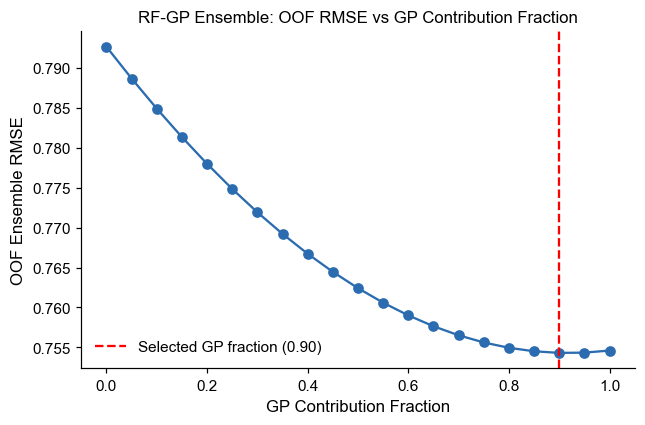

In [45]:
plt.figure(figsize=(6, 4))
plt.plot(weight_search_df['GP_frac'], weight_search_df['OOF_RMSE'], marker='o')
plt.axvline(weighted_gp_contribution, color='r', linestyle='--',
    label=f'Selected GP fraction ({weighted_gp_contribution:.2f})')
plt.xlabel('GP Contribution Fraction')
plt.ylabel('OOF Ensemble RMSE')
plt.title('RF-GP Ensemble: OOF RMSE vs GP Contribution Fraction')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "ensemble_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S3.** RF-GP ensemble out-of-fold RMSE against GP contribution fraction across the full range, w_GP ∈ [0, 1]. RMSE reaches its minimum at w_GP = 0.90 and rises again at pure GP.

Out-of-fold RMSE varies by only 0.038 across the full range of w_RF (Table S7). That is about a fifth of the width of the bootstrap interval on the RMSE itself (0.655 to 0.863) so the weighting has no sharp optimum. The 0.10 and 0.90 point is the grid minimum, and it sits 0.000294 RMSE units from pure GP at w_RF 0.00.

### 8.3 Save Outputs

In [46]:
IC50_actual, IC50_pred, IC50_uncert = ensemble_predictions(rf, gpr, w_rf, w_gp, X_labelled_full, y_labelled)

ensemble_df = pd.DataFrame({
    'SMILES': labelled_df['SMILES'],
    'IC50_actual_µM': IC50_actual,
    'IC50_predicted_µM': IC50_pred,
    'IC50_uncertainty_µM': IC50_uncert
})

path_labelled_ensemble = RESULTS_PRED / "labelled" / "RF_GP_ensemble_labelled_insample.csv"
ensemble_df.to_csv(path_labelled_ensemble, index=False)

joblib.dump(rf, MODELS_DIR / "rf_pipeline.pkl")
joblib.dump(gpr, MODELS_DIR / "gp_pipeline.pkl")
joblib.dump(xgb, MODELS_DIR / "xgb_pipeline.pkl")
joblib.dump(br, MODELS_DIR / "bayesian_ridge_pipeline.pkl")
joblib.dump(
    {'rf': rf, 'gp': gpr, 'weights': (w_rf, w_gp)},
    MODELS_DIR / "RF_GP_ensemble.pkl"
)
print("Models saved")

Models saved


In [47]:
if "censored" in labelled_df.columns:
    censored_flag = labelled_df["censored"].fillna(False).astype(bool).values
    print("censored flag taken from labelled_df")
else: 

    _d = pd.read_csv(DATA_PROC / "processed_data.csv")
    _d = _d[_d["IC50"].notna()].copy()
    if "censored" not in _d:
        _d["censored"] = False
    _d["_canon"] = _d["SMILES"].map(canonical_smiles)
    _cmap = _d.set_index("_canon")["censored"].fillna(False).astype(bool).to_dict()
    censored_flag = labelled_df["SMILES"].map(canonical_smiles).map(_cmap).fillna(False).astype(bool).values
    print("censored flag rebuilt by canonical SMILES from processed_data.csv")

assert len(censored_flag) == len(y_labelled), "mask length mismatch"
print(f"censored: {censored_flag.sum()} of {len(censored_flag)}")

rho, p = spearmanr(ensemble_oof_final, y_labelled)
print(f"\nlabelled OOF rank correlation, all {len(y_labelled)} : rho = {rho:.3f} (p = {p:.2g})")

mask = ~censored_flag
rho_u, p_u = spearmanr(ensemble_oof_final[mask], y_labelled[mask])
print(f"labelled OOF rank correlation, uncensored: rho = {rho_u:.3f} (p = {p_u:.2g}, n = {mask.sum()})")

_, br_oof = foldwise_cv(br, X_labelled_full, y_labelled, folds, return_oof=True)
br_oof = np.array(br_oof)
rho_br, p_br = spearmanr(br_oof, y_labelled)
print(f"\nBayesian Ridge OOF rank correlation, all {len(y_labelled)}: rho = {rho_br:.3f} (p = {p_br:.2g})")

rho_agree, _ = spearmanr(br_oof, ensemble_oof_final)
print(f"Bayesian Ridge vs ensemble, OOF rank agreement: rho = {rho_agree:.3f}")

censored flag taken from labelled_df
censored: 15 of 116

labelled OOF rank correlation, all 116 : rho = 0.502 (p = 9.6e-09)
labelled OOF rank correlation, uncensored: rho = 0.514 (p = 3.8e-08, n = 101)

Bayesian Ridge OOF rank correlation, all 116: rho = 0.541 (p = 3.6e-10)
Bayesian Ridge vs ensemble, OOF rank agreement: rho = 0.986


## 9. Model Evaluation

### 9.1 Scaffold-Based Cross-Validation of Individual Models

In [48]:
display(Markdown("**Table S13.** Final scaffold-CV results (from Section 7.3)."))
show(overfit_df[['Model', 'RMSE_CV', 'RMSE_std', 'R2_CV', 'Pearson_CV']].round(3))

**Table S13.** Final scaffold-CV results (from Section 7.3).

Model,RMSE_CV,RMSE_std,R2_CV,Pearson_CV
Bayesian Ridge,0.732,0.102,0.294,0.575
Random Forest,0.790,0.066,0.161,0.459
XGBoost,0.785,0.044,0.177,0.490
Gaussian Process,0.747,0.112,0.264,0.547


Table S13 restates the Section 7.3 scaffold-CV results. Bayesian Ridge has the lowest mean RMSE. Fold-to-fold variance does not correspond to mean RMSE.

### 9.2 Individual Model Performance Evaluation (Labelled Data)

In [49]:
print("Individual model performance (in-sample)")

insample_rows = []
models_eval = {
    "Bayesian Ridge": br,
    "Gaussian Process": gpr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models_eval.items():
    if name == "Gaussian Process":
        y_pred, y_std = gp_predict_with_std(model, X_labelled_full)
        avg_uncertainty = np.mean(y_std)
    else:
        y_pred = model.predict(X_labelled_full)
        avg_uncertainty = None

    _rmse = np.sqrt(mean_squared_error(y_labelled, y_pred))
    _r2 = r2_score(y_labelled, y_pred)
    _r, _ = pearsonr(y_labelled, y_pred)

    insample_rows.append({
        'Model': name,
        'RMSE_train': round(_rmse, 3),
        'R2_train': round(_r2, 3),
        'Pearson_train': round(_r, 3)
    })

    print(f"\n{name}: RMSE={_rmse:.3f}, R²={_r2:.3f}, r={_r:.3f}")
    if avg_uncertainty is not None:
        print(f"Average GP uncertainty: {avg_uncertainty:.3f}")

insample_df = pd.DataFrame(insample_rows)
display(Markdown("**Table S14.** In-sample model performance."))
show(insample_df)

Individual model performance (in-sample)

Bayesian Ridge: RMSE=0.610, R²=0.535, r=0.749

Gaussian Process: RMSE=0.587, R²=0.569, r=0.782
Average GP uncertainty: 0.731

Random Forest: RMSE=0.551, R²=0.621, r=0.826

XGBoost: RMSE=0.502, R²=0.686, r=0.881


**Table S14.** In-sample model performance.

Model,RMSE_train,R2_train,Pearson_train
Bayesian Ridge,0.610,0.535,0.749
Gaussian Process,0.587,0.569,0.782
Random Forest,0.551,0.621,0.826
XGBoost,0.502,0.686,0.881


Table S14 gives in-sample RMSE, R² and Pearson r for each model. Random Forest and XGBoost fit the training data best at 0.551 and 0.502, with the Gaussian Process at 0.587 and Bayesian Ridge at 0.610. The tuned tree models have their maximum depth limited to 3 in both cases, and the in-sample R² is only moderate throughout. When test compounds are close analogues of training compounds, non-structural validation gives optimistic scores, and structural scaffold splitting is what exposes the real generalisation gap (5, 6). We therefore expect a large gap between in-sample and scaffold-CV R² here.

### 9.3 Ensemble Model Performance Evaluation (Labelled Data)

These metrics come from a model fitted on all 116 compounds, so they are optimistic by construction and serve only as an implementation check. Section 8.1 contains the evaluation used for model comparison. The same applies to the labelled-prediction file, and no reported metric uses it.

In [50]:
if 'weights_simple' not in globals():
    raise RuntimeError("Ensemble weights not found: run Section 8.1 before this cell.")

rf_pred_labelled = rf.predict(X_labelled_full)
gpr_pred_labelled = gpr.predict(X_labelled_full)
gpr_pred_labelled = gpr_pred_labelled.ravel()
ensemble_pred_labelled = weights_simple[0] * rf_pred_labelled + weights_simple[1] * gpr_pred_labelled

_rmse = np.sqrt(mean_squared_error(y_labelled, ensemble_pred_labelled))
_r2 = r2_score(y_labelled, ensemble_pred_labelled)
_r, _ = pearsonr(y_labelled, ensemble_pred_labelled)

print(f"Ensemble (in-sample): RMSE={_rmse:.3f}, R²={_r2:.3f}, r={_r:.3f}")

Ensemble (in-sample): RMSE=0.579, R²=0.581, r=0.794


### 9.4 Random Forest Feature Importances

Feature indices run 0 to 1029 (1030 columns). The last six (1024 to 1029) are the physicochemical descriptors (in order MolWt, LogP, HDonors, HAcceptors, RotBonds, TPSA). Indices 0 to 1023 are the raw 1024-bit Morgan fingerprint bits, with each bit linked to its corresponding environment through the bit-info map (Section 9.5). No bits were dropped, so no inverse-selection step is required.

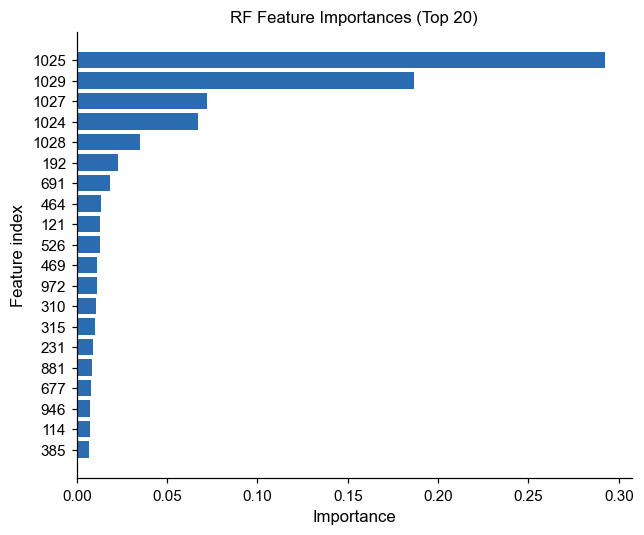

In [51]:
descriptor_names = ['MolWt', 'LogP', 'HDonors', 'HAcceptors', 'RotBonds', 'TPSA']
fp_bits = X_labelled_full.shape[1] - 6

importances = rf.named_steps['model'].feature_importances_
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(6,5))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), top_idx)
plt.ylabel('Feature index')
plt.xlabel('Importance')
plt.title('RF Feature Importances (Top 20)')
plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "rf_feature_importances.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S15.** Twenty highest Random Forest impurity-based feature importances for the tuned model across 1,030 features (1,024 Morgan bits + 6 descriptors).

In [52]:
top_feature_indices = top_idx.tolist()

print("Top 20 feature breakdown:")
for rank, idx in enumerate(reversed(top_feature_indices)):
    if idx >= fp_bits:
        label = f"Descriptor: {descriptor_names[idx - fp_bits]}"
    else:
        label = f"Fingerprint bit {idx}"
    print(f"Rank {rank+1} | Feature {idx} | Importance {importances[idx]:.4f} | {label}")

Top 20 feature breakdown:
Rank 1 | Feature 1025 | Importance 0.2925 | Descriptor: LogP
Rank 2 | Feature 1029 | Importance 0.1866 | Descriptor: TPSA
Rank 3 | Feature 1027 | Importance 0.0722 | Descriptor: HAcceptors
Rank 4 | Feature 1024 | Importance 0.0668 | Descriptor: MolWt
Rank 5 | Feature 1028 | Importance 0.0348 | Descriptor: RotBonds
Rank 6 | Feature 192 | Importance 0.0230 | Fingerprint bit 192
Rank 7 | Feature 691 | Importance 0.0186 | Fingerprint bit 691
Rank 8 | Feature 464 | Importance 0.0135 | Fingerprint bit 464
Rank 9 | Feature 121 | Importance 0.0128 | Fingerprint bit 121
Rank 10 | Feature 526 | Importance 0.0126 | Fingerprint bit 526
Rank 11 | Feature 469 | Importance 0.0114 | Fingerprint bit 469
Rank 12 | Feature 972 | Importance 0.0111 | Fingerprint bit 972
Rank 13 | Feature 310 | Importance 0.0107 | Fingerprint bit 310
Rank 14 | Feature 315 | Importance 0.0101 | Fingerprint bit 315
Rank 15 | Feature 231 | Importance 0.0089 | Fingerprint bit 231
Rank 16 | Feature 881 

### 9.5 SHAP Feature Importance Analysis

We compute SHAP (SHapley Additive exPlanations) values for the Random Forest to obtain feature attributions. SHAP avoids the two problems with MDI in Section 9.4. It does not favour features with many possible split points, and it accounts for feature dependence (7). We use a `TreeExplainer`, which computes exact Shapley values for tree ensembles without sampling. The tree algorithm and the limitations of MDI for high cardinality features are described in Lundberg et al. (8).

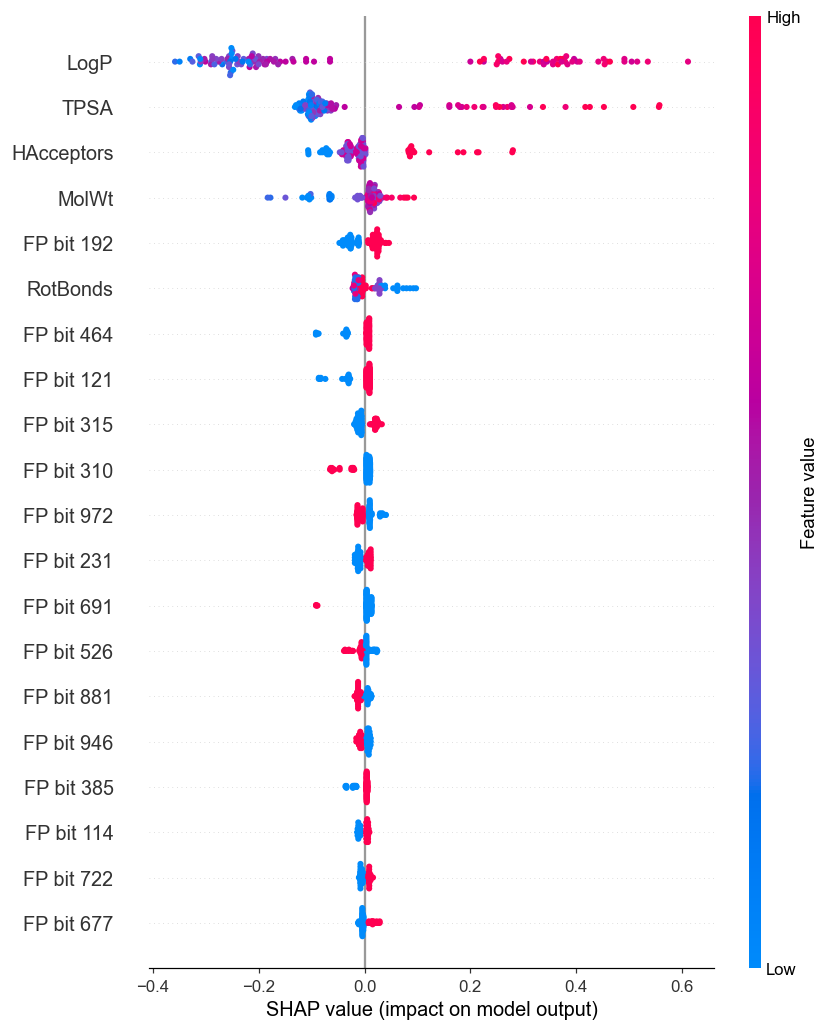

In [53]:
feature_names = [f"FP bit {i}" for i in range(fp_bits)] + descriptor_names

warnings.filterwarnings("ignore", category=FutureWarning)

X_for_shap = rf.named_steps['scaler'].transform(X_labelled_full)
explainer = shap.TreeExplainer(rf.named_steps['model'])
shap_values = explainer.shap_values(X_for_shap)

plt.figure()
shap.summary_plot(
    shap_values,
    X_for_shap,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "shap_summary.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S4.** SHAP beeswarm for the tuned Random Forest over all 116 labelled compounds. Each point represents one molecule, positioned horizontally by its SHAP value in pIC₅₀ units and coloured by feature value. Rows are ordered by mean absolute SHAP value.

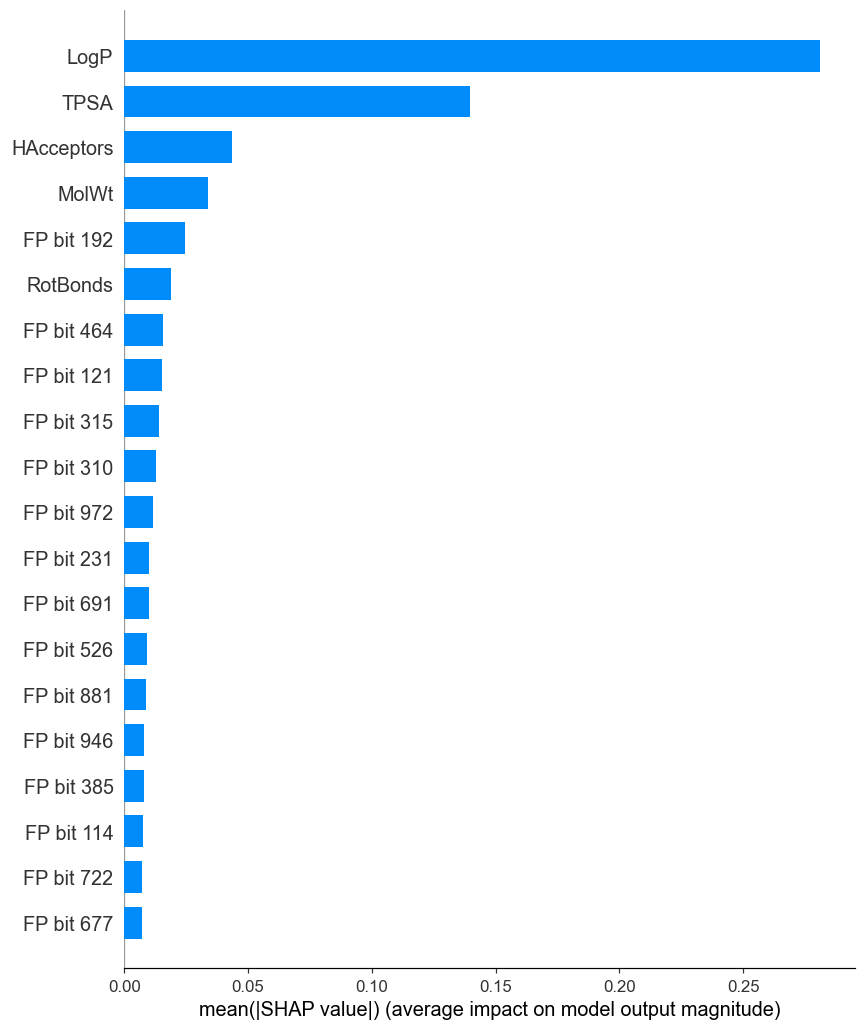

In [54]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_for_shap,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "shap_bar.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S5.** Mean absolute SHAP value per feature for the tuned Random Forest (n = 116), showing the twenty highest-ranked features.

In [55]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_shap_idx = np.argsort(mean_abs_shap)[-20:][::-1]

print("Top 20 features by mean |SHAP|:")
for rank, idx in enumerate(top_shap_idx, start=1):
    label = feature_names[idx]
    print(f"Rank {rank} | Feature {idx} | Mean absolute SHAP {mean_abs_shap[idx]:.4f} | {label}")

Top 20 features by mean |SHAP|:
Rank 1 | Feature 1025 | Mean absolute SHAP 0.2810 | LogP
Rank 2 | Feature 1029 | Mean absolute SHAP 0.1395 | TPSA
Rank 3 | Feature 1027 | Mean absolute SHAP 0.0436 | HAcceptors
Rank 4 | Feature 1024 | Mean absolute SHAP 0.0338 | MolWt
Rank 5 | Feature 192 | Mean absolute SHAP 0.0244 | FP bit 192
Rank 6 | Feature 1028 | Mean absolute SHAP 0.0190 | RotBonds
Rank 7 | Feature 464 | Mean absolute SHAP 0.0157 | FP bit 464
Rank 8 | Feature 121 | Mean absolute SHAP 0.0152 | FP bit 121
Rank 9 | Feature 315 | Mean absolute SHAP 0.0142 | FP bit 315
Rank 10 | Feature 310 | Mean absolute SHAP 0.0129 | FP bit 310
Rank 11 | Feature 972 | Mean absolute SHAP 0.0118 | FP bit 972
Rank 12 | Feature 231 | Mean absolute SHAP 0.0101 | FP bit 231
Rank 13 | Feature 691 | Mean absolute SHAP 0.0099 | FP bit 691
Rank 14 | Feature 526 | Mean absolute SHAP 0.0091 | FP bit 526
Rank 15 | Feature 881 | Mean absolute SHAP 0.0089 | FP bit 881
Rank 16 | Feature 946 | Mean absolute SHAP 0.0

This sits alongside the MDI ranking in Section 9.4. Where the two disagree, MDI has usually been affected by feature cardinality or correlation, so we use SHAP as the primary summary of feature contributions for this Random Forest.

The top four features by mean absolute SHAP all go to physicochemical descriptors, with LogP at 0.281, TPSA at 0.140, then hydrogen bond acceptors and molecular weight. Bit 192 comes fifth at 0.024, just behind molecular weight at 0.034, so only LogP and TPSA have substantially larger SHAP values than the fingerprint bits. In a congeneric series built on one pharmacophore, the physicochemical descriptors show greater variation between compounds than individual fingerprint bits, which may explain their higher SHAP values.

The two measures agree on LogP and TPSA but differ for rotatable bonds, which ranks fifth by MDI and sixth by SHAP. These feature rankings do not establish or demonstrate that substructure is irrelevant.

Molecules containing bit 192: 68 / 116
Total occurrences: 94
Distinct atom environments: 1
  94  c(c(c)N)c(c)c
Ring sizes:
  (6,): 94


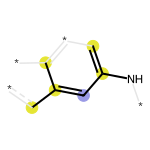

In [56]:
_fp_top = [int(i) for i in top_shap_idx if i < fp_bits]
assert _fp_top, "no fingerprint bit in the SHAP top-20"
TARGET_BIT = _fp_top[0]
RADIUS, NBITS = 2, 1024

gen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=NBITS)
bit_hits = []
for smi in labelled_df["SMILES"]:
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        continue
    ao = rdFingerprintGenerator.AdditionalOutput(); ao.AllocateBitInfoMap()
    gen.GetFingerprint(mol, additionalOutput=ao)
    bi = ao.GetBitInfoMap()
    if TARGET_BIT in bi:
        bit_hits.append((smi, mol, bi))

print(f"Molecules containing bit {TARGET_BIT}: {len(bit_hits)} / {len(labelled_df)}")

envs = Counter()
ring_sizes = Counter()
for smi, mol, bi in bit_hits:
    ri = mol.GetRingInfo()
    for atom_idx, radius in bi[TARGET_BIT]:
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        amap = {}
        submol = Chem.PathToSubmol(mol, env, atomMap=amap)
        envs[Chem.MolToSmiles(submol, rootedAtAtom=amap[atom_idx], canonical=True)] += 1
        ring_sizes[tuple(sorted(len(r) for r in ri.AtomRings() if atom_idx in r))] += 1

print(f"Total occurrences: {sum(envs.values())}")
print(f"Distinct atom environments: {len(envs)}")
for env_smi, n in envs.most_common():
    print(f"  {n}  {env_smi}")

print("Ring sizes:")
for sizes, n in ring_sizes.most_common():
    print(f"  {sizes}: {n}")

opts = rdMolDraw2D.MolDrawOptions()
opts.updateAtomPalette({7: (0, 0, 0)})
smi, mol, bi = bit_hits[0]
AllChem.Compute2DCoords(mol)
img = Draw.DrawMorganBit(mol, TARGET_BIT, bi, drawOptions=opts, useSVG=True)
svg_text = img.data if hasattr(img, "data") else img
with open(RESULTS_FIG / "model_evaluation" / f"bit{TARGET_BIT}_environment.svg", "w") as f:
    f.write(svg_text)
display(img);

**Figure S6.** Atom environment encoded by Morgan bit 192, the highest ranked fingerprint feature in the SHAP ranking. This bit occurs in 68 of the 116 labelled compounds and represents a single atom environment, c(c(c)N)c(c)c, centred on a six membered ring.

Bit 192 is the highest-ranked fingerprint feature. It is set in 68 of the 116 labelled compounds and occurs 94 times in total. A feature present in most of the library has limited variation across compounds, which may explain why the bulk descriptors rank higher.

### 9.6 Interpretable Free-Wilson Model

We fit two parameterisations of the N-terminal position. The combined coding treats each of the 20 A subunits as its own level, giving 30 terms. The split coding separates the A label into a scaffold stem and a cap, giving 22 terms and a single shared cap contrast estimated across all 90 compounds (Section 9.7 compares them). The split model is reported in the manuscript, while the combined model and its matched-pair analysis are reported here.

In [57]:
# BOC = tert-butyl carbamate, NC(=O)OC(C)(C)C (56 compounds)
# DMABA = 4-(dimethylamino)butanamide, NC(=O)CCCN(C)C (34 compounds)
clean = pd.read_csv(DATA_PROC / "cleandata.csv")
clean["_canon"] = clean["SMILES"].map(canonical_smiles)
type_map = clean.dropna(subset=["TYPE"]).set_index("_canon")["TYPE"].to_dict()

d = pd.read_csv(DATA_PROC / "processed_data.csv")
d = d[d["IC50"].notna()].copy()
d["pIC50"] = -np.log10(d["IC50"].astype(float) * 1e-6)
d["_canon"] = d["SMILES"].map(canonical_smiles)
d["TYPE_fw"] = d["_canon"].map(type_map)
if "censored" not in d: d["censored"] = False
d["censored"] = d["censored"].fillna(False).astype(bool)

fw = d[d["TYPE_fw"].notna()].copy()

MIN_SUPPORT = 2

def apply_min_support(frame, min_support=MIN_SUPPORT, verbose=True):

    f = frame.copy()
    removed = set()
    while True:
        pos = (f["TYPE_fw"].str.split("+", regex=False, expand=True)
               .iloc[:, :3].apply(lambda s: s.str.strip()))
        pos.columns = ["A", "B", "C"]
        thin = {}
        for p in pos.columns:
            vc = pos[p].value_counts()
            thin[p] = set(vc[vc < min_support].index)
        bad = pos.apply(lambda r: any(r[p] in thin[p] for p in pos.columns), axis=1)
        if not bad.any():
            break
        removed |= {f"{p}_{lvl}" for p in pos.columns for lvl in thin[p]}
        f = f[~bad]
    if verbose:
        print(f"Minimum support {min_support}: removed {len(frame) - len(f)} compounds "
              f"carrying {sorted(removed)}, leaving n = {len(f)}\n")
    return f

fw_unc = apply_min_support(fw[~fw["censored"]])

print(f"Free-Wilson set: {len(fw)} combinatorial labelled "
      f"({len(d) - len(fw)} non-combinatorial held out, {int(fw['censored'].sum())} censored)\n")

ridge_cv(fw, "Ridge (all)", random_state=SEED)
ridge_cv(fw_unc, "Ridge (uncensored)", random_state=SEED)
tobit_cv(fw, random_state=SEED)

full = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]).fit(build_X(fw).values, fw["pIC50"].values)
contrib = pd.Series(full.coef_, index=build_X(fw).columns).sort_values()
print("\nMost potency-decreasing fragments:\n", contrib.head(5).round(3).to_string())
print("\nMost potency-increasing fragments:\n",  contrib.tail(5).round(3).to_string())

_ = ridge_cv(fw_unc, "Ridge (uncensored, +interactions)",
             include_interactions=True, random_state=SEED)

Minimum support 2: removed 1 compounds carrying ['C_6a'], leaving n = 90

Free-Wilson set: 105 combinatorial labelled (11 non-combinatorial held out, 14 censored)

Ridge (all)               | random R2=0.327 RMSE=0.743 | scaffold R2=0.299 RMSE=0.758
Ridge (uncensored)        | random R2=0.332 RMSE=0.699 | scaffold R2=0.360 RMSE=0.684
Tobit (all data)          | random R2=0.317 RMSE=0.706 | scaffold R2=0.284 RMSE=0.723

Most potency-decreasing fragments:
 C_6a           -0.796
B_10b          -0.736
A_10b(DMABA)   -0.638
A_1b(DMABA)    -0.494
A_13b(DMABA)   -0.456

Most potency-increasing fragments:
 A_7b(BOC)     0.524
A_12b(BOC)    0.540
C_9a          0.757
B_11b         0.784
A_10b(BOC)    0.885
Ridge (uncensored, +interactions)| random R2=0.285 RMSE=0.723 | scaffold R2=0.236 RMSE=0.748


Dropping the censored readings gives scaffold R² 0.360, keeping them as exact values gives 0.299, and modelling them with a Tobit fit gives 0.284. All three are scored on the uncensored compounds, so the comparison measures accuracy on that subset and does not test how the censored readings themselves are handled. The uncensored fit is used for the coefficients reported below.

A third variant adds pairwise A × B, B × C and A × C indicator products to the 30-term coding under the same folds and penalty grid. Scaffold R² falls from 0.360 to 0.236, so the position-by-position interactions are not supported by this data. The scaffold-by-cap interaction is tested separately in Section 9.7.

In [58]:
unc = fw_unc

full_unc = RidgeCV(alphas=[0.01,0.1,1,10,100]).fit(build_X(unc).values, unc["pIC50"].values)
contrib_unc = pd.Series(full_unc.coef_, index=build_X(unc).columns).sort_values()
print("\nUncensored fit (n = 90), most potency-decreasing:\n", contrib_unc.head(5).round(3).to_string())
print("\nUncensored fit (n = 90), most potency-increasing:\n",  contrib_unc.tail(5).round(3).to_string())

for tag, series in (("n = 105 (censored included)", contrib), ("n = 90 (uncensored)", contrib_unc)):
    a_names = [n for n in series.index if str(n).startswith("A_")]
    print(f"\n{tag}")
    print(f"A-fragment columns: {len(a_names)}")
    print(f"Sample names : {a_names[:6]}")

    pairs = {}
    for name in a_names:
        cap = "BOC" if "(BOC)" in name or "(N-BOC)" in name else ("DMABA" if "DMABA" in name else "?")
        stem = re.sub(r"\((N-BOC|BOC|DMABA)\)$", "", name)
        pairs.setdefault(stem, {})[cap] = float(series[name])

    matched = {k: v["BOC"] - v["DMABA"] for k, v in pairs.items()
               if "BOC" in v and "DMABA" in v}
    print(f"Matched BOC/DMABA pairs: {len(matched)} of {len(pairs)} stems")

    if not matched:
        print("  no matched pairs. what each stem actually has:")
        for k, v in sorted(pairs.items()):
            print(f"{k:20s} {sorted(v)}")
        continue

    g = pd.Series(matched, dtype=float).sort_values()
    cap_pair_diffs = g.copy()
    print(g.round(3).to_string())
    print(f"Mean {g.mean():.2f}, Median {g.median():.2f}, Max {g.max():.2f} ({g.idxmax()})")


Uncensored fit (n = 90), most potency-decreasing:
 B_10b         -0.797
A_1b(DMABA)   -0.529
A_6b(DMABA)   -0.526
A_9b(DMABA)   -0.453
C_1a          -0.411

Uncensored fit (n = 90), most potency-increasing:
 A_6b(BOC)     0.418
C_9a          0.484
A_12b(BOC)    0.512
B_11b         0.719
A_10b(BOC)    0.777

n = 105 (censored included)
A-fragment columns: 20
Sample names : ['A_10b(DMABA)', 'A_1b(DMABA)', 'A_13b(DMABA)', 'A_6b(DMABA)', 'A_9b(DMABA)', 'A_7b(DMABA)']
Matched BOC/DMABA pairs: 10 of 10 stems
A_11b    0.086
A_12b    0.242
A_5b     0.299
A_9b     0.355
A_8b     0.515
A_13b    0.531
A_6b     0.580
A_1b     0.664
A_7b     0.790
A_10b    1.523
Mean 0.56, Median 0.52, Max 1.52 (A_10b)

n = 90 (uncensored)
A-fragment columns: 20
Sample names : ['A_1b(DMABA)', 'A_6b(DMABA)', 'A_9b(DMABA)', 'A_5b(DMABA)', 'A_7b(DMABA)', 'A_8b(DMABA)']
Matched BOC/DMABA pairs: 10 of 10 stems
A_11b    0.002
A_13b    0.064
A_5b     0.272
A_12b    0.273
A_9b     0.299
A_8b     0.443
A_7b     0.726
A_1b 

In [59]:
N_BOOT = 2000
FW_ALPHAS = [0.01, 0.1, 1, 10, 100]

_SUFFIX = re.compile(r"(\d+)[ab](?=\(|$)")
def _short(f):
    return _SUFFIX.sub(r"\1", f)

assert len(fw_unc) == 90, f"Expected 90 after minimum threshold, got {len(fw_unc)}"

X_ref = build_X(fw_unc)
ref_cols = X_ref.columns
y_ref = fw_unc["pIC50"].values

_ref = RidgeCV(alphas=FW_ALPHAS).fit(X_ref.values, y_ref)
alpha_star = float(_ref.alpha_)
contrib_point = pd.Series(_ref.coef_, index=ref_cols)
print(f"Reference fit: n={len(fw_unc)}, {len(ref_cols)} coefficients, alpha*={alpha_star:g}")

rng = np.random.default_rng(SEED)
boot = np.full((N_BOOT, len(ref_cols)), np.nan)

for b in range(N_BOOT):
    idx = rng.choice(len(fw_unc), len(fw_unc), replace=True)
    samp = fw_unc.iloc[idx]
    Xs = build_X(samp)
    Xb = Xs.reindex(columns=ref_cols, fill_value=0.0)
    m = Ridge(alpha=alpha_star).fit(Xb.values, samp["pIC50"].values)
    c = pd.Series(m.coef_, index=ref_cols)
    c[~ref_cols.isin(Xs.columns)] = np.nan
    boot[b] = c.values

fw_ci = pd.DataFrame({
    "fragment": ref_cols,
    "contribution": contrib_point.values,
    "ci_lo": np.nanpercentile(boot, 2.5, axis=0),
    "ci_hi": np.nanpercentile(boot, 97.5, axis=0),
    "n_compounds": X_ref.sum(axis=0).values.astype(int),
    "boot_presence": np.isfinite(boot).mean(axis=0),
})
fw_ci["excludes_zero"] = (fw_ci["ci_lo"] > 0) | (fw_ci["ci_hi"] < 0)
fw_ci = fw_ci.sort_values("contribution").reset_index(drop=True)

fw_ci["label"] = [_short(f) for f in fw_ci["fragment"]]
_n = fw_ci.groupby("label").size()
assert (_n == 1).all(), f"labels collide after stripping: {list(_n[_n > 1].index)}"

fw_ci.to_csv(RESULTS_PRED / "free_wilson_fragment_contributions_ci.csv", index=False)

print(f"{int(fw_ci['excludes_zero'].sum())} of {len(fw_ci)} intervals exclude zero")
print(f"Fragments carried by fewer than 5 compounds: {int((fw_ci['n_compounds'] < 5).sum())}\n")
print(fw_ci[fw_ci["excludes_zero"]][
    ["label", "contribution", "ci_lo", "ci_hi", "n_compounds"]
].round(3).to_string(index=False))

_corr = X_ref.corr()
_alias = [(ref_cols[i], ref_cols[j])
          for i in range(len(ref_cols)) for j in range(i + 1, len(ref_cols))
          if abs(_corr.iloc[i, j]) > 0.999]
print("\nFragment pairs that always co-occur (their effects cannot be separated):")
for a, b_ in _alias:
    print(f"  {_short(a)} and {_short(b_)} (n={int(X_ref[a].sum())})")
if not _alias:
    print("  none")

Reference fit: n=90, 30 coefficients, alpha*=1
13 of 30 intervals exclude zero
Fragments carried by fewer than 5 compounds: 12

      label  contribution  ci_lo  ci_hi  n_compounds
       B_10        -0.797 -1.055 -0.425           19
 A_1(DMABA)        -0.529 -0.834 -0.047            3
 A_6(DMABA)        -0.526 -0.927 -0.061            4
 A_9(DMABA)        -0.453 -0.671 -0.144            4
        C_1        -0.411 -0.611 -0.071           36
       C_10        -0.163 -0.307 -0.018           18
        B_8        -0.163 -0.307 -0.018           18
A_10(DMABA)        -0.156 -0.302 -0.033            2
A_12(DMABA)         0.239  0.017  0.440            5
       B_12         0.375  0.141  0.697           13
        C_9         0.484  0.136  0.720           30
       B_11         0.719  0.360  0.956           19
  A_10(BOC)         0.777  0.199  1.132            5

Fragment pairs that always co-occur (their effects cannot be separated):
  B_8 and C_10 (n=18)


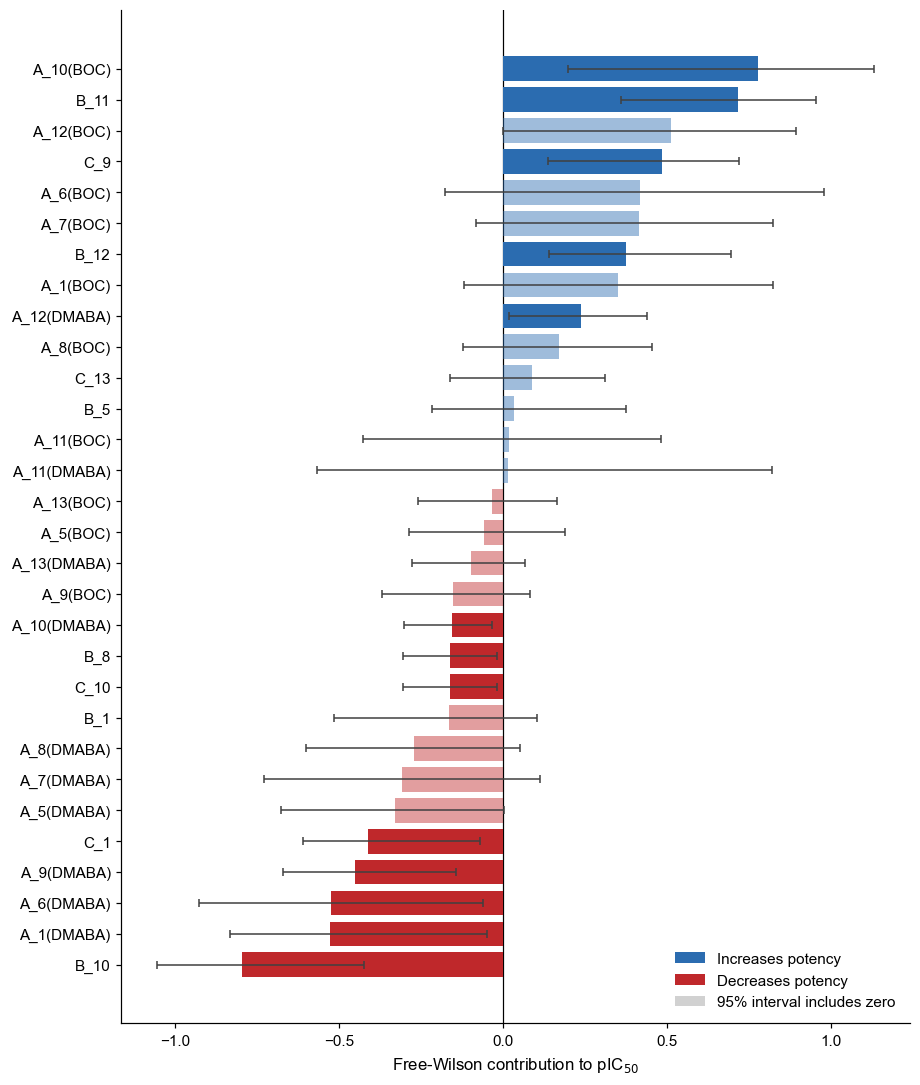

In [60]:
fig, ax = plt.subplots(figsize=(8.5, 10))
colours = ["#2B6CB0" if v > 0 else "#bf282b" for v in fw_ci["contribution"]]
bars = ax.barh(fw_ci["label"], fw_ci["contribution"], color=colours, zorder=2)
for bar, sig in zip(bars, fw_ci["excludes_zero"]):
    bar.set_alpha(1.0 if sig else 0.45)

ax.errorbar(fw_ci["contribution"], np.arange(len(fw_ci)),
            xerr=[fw_ci["contribution"] - fw_ci["ci_lo"],
                  fw_ci["ci_hi"] - fw_ci["contribution"]],
            fmt="none", ecolor="0.25", elinewidth=1.0, capsize=2.5, zorder=3)

ax.axvline(0, color="k", lw=0.8, zorder=1)
ax.set_xlabel("Free-Wilson contribution to pIC$_{50}$")
ax.legend(handles=[
    Patch(facecolor="#2B6CB0", label="Increases potency"),
    Patch(facecolor="#bf282b", label="Decreases potency"),
    Patch(facecolor="0.6", alpha=0.45, label="95% interval includes zero"),
], loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "free_wilson_contributions.png", dpi=300)
plt.show();

**Figure S1.** Free-Wilson fragment contributions to pIC₅₀ under the combined A-position coding, where each of the 20 A subunits carries its own coefficient, fitted on the 90 uncensored compounds. Figure 4 shows the split coding reported in the manuscript. Bars are ridge coefficient estimates and error bars are 95% percentile intervals from 2,000 bootstrap resamples at fixed penalty, α = 1. Faded bars indicate intervals spanning zero (17 of 30). The penalty is retained across resamples, so the intervals describe the penalised estimator and not an unbiased one. The ten matched BOC minus DMABA differences derived from this fit range from +0.00 to 0.94 pIC₅₀ units, with a median of 0.37, and are positive in all ten pairs. B_8 and C_10 co-occur in all 18 compounds carrying either, so their shared effect is split equally between them and cannot be separately attributed.

In [61]:
def scaffold_cv_score(X_df, y, groups=None, fold_list=None,
                      alphas=[0.01, 0.1, 1, 10, 100]):
    Xv = X_df.values if hasattr(X_df, "values") else np.asarray(X_df)
    yv = np.asarray(y, dtype=float)
    yhat = np.full_like(yv, np.nan, dtype=float)
    if fold_list is None:
        n_groups = len(np.unique(groups))
        splits = list(GroupKFold(n_splits=min(5, n_groups)).split(Xv, yv, groups))
    else:
        splits = []
        for k in range(len(fold_list)):
            te = np.array(fold_list[k])
            tr = np.array([i for j in range(len(fold_list)) if j != k
                           for i in fold_list[j]])
            splits.append((tr, te))
    for tr, te in splits:
        yhat[te] = RidgeCV(alphas=alphas).fit(Xv[tr], yv[tr]).predict(Xv[te])
    return r2_score(yv, yhat), np.sqrt(mean_squared_error(yv, yhat))

fw_unc_scaffold_r2 = scaffold_cv_score(
    build_X(fw_unc),
    fw_unc["pIC50"].values,
    groups=fw_unc["SMILES"].map(scaffold_smiles).values
)[0]

fw_unc_canon = set(fw_unc["_canon"])
lab_canon = labelled_df["SMILES"].map(canonical_smiles)
mask_fw = lab_canon.isin(fw_unc_canon).values

X_fw = X_labelled_full[mask_fw]
Y_fw = y_labelled[mask_fw]
groupS_fw = np.array([scaffold_smiles(s) for s in labelled_df.loc[mask_fw, "SMILES"]])
ng_fw = len(np.unique(groupS_fw))
print(f"Matched comparison: {mask_fw.sum()} compounds, {ng_fw} scaffold groups")

per_fold = []
rf_oof_fw = np.full(len(Y_fw), np.nan)
gp_oof_fw = np.full(len(Y_fw), np.nan)
for tr, te in GroupKFold(min(5, ng_fw)).split(X_fw, Y_fw, groupS_fw):
    rf_f = build_pipeline("random_forest", random_state=SEED, n_jobs=-1, **best_rf_params)
    rf_f.fit(X_fw[tr], Y_fw[tr])
    kern = RBF(length_scale=best_gp_params['length_scale']) + WhiteKernel(noise_level=best_gp_params['noise_level'])
    gp_f = build_pipeline("gp", kernel=kern, n_restarts_optimizer=2, random_state=SEED)
    gp_f.fit(X_fw[tr], Y_fw[tr])
    rf_oof_fw[te] = rf_f.predict(X_fw[te])
    gp_oof_fw[te] = gp_predict_with_std(gp_f, X_fw[te])[0]
    per_fold.append(np.sqrt(mean_squared_error(
        Y_fw[te], w_rf * rf_oof_fw[te] + w_gp * gp_oof_fw[te])))

ens_fw = w_rf * rf_oof_fw + w_gp * gp_oof_fw
ens_fw_r2 = r2_score(Y_fw, ens_fw)
ens_fw_rmse = np.sqrt(mean_squared_error(Y_fw, ens_fw))
print(f"RF-GP ensemble: R2={ens_fw_r2:.3f}, RMSE={ens_fw_rmse:.3f}")
print(f"Free-Wilson: R2={fw_unc_scaffold_r2:.3f}")
print("Per-fold RMSE:", [float(round(x, 3)) for x in per_fold])
print("Fold-to-fold RMSE SD:", round(np.std(per_fold, ddof=1), 3))

comparison = pd.DataFrame({
    "model": ["RF-GP ensemble (fingerprints), same 90",
              "Free-Wilson, combined A coding (30 terms)",
              "Free-Wilson, split stem + cap (22 terms)"],
    "scaffold_CV_R2": [round(ens_fw_r2, 3),
                       round(fw_unc_scaffold_r2, 3),
                       None],
})
comparison.to_csv(RESULTS_PRED / "model_comparison_matched.csv", index=False)

Matched comparison: 90 compounds, 55 scaffold groups
RF-GP ensemble: R2=0.373, RMSE=0.677
Free-Wilson: R2=0.360
Per-fold RMSE: [0.708, 0.625, 0.843, 0.629, 0.543]
Fold-to-fold RMSE SD: 0.113


The additive Free-Wilson model performs comparably to the fingerprint ensemble. Both are scored on the same 90 uncensored combinatorial compounds under the same scaffold GroupKFold, so the model is the only thing that changes. Under the combined A coding, the two models differed by 0.013 in R², with values of 0.360 against 0.373, respectively. Under the split coding, the Free-Wilson model has an R² 0.034 higher, at 0.407 compared with 0.373. The additive model achieves this on one-hot fragment identities alone, which is what makes its coefficients interpretable as per-fragment potency contributions. Figure S1 shows the fitted contributions.

The cap is the most reliably determined effect in the data. Removing it reduces the scaffold-CV R² by 0.081, compared with 0.274 for the central position and 0.055 for the C terminus (Section 9.7). The shared cap contrast is 0.580 pIC₅₀ units, a 3.8-fold effect, with a bootstrap interval of 0.292 to 0.837 and all 2,000 resamples positive. Its range is the smallest of the four blocks, against a 1.60 unit range across the B position, so the cap is the most reliably supported systematic effect but not the largest in magnitude.

This agrees with Boger et al., who found DMABA-capped trimers substantially less cytotoxic than the BOC-capped series and attributed the difference to reduced uptake of the charged species rather than weaker DNA binding (1). Additivity means the model cannot capture cap-by-residue exceptions such as the C7 side chain, where improved solubility favours the charged DMABA form (2). Each coefficient is an average across the whole series, so it does not necessarily apply to every individual compound.

In [62]:
_Xfw = build_X(fw_unc)
_gfw = fw_unc["SMILES"].map(scaffold_smiles).values

_covered, _total = 0, 0
for tr, te in GroupKFold(min(5, len(np.unique(_gfw)))).split(_Xfw.values, y_ref, _gfw):
    seen_frags = set(_Xfw.columns[_Xfw.iloc[tr].sum(axis=0) > 0])
    for i in te:
        frags = set(_Xfw.columns[_Xfw.iloc[i] > 0])
        _total += 1
        _covered += frags <= seen_frags

print(f"Test compounds whose fragments all appear in training: {_covered} of {_total} "
      f"({100*_covered/_total:.0f}%)")

Test compounds whose fragments all appear in training: 90 of 90 (100%)


Every test compound carried three subunits that were also included in the training set, as expected for 90 compounds distributed across only 30 fragment terms. Scaffold splitting separates Bemis-Murcko scaffolds and not fragments, so the Free-Wilson result measures recombination of a known fragment vocabulary and not extrapolation to unseen fragments. The fingerprint models are scored on the same folds under the same condition, so the comparison between them is unaffected.

### 9.7 A-Position Parameterisation, Stem and Cap

The combined coding in Section 9.6 treats each of the 20 A subunits as an independent category, so the two forms of a given stem share no information despite differing only in cap. Each coefficient is estimated from the two to nine compounds carrying that exact subunit. The split coding separates stem from cap, so a single cap contrast is estimated from all 90 compounds.

In [63]:
ALPHAS_FW = [0.01, 0.1, 1, 10, 100]
N_BOOT_SPLIT = 2000

def build_X_split(frame, cap_interaction=False):
    pos = frame["TYPE_fw"].str.split("+", regex=False, expand=True).iloc[:, :3].apply(lambda s: s.str.strip())
    pos.columns = ["A", "B", "C"]
    _ext = pos["A"].str.extract(r"^(?P<A_stem>.*?)\((?P<A_cap>[^()]*)\)\s*$")
    if _ext["A_stem"].isna().any():
        raise ValueError(f"A labels without a cap: {pos.loc[_ext['A_stem'].isna(),'A'].unique()}")
    pos["A_stem"] = _ext["A_stem"].str.strip()
    pos["A_cap"] = _ext["A_cap"].str.strip()
    pos = pos.drop(columns=["A"])
    if cap_interaction:
        pos["A_stemcap"] = pos["A_stem"] + "|" + pos["A_cap"]
    return pd.get_dummies(pos, prefix=pos.columns.tolist()).astype(float)

fw_s = fw_unc.copy()
y_s = fw_s["pIC50"].values
groups_s = fw_s["SMILES"].map(scaffold_smiles).values
print(f"n = {len(fw_s)} uncensored combinatorial compounds\n")

VARIANTS = {
    "combined A": build_X(fw_s),
    "split stem + cap": build_X_split(fw_s),
    "split + stem-cap interaction": build_X_split(fw_s, cap_interaction=True),
}

print("Scaffold-CV comparison of A-position parameterisations\n")
cv_rows = []
for name, Xdf in VARIANTS.items():
    _r2_v, _rmse_v = scaffold_cv_score(Xdf, y_s, groups=groups_s, alphas=ALPHAS_FW)
    cv_rows.append({"Parameterisation": name, "N_params": Xdf.shape[1],
                    "R2_scaffold": round(_r2_v, 3), "RMSE_scaffold": round(_rmse_v, 3)})
    print(f"{name:30s} | {Xdf.shape[1]:3d} params | R² {_r2_v:+.3f} | RMSE {_rmse_v:.3f}")

X_s = build_X_split(fw_s)
cols_s = X_s.columns
_ref = RidgeCV(alphas=ALPHAS_FW).fit(X_s.values, y_s)
alpha_s = float(_ref.alpha_)
point_s = pd.Series(_ref.coef_, index=cols_s)

rng_s = np.random.default_rng(SEED)
boot_s = np.full((N_BOOT_SPLIT, len(cols_s)), np.nan)
for b in range(N_BOOT_SPLIT):
    samp = fw_s.iloc[rng_s.choice(len(fw_s), len(fw_s), replace=True)]
    Xb = build_X_split(samp)
    m = Ridge(alpha=alpha_s).fit(Xb.reindex(columns=cols_s, fill_value=0.0).values,
                                 samp["pIC50"].values)
    c = pd.Series(m.coef_, index=cols_s)
    c[~cols_s.isin(Xb.columns)] = np.nan
    boot_s[b] = c.values

split_ci = pd.DataFrame({
    "term": cols_s,
    "contribution": point_s.values,
    "ci_lo": np.nanpercentile(boot_s, 2.5, axis=0),
    "ci_hi": np.nanpercentile(boot_s, 97.5, axis=0),
    "n_compounds": X_s.sum(axis=0).values.astype(int),
})
split_ci["excludes_zero"] = (split_ci["ci_lo"] > 0) | (split_ci["ci_hi"] < 0)
split_ci = split_ci.sort_values("contribution").reset_index(drop=True)

_comb_excl = int(fw_ci["excludes_zero"].sum())
_comb_n = len(fw_ci)
_comb_thin = int((fw_ci["n_compounds"] < 5).sum())
print(f"\nIntervals excluding zero: split {int(split_ci['excludes_zero'].sum())} of {len(split_ci)}, "
      f"combined {_comb_excl} of {_comb_n}")
print(f"Terms on fewer than 5 compounds: split {int((split_ci['n_compounds'] < 5).sum())}, "
      f"combined {_comb_thin}\n")

cap_rows = split_ci[split_ci["term"].str.startswith("A_cap_")]
print("Cap coefficients, estimated across all 90 compounds:")
print(cap_rows[["term", "contribution", "ci_lo", "ci_hi", "n_compounds"]]
      .round(3).to_string(index=False))
assert len(cap_rows) == 2, f"Expected 2 cap indicators, got {len(cap_rows)}"
gap = cap_rows["contribution"].max() - cap_rows["contribution"].min()

print(f"\nBOC - DMABA, shared estimate: {gap:.3f} pIC₅₀ units ({10**gap:.1f}-fold)")
print(f"Combined-model matched pairs (for comparison): median "
        f"{np.median(cap_pair_diffs):.2f}, max {np.max(cap_pair_diffs):.2f}")

_b_rows = split_ci[split_ci["term"].str.startswith("B_")]
_b_span = _b_rows["contribution"].max() - _b_rows["contribution"].min()

_a_rows = split_ci[split_ci["term"].str.startswith("A_stem_")]
_c_rows = split_ci[split_ci["term"].str.startswith("C_")]
print(f"A stem coefficient span: {_a_rows['contribution'].max() - _a_rows['contribution'].min():.3f} pIC₅₀ units")
print(f"B position coefficient span: {_b_span:.3f} pIC₅₀ units")
print(f"C position coefficient span: {_c_rows['contribution'].max() - _c_rows['contribution'].min():.3f} pIC₅₀ units")

print("\nTerms with intervals excluding zero:")
print(split_ci[split_ci["excludes_zero"]][
    ["term", "contribution", "ci_lo", "ci_hi", "n_compounds"]].round(3).to_string(index=False))

pd.DataFrame(cv_rows).to_csv(RESULTS_PRED / "free_wilson_Asplit_cv.csv", index=False)
split_ci.to_csv(RESULTS_PRED / "free_wilson_Asplit_contributions_ci.csv", index=False)

comparison.loc[comparison["model"].str.startswith("Free-Wilson, split"),
               "scaffold_CV_R2"] = cv_rows[1]["R2_scaffold"]
comparison.to_csv(RESULTS_PRED / "model_comparison_matched.csv", index=False)

display(Markdown("**Table S15.** Free-Wilson and fingerprint ensemble performance on 90 uncensored combinatorial compounds using identical scaffold folds."))
show(comparison)

n = 90 uncensored combinatorial compounds

Scaffold-CV comparison of A-position parameterisations

combined A                     |  30 params | R² +0.360 | RMSE 0.684
split stem + cap               |  22 params | R² +0.407 | RMSE 0.659
split + stem-cap interaction   |  42 params | R² +0.307 | RMSE 0.712

Intervals excluding zero: split 10 of 22, combined 13 of 30
Terms on fewer than 5 compounds: split 1, combined 12

Cap coefficients, estimated across all 90 compounds:
       term  contribution  ci_lo  ci_hi  n_compounds
A_cap_DMABA         -0.29 -0.418 -0.146           34
  A_cap_BOC          0.29  0.146  0.418           56

BOC - DMABA, shared estimate: 0.580 pIC₅₀ units (3.8-fold)
Combined-model matched pairs (for comparison): median 0.37, max 0.94
A stem coefficient span: 0.772 pIC₅₀ units
B position coefficient span: 1.601 pIC₅₀ units
C position coefficient span: 0.993 pIC₅₀ units

Terms with intervals excluding zero:
       term  contribution  ci_lo  ci_hi  n_compounds
      B_1

**Table S15.** Free-Wilson and fingerprint ensemble performance on 90 uncensored combinatorial compounds using identical scaffold folds.

model,scaffold_CV_R2
"RF-GP ensemble (fingerprints), same 90",0.373
"Free-Wilson, combined A coding (30 terms)",0.360
"Free-Wilson, split stem + cap (22 terms)",0.407


In [64]:
POS = {"cap": "A_cap_", "A stem": "A_stem_", "B": "B_", "C": "C_"}

_comb = pd.Series(RidgeCV(alphas=ALPHAS_FW)
                  .fit(build_X(fw_s).values, y_s).coef_,
                  index=build_X(fw_s).columns)
_shared = [t for t in cols_s if t.startswith(("B_", "C_"))]
cb = _comb.reindex(_shared)
sp = point_s.reindex(_shared)

_iB, _iD = list(cols_s).index("A_cap_BOC"), list(cols_s).index("A_cap_DMABA")
cap_boot = boot_s[:, _iB] - boot_s[:, _iD]
cap_pt = float(point_s["A_cap_BOC"] - point_s["A_cap_DMABA"])
cap_lo, cap_hi = np.nanpercentile(cap_boot, [2.5, 97.5])
print(f"Cap contrast BOC - DMABA = {cap_pt:.3f} [{cap_lo:.3f}, {cap_hi:.3f}] "
      f"({10**cap_pt:.2f}-fold), replicates positive: {np.nanmean(cap_boot > 0):.4f}")

Cap contrast BOC - DMABA = 0.580 [0.292, 0.837] (3.80-fold), replicates positive: 1.0000


In [65]:
print("Effect of removing each position (drop-and-refit):\n")
base_r2, _ = scaffold_cv_score(build_X_split(fw_s), y_s, groups=groups_s, alphas=ALPHAS_FW)
drop_rows = []
for name, pre in POS.items():
    Xd = build_X_split(fw_s)
    Xd = Xd.loc[:, ~Xd.columns.str.startswith(pre)]
    r2d, _ = scaffold_cv_score(Xd, y_s, groups=groups_s, alphas=ALPHAS_FW)
    print(f"  {name:8s} dropped -> R2 {r2d:+.3f}  (delta {base_r2-r2d:+.3f})")
    drop_rows.append({"position": name, "R2_without": round(r2d, 3),
                      "delta_R2": round(base_r2 - r2d, 3)})

pd.DataFrame(drop_rows).sort_values("delta_R2", ascending=False).to_csv(
    RESULTS_PRED / "free_wilson_position_variance.csv", index=False)

Effect of removing each position (drop-and-refit):

  cap      dropped -> R2 +0.326  (delta +0.081)
  A stem   dropped -> R2 +0.377  (delta +0.030)
  B        dropped -> R2 +0.132  (delta +0.274)
  C        dropped -> R2 +0.352  (delta +0.055)


In [66]:
_cmp = pd.DataFrame({"combined": cb, "split": sp})
_cmp["flipped"] = np.sign(_cmp["combined"]) != np.sign(_cmp["split"])
_cmp["resolvable_split"] = _cmp.index.map(
    split_ci.set_index("term")["excludes_zero"])
print(_cmp.round(3).to_string())

       combined  split  flipped  resolvable_split
B_10b    -0.797 -0.781    False              True
B_11b     0.719  0.820    False              True
B_12b     0.375  0.294    False              True
B_1b     -0.166 -0.074    False             False
B_5b      0.033 -0.116     True             False
B_8b     -0.163 -0.141    False             False
C_10a    -0.163 -0.141    False             False
C_13a     0.090  0.087    False             False
C_1a     -0.411 -0.469    False              True
C_9a      0.484  0.523    False              True


In [67]:
X_full = build_X_split(fw_s)
X_noA  = X_full.loc[:, ~X_full.columns.str.startswith("A_stem_")]

print("A-stem removal across seven fold constructions\n")
for sd in [0, 1, 2, SEED, 123, 7, 99]:
    f_sd = scaffold_split(fw_s.reset_index(drop=True), n_splits=5, random_state=sd)
    r_full, _ = scaffold_cv_score(X_full, y_s, fold_list=f_sd)
    r_noA,  _ = scaffold_cv_score(X_noA, y_s, fold_list=f_sd)
    print(f"  seed {sd}: full {r_full:+.3f} | no A-stem {r_noA:+.3f} "
          f"| delta {r_noA - r_full:+.3f}")

print("\nControl: the A-stem block replaced by 10 random categorical columns\n")
rng_c = np.random.default_rng(SEED)
for trial in range(3):
    fake = pd.get_dummies(pd.Series(rng_c.integers(0, 10, len(fw_s)),
                                    index=X_full.index).astype(str),
                          prefix="fake").astype(float)
    X_fake = pd.concat([X_noA, fake], axis=1)
    f_sd = scaffold_split(fw_s.reset_index(drop=True), n_splits=5, random_state=SEED)
    r_fake, _ = scaffold_cv_score(X_fake, y_s, fold_list=f_sd)
    r_noA,  _ = scaffold_cv_score(X_noA, y_s, fold_list=f_sd)
    print(f"  trial {trial}: with 10 random cols {r_fake:+.3f} | without {r_noA:+.3f} "
          f"| delta {r_noA - r_fake:+.3f}")

A-stem removal across seven fold constructions

  seed 0: full +0.434 | no A-stem +0.413 | delta -0.021
  seed 1: full +0.433 | no A-stem +0.374 | delta -0.059
  seed 2: full +0.472 | no A-stem +0.406 | delta -0.065
  seed 42: full +0.457 | no A-stem +0.444 | delta -0.013
  seed 123: full +0.354 | no A-stem +0.348 | delta -0.006
  seed 7: full +0.456 | no A-stem +0.349 | delta -0.107
  seed 99: full +0.436 | no A-stem +0.399 | delta -0.037

Control: the A-stem block replaced by 10 random categorical columns

  trial 0: with 10 random cols +0.372 | without +0.444 | delta +0.073
  trial 1: with 10 random cols +0.337 | without +0.444 | delta +0.107
  trial 2: with 10 random cols +0.347 | without +0.444 | delta +0.098


Three parameterisations of the A position were compared on the same 90 uncensored compounds under the same scaffold folds. The combined coding reaches R² 0.360 on 30 parameters, the split stem and cap coding reaches 0.407 on 22, and adding the stem by cap interaction reduces R² to 0.307 on 42. The split coding improves R² by 0.047 compared with the combined coding, with the interaction terms reducing accuracy.

Dropping each position in turn and refitting shows the change in scaffold-CV R² when that position is removed. B contributes 0.274 to R², the cap 0.081, the C position 0.055 and the A stem 0.030. Across seven fold constructions the A stem delta ranges from -0.107 to -0.006, so its sign is consistent. Ten random categorical columns in place of the A stem block reduce R² by 0.073 to 0.107. Replacing the block with noise of the same width causes a larger reduction in performance than removing it, so the effect is not explained by block size alone.

B_5b changes sign between the two codings while their intervals span zero under both, so neither sign should be interpreted. B_8b and C_10a always occur together, so the fit assigns their combined effect equally between them and neither can be estimated independently.

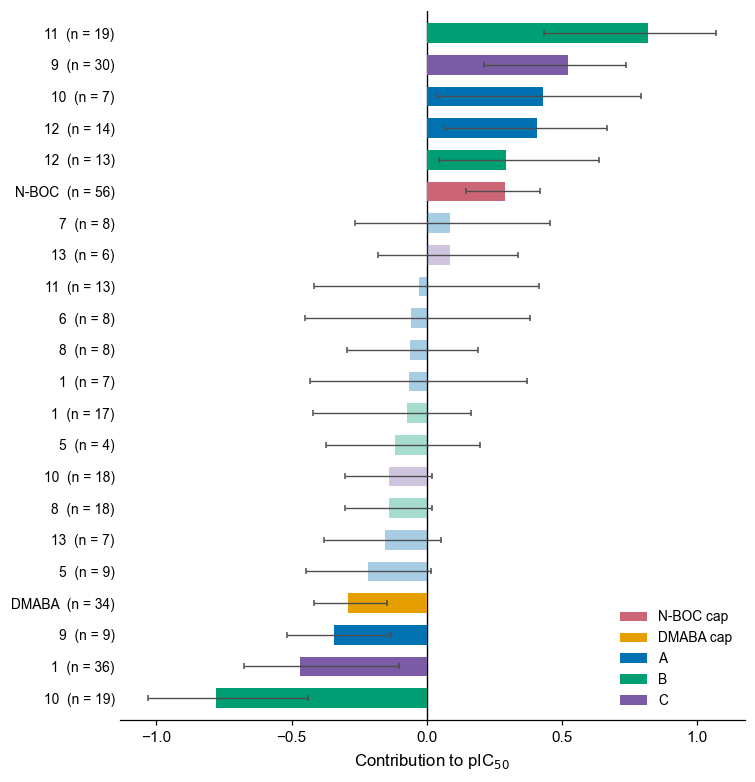

In [68]:
GROUP = {"A_cap_BOC": "N-BOC cap", "A_cap_DMABA": "DMABA cap"}

def _code(t):
    if t == "A_cap_BOC": return "N-BOC"
    if t == "A_cap_DMABA": return "DMABA"
    raw = t[len("A_stem_"):] if t.startswith("A_stem_") else t.split("_", 1)[-1]
    return re.sub(r"(\d+)[ab](?=\(|$)", r"\1", raw)

def _grp(t):
    if t in GROUP: return GROUP[t]
    if t.startswith("A_stem_"): return "A"
    if t.startswith("B_"): return "B"
    if t.startswith("C_"): return "C"
    return "other"

def _lab(t, n):
    return f"{_code(t)}  (n = {n})"

P = split_ci.copy()
P["group"] = P["term"].map(_grp)
P["label"] = [_lab(t, n) for t, n in zip(P["term"], P["n_compounds"])]
P = P.sort_values("contribution").reset_index(drop=True)
ypos = np.arange(len(P))

GC = {"N-BOC cap": "#CC6677", "DMABA cap": "#E69F00",
      "A": "#0072B2", "B": "#009E73", "C": "#7B5AA6"}
ORDER = ["N-BOC cap", "DMABA cap", "A", "B", "C"]

fig, ax = plt.subplots(figsize=(7.0, 0.27 * len(P) + 1.3))

bars = ax.barh(ypos, P["contribution"], color=[GC[g] for g in P["group"]],
               height=0.62, zorder=2)
for bar, sig in zip(bars, P["excludes_zero"]):
    bar.set_alpha(1.0 if sig else 0.35)

ax.errorbar(P["contribution"], ypos,
            xerr=[P["contribution"] - P["ci_lo"], P["ci_hi"] - P["contribution"]],
            fmt="none", ecolor="0.3", elinewidth=0.9, capsize=2, zorder=3)

ax.axvline(0, color="k", lw=0.9, zorder=1)
ax.set_yticks(ypos)
ax.set_yticklabels(P["label"], fontsize=9)
ax.set_ylim(-0.7, len(P) - 0.3)
ax.set_xlabel("Contribution to pIC$_{50}$")
ax.tick_params(axis="y", length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

ax.legend(handles=[Patch(facecolor=GC[g], label=g) for g in ORDER],
          frameon=False, fontsize=9, loc="lower right")

plt.tight_layout()

plt.savefig(RESULTS_FIG / "model_evaluation" / "figure4_split_fragment_contributions.png",
            dpi=300, bbox_inches="tight")

plt.savefig(RESULTS_FIG / "model_evaluation" / "figure4_split_fragment_contributions.svg",
            bbox_inches="tight")

plt.show()

**Figure 4.** Per-fragment contributions to cytotoxic potency under the split A-position coding, fitted on the 90 uncensored combinatorial compounds. Bars are ridge coefficients in pIC₅₀ units, sorted by value and coloured by position, with 95% percentile intervals from 2,000 bootstrap resamples at fixed penalty. Faded bars have intervals spanning zero. Counts give the compounds supporting each term. All 22 fitted terms are shown. The two cap indicators are complementary and sum to zero by construction, so they carry one degree of freedom between them, and their difference is the cap contrast quoted in the text. 8 (position B) and 10 (position C) co-occur in all 18 compounds carrying either, so their equal coefficients represent one shared effect divided between two terms and do not represent two separate effects.

The fitted terms also define the applicability domain of this model, which is categorical rather than continuous. A prediction is possible only when all three subunits are represented by fitted coefficients, covering 480 of the 2,640 enumerated structures, 101 of which are already labelled. Out of 480, B_8b or C_10a appears 160 times with a partner never observed alongside it, so additivity is assumed there and not directly supported by the training data.

In [69]:
_lib = pd.read_csv(DATA_PROC / "cleandata.csv")

def _positions(series):
    p = series.str.split("+", regex=False, expand=True).iloc[:, :3].apply(lambda s: s.str.strip())
    p.columns = ["A", "B", "C"]
    return p

_fit = _positions(fw_s["TYPE_fw"])
_lib_pos = _positions(_lib["TYPE"])

in_domain = (_lib_pos["A"].isin(_fit["A"]) &
             _lib_pos["B"].isin(_fit["B"]) &
             _lib_pos["C"].isin(_fit["C"]))

_lab_canon = set(fw["SMILES"].map(canonical_smiles))
_lib_canon = _lib["SMILES"].map(canonical_smiles)

_unobserved = (((_lib_pos["B"] == "8b") & (_lib_pos["C"] != "10a")) |
               ((_lib_pos["C"] == "10a") & (_lib_pos["B"] != "8b")))

print(f"Fitted subunits: A {_fit['A'].nunique()}, B {_fit['B'].nunique()}, C {_fit['C'].nunique()}")
print(f"Additive model domain: {int(in_domain.sum())} of {len(_lib)} enumerated structures")
print(f"Labelled: {int(_lib_canon[in_domain].isin(_lab_canon).sum())}")
print(f"B_8b or C_10a with an unfitted subunit: {int((in_domain & _unobserved).sum())}")

Fitted subunits: A 20, B 6, C 4
Additive model domain: 480 of 2640 enumerated structures
Labelled: 101
B_8b or C_10a with an unfitted subunit: 160


### 9.8 External Validation on Independent ChEMBL L1210 Actives

Similar compounds were retrieved from ChEMBL target CHEMBL386 (L1210 murine leukaemia) on 10 August 2026 and cached to `chembl_l1210_neighbours.csv`, with the underlying activity records cached to `chembl_l1210_activity_records.csv` and the merged potency values to `external_activities.csv`. All structures were desalted before the similarity search.

In [70]:
ids = nbr["chembl_id"].tolist()
_ext_cache = DATA_PROC / "external_activities.csv"
if _ext_cache.exists():
    print(f"Loaded external activities from cache ({_ext_cache.name})")
else:
    print("No cache found; querying ChEMBL live.")
    mw = {r.chembl_id: Descriptors.MolWt(Chem.MolFromSmiles(r.smiles)) for r in nbr.itertuples()}

    POTENCY_TYPES = {"IC50", "ID50", "GI50", "EC50", "ED50"}

    recs = new_client.activity.filter(
        target_chembl_id="CHEMBL386", molecule_chembl_id__in=ids,
    ).only(["molecule_chembl_id","standard_type","standard_relation",
            "standard_value","standard_units","pchembl_value"])

    def to_pIC50(v, units, cid):
        u = (units or "").strip().lower().replace(".", " ")
        if   u in ("nm",): M = v*1e-9
        elif u in ("um","µm"): M = v*1e-6
        elif u in ("mm",): M = v*1e-3
        elif u in ("pm",): M = v*1e-12
        elif u in ("m",): M = v
        elif u in ("ug ml-1","ug/ml","ug ml","µg ml-1") and mw.get(cid):
            M = (v*1e-3)/mw[cid]
        else:
            return None
        return -np.log10(M) if M and M > 0 else None

    n_total = n_type = n_cens = n_units = 0
    rows = []
    for rec in recs:
        n_total += 1
        cid, st = rec.get("molecule_chembl_id"), (rec.get("standard_type") or "").strip()
        if st not in POTENCY_TYPES:                                   n_type += 1; continue
        if (rec.get("standard_relation") or "=") not in ("=", "~"):     n_cens += 1; continue
        pIC50 = float(rec["pchembl_value"]) if rec.get("pchembl_value") not in (None,"") else None
        if pIC50 is None:
            try: v = float(rec.get("standard_value"))
            except (TypeError, ValueError): v = None
            if v and v > 0: pIC50 = to_pIC50(v, rec.get("standard_units"), cid)
        if pIC50 is None: n_units += 1; continue
        rows.append((cid, st, pIC50))

    raw = pd.DataFrame(rows, columns=["chembl_id","type","pIC50"])
    act = raw.groupby("chembl_id", as_index=False)["pIC50"].median()
    act.to_csv(DATA_PROC / "external_activities.csv", index=False)

    print(f"records pulled = {n_total}")
    print(f"dropped non-potency = {n_type}")
    print(f"dropped censored = {n_cens}")
    print(f"dropped unconvertible = {n_units}")
    print(f"records kept = {len(raw)}  {raw['type'].value_counts().to_dict()}")
    print(f"unique external compounds = {len(act)} / {len(ids)}")

Loaded external activities from cache (external_activities.csv)


In [71]:
act = pd.read_csv(DATA_PROC / "external_activities.csv")
ext = nbr.merge(act, on="chembl_id", how="inner")

n_merged = len(ext)

train_keys = set(k for k in labelled_df["SMILES"].map(canonical_smiles) if k)
ext["is_train_dup"] = ext["smiles"].map(canonical_smiles).isin(train_keys)

fp_flagged = ext.loc[ext["nn_tanimoto"] >= 0.99, "chembl_id"].tolist()
dropped = ext.loc[ext["is_train_dup"], "chembl_id"].tolist()
print(f"Fingerprint match at >=0.99: {fp_flagged}")
print(f"Structural duplicates: {dropped if dropped else 'none'}")

for _r in ext.loc[ext["nn_tanimoto"] >= 0.999].itertuples():
    print(f"{_r.chembl_id} (pIC₅₀ {_r.pIC50:.2f}): differs from a labelled compound "
          f"by one pyrrole, identical fingerprint at radius 2")

ext = ext[~ext["is_train_dup"]].reset_index(drop=True)

Xext = featurise_molecules(ext["smiles"])

ext["pIC50_pred_ens"] = w_rf * rf.predict(Xext) + w_gp * gpr.predict(Xext)
ext["pIC50_pred_br"] = br.predict(Xext)
ext["pIC50_pred"] = ext["pIC50_pred_br"]

def rank_check(name, pred):
    pred = np.asarray(pred)
    r, pv = spearmanr(pred, ext["pIC50"])
    rng = np.random.default_rng(SEED)
    idx = np.arange(len(ext)); boot = []
    for _ in range(2000):
        s = rng.choice(idx, len(idx), replace=True)
        if len(np.unique(ext["pIC50"].values[s])) > 2:
            boot.append(spearmanr(pred[s], ext["pIC50"].values[s])[0])
    b_lo, b_hi = np.percentile(boot, [2.5, 97.5])
    span = pred.max() - pred.min()
    print(f"  {name:30s} rho={r:.3f}  p={pv:.3g}  95% CI [{b_lo:.2f}, {b_hi:.2f}]  "
          f"predicted span={span:.2f}")
    return r, pv, b_lo, b_hi

print("External validation on independent ChEMBL L1210 actives")
print(f"Compounds with exact activity values: {n_merged}")
print(f"Removed as near-duplicates: {', '.join(dropped) if dropped else 'none'}")
print(f"Tanimoto to training set: {ext['nn_tanimoto'].min():.2f}-{ext['nn_tanimoto'].max():.2f}")
print(f"Measured pIC50 range: {ext['pIC50'].min():.2f}-{ext['pIC50'].max():.2f}")

br_stats = rank_check("Bayesian Ridge (primary)", ext["pIC50_pred_br"])
rank_check("RF-GP ensemble (comparison)", ext["pIC50_pred_ens"])

meas_span = ext["pIC50"].max() - ext["pIC50"].min()
for tag, col in (("Bayesian Ridge", "pIC50_pred_br"), ("RF-GP ensemble", "pIC50_pred_ens")):
    sp = ext[col].max() - ext[col].min()
    print(f"Prediction compression, {tag}: measured span {meas_span:.2f} / predicted span {sp:.2f} "
          f"= {meas_span/sp:.1f}-fold")

rho, p, lo, hi = br_stats

Fingerprint match at >=0.99: ['CHEMBL540264']
Structural duplicates: none
CHEMBL540264 (pIC₅₀ 7.63): differs from a labelled compound by one pyrrole, identical fingerprint at radius 2
External validation on independent ChEMBL L1210 actives
Compounds with exact activity values: 13
Removed as near-duplicates: none
Tanimoto to training set: 0.70-1.00
Measured pIC50 range: 3.08-7.63
  Bayesian Ridge (primary)       rho=0.560  p=0.0463  95% CI [-0.09, 0.90]  predicted span=0.60
  RF-GP ensemble (comparison)    rho=0.505  p=0.078  95% CI [-0.09, 0.81]  predicted span=0.38
Prediction compression, Bayesian Ridge: measured span 4.56 / predicted span 0.60 = 7.6-fold
Prediction compression, RF-GP ensemble: measured span 4.56 / predicted span 0.38 = 11.9-fold


In [72]:
clean = pd.read_csv(DATA_PROC / "cleandata.csv")
enum_keys = {k: s for k, s in zip(clean["SMILES"].map(lambda x: canonical_smiles(x, desalt=True, neutralise=True)), clean["SMILES"]) if k}

nbr_chk = pd.read_csv(DATA_PROC / "chembl_l1210_neighbours.csv")
found = [(r.chembl_id, r.smiles) for r in nbr_chk.itertuples()
         if canonical_smiles(r.smiles, desalt=True, neutralise=True) in enum_keys]

print(f"ChEMBL neighbours matching a member of the {len(enum_keys):,} enumerated library: {len(found)}")
for cid, smi in found:
    print("  ", cid, smi)
print(f"\nReference sets: {len(labelled_df)} labelled, {len(enum_keys)} enumerated library members")

ChEMBL neighbours matching a member of the 2,640 enumerated library: 0

Reference sets: 116 labelled, 2640 enumerated library members


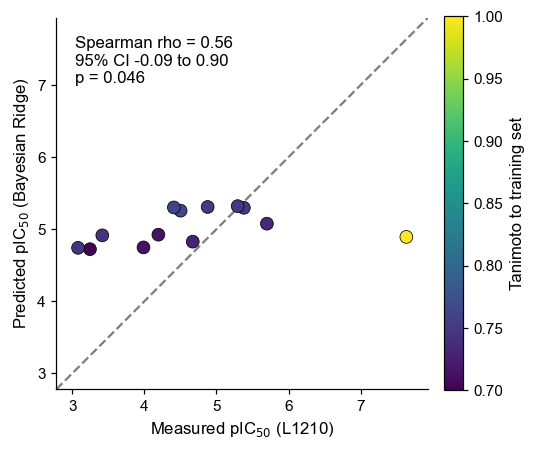

In [73]:
fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(ext["pIC50"], ext["pIC50_pred"], c=ext["nn_tanimoto"],
                cmap="viridis", s=70, edgecolor="k", linewidth=0.5, zorder=3)
lims = [min(ext["pIC50"].min(), ext["pIC50_pred"].min()) - 0.3,
        max(ext["pIC50"].max(), ext["pIC50_pred"].max()) + 0.3]
ax.plot(lims, lims, "--", color="grey", zorder=1, label="identity")
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("Measured pIC$_{50}$ (L1210)")
ax.set_ylabel("Predicted pIC$_{50}$ (Bayesian Ridge)")
ax.text(0.05, 0.95, f"Spearman rho = {rho:.2f}\n95% CI {lo:.2f} to {hi:.2f}\np = {p:.3f}",
        transform=ax.transAxes, va="top", ha="left")
cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Tanimoto to training set")
plt.tight_layout()
plt.savefig(RESULTS_FIG / "predictions" / "external_validation.png", dpi=300, bbox_inches="tight")
plt.show();

**Figure S7.** Predicted against measured pIC₅₀ for the 13 ChEMBL L1210 neighbours with exact activity values from the Bayesian Ridge model. Spearman ρ = 0.560, p = 0.0463, 95% CI [−0.09, 0.90].

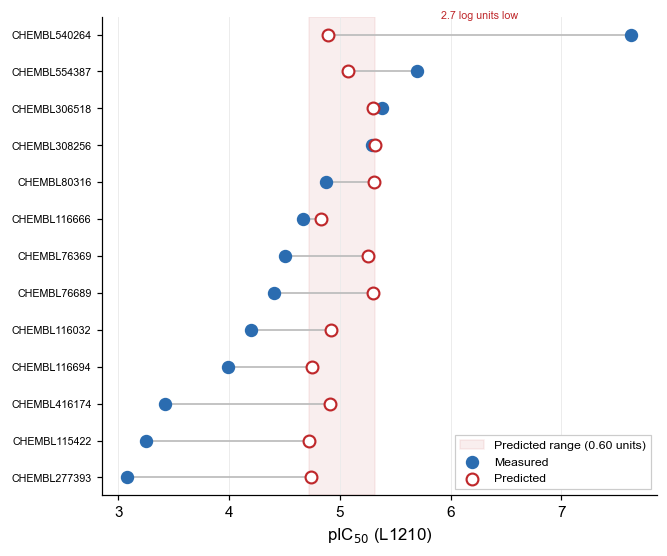

Measured range 4.56, Predicted range 0.60, Compression 7.6-fold


In [74]:
_BLUE, _ACCENT = "#2B6CB0", "#bf282b"

assert "pIC50_pred_br" in ext.columns, "run the external validation cell above first"
if len(ext) != 13:
    print(f"WARNING: {len(ext)} external compounds, expected 13. Numbers below will not match those reported.")

_b = ext.sort_values("pIC50", ascending=True).reset_index(drop=True)
_b["pIC50_pred"] = _b["pIC50_pred_br"]
_y = np.arange(len(_b))
_plo, _phi = _b["pIC50_pred"].min(), _b["pIC50_pred"].max()
_ti = int(_b["pIC50"].idxmax())

_fig, _ax = plt.subplots(figsize=(6.2, 5.2))

_ax.axvspan(_plo, _phi, color=_ACCENT, alpha=0.08, zorder=0,
            label=f"Predicted range ({_phi - _plo:.2f} units)")
_ax.hlines(_y, _b["pIC50"], _b["pIC50_pred"], color="0.75", linewidth=1.2, zorder=1)
_ax.scatter(_b["pIC50"], _y, s=60, facecolor=_BLUE, edgecolor=_BLUE,
            linewidth=1, zorder=3, label="Measured")
_ax.scatter(_b["pIC50_pred"], _y, s=60, facecolor="white", edgecolor=_ACCENT,
            linewidth=1.4, zorder=3, label="Predicted")

_ax.annotate(f"{_b.loc[_ti, 'pIC50'] - _b.loc[_ti, 'pIC50_pred']:.1f} log units low",
             xy=((_b.loc[_ti, "pIC50_pred"] + _b.loc[_ti, "pIC50"]) / 2, _ti),
             xytext=(0, 9), textcoords="offset points",
             fontsize=7, color=_ACCENT, ha="center", va="bottom", zorder=6)

_ax.set_yticks(_y)
_ax.set_yticklabels(_b["chembl_id"], fontsize=7)
_ax.set_xlabel("pIC$_{50}$ (L1210)")
_ax.margins(y=0.04)
_ax.grid(axis="x", color="0.92", linewidth=0.6, zorder=0)
_ax.set_axisbelow(True)

_leg = _ax.legend(loc="lower right", frameon=True, framealpha=1.0,
                  edgecolor="0.8", fancybox=False, fontsize=8)
_leg.get_frame().set_linewidth(0.8)

_fig.tight_layout()
for _fmt in ("png", "svg"):
    _fig.savefig(RESULTS_FIG / "predictions" / f"external_validation_range.{_fmt}",
                 dpi=300, bbox_inches="tight")
plt.show()

_ms = _b["pIC50"].max() - _b["pIC50"].min()
print(f"Measured range {_ms:.2f}, Predicted range {_phi - _plo:.2f}, Compression {_ms / (_phi - _plo):.1f}-fold")

**Figure S8.** Measured and predicted pIC₅₀ ranges for the 13 external compounds under the Bayesian Ridge model. The measured range is 4.56 log units, compared with a predicted range of 0.60 log units, giving a 7.6-fold compression.

In [75]:
UGML_FLOOR = 100.0

_recs = pd.read_csv(DATA_PROC / "chembl_l1210_activity_records.csv")
_units = (_recs["standard_units"].fillna("")
          .str.replace(".", " ", regex=False).str.lower().str.strip())
INACTIVE_IDS = sorted(_recs.loc[
    (_recs["standard_relation"] == ">") &
    (_recs["standard_type"] == "ID50") &
    (_units == "ug ml-1") &
    (_recs["standard_value"] >= UGML_FLOOR),
    "molecule_chembl_id"].unique())
if len(INACTIVE_IDS) != 8:
    print(f"WARNING: {len(INACTIVE_IDS)} external compounds, expected 8. Numbers below will not match those reported.")

inact = nbr[nbr["chembl_id"].isin(INACTIVE_IDS)][["chembl_id","smiles","nn_tanimoto"]].copy()
inact = inact[inact["nn_tanimoto"] < 0.99].reset_index(drop=True)
mw = inact["smiles"].map(lambda s: Descriptors.MolWt(Chem.MolFromSmiles(s)))
inact["pIC50"] = -np.log10((UGML_FLOOR * 1e-3) / mw)
inact["label"] = "inactive (>100 µg/mL)"

act_prim = ext[["chembl_id","smiles","nn_tanimoto","pIC50"]].copy()
act_prim["label"] = "active"
ext2 = pd.concat([act_prim, inact], ignore_index=True)

X2 = featurise_molecules(ext2["smiles"])
ext2["pIC50_pred_br"] = br.predict(X2)
ext2["pIC50_pred_ens"] = w_rf * rf.predict(X2) + w_gp * gpr.predict(X2)

def _boot_rho(pred, truth):
    r, pv = spearmanr(pred, truth)
    rng = np.random.default_rng(SEED)
    idx = np.arange(len(truth)); boot = []
    for _ in range(2000):
        s = rng.choice(idx, len(idx), replace=True)
        if len(np.unique(np.asarray(truth)[s])) > 2:
            boot.append(spearmanr(np.asarray(pred)[s], np.asarray(truth)[s])[0])
    b_lo, b_hi = np.percentile(boot, [2.5, 97.5])
    return r, pv, b_lo, b_hi

print("Secondary check, actives plus known inactives (rank separation)")
print(f"n = {len(ext2)} ({(ext2['label']=='active').sum()} actives + "
      f"{(ext2['label']!='active').sum()} inactives)")
print(f"Inactive floor, pIC₅₀ {inact['pIC50'].min():.2f}-{inact['pIC50'].max():.2f}")

for tag, col in (("Bayesian Ridge (primary)", "pIC50_pred_br"),
                 ("RF-GP ensemble (comparison)", "pIC50_pred_ens")):
    r2_, p2_, lo2_, hi2_ = _boot_rho(ext2[col], ext2["pIC50"])
    prim = spearmanr(ext[col], ext["pIC50"])[0]
    inact_band = ext2.loc[ext2["label"] != "active", col]
    print(f"\n{tag}")
    print(f"n=21  rho={r2_:.3f}  p={p2_:.3g}  95% CI [{lo2_:.2f}, {hi2_:.2f}]")
    print(f"n=13  rho={prim:.3f}")
    print(f"Inactives predicted {inact_band.min():.2f}-{inact_band.max():.2f}")

Secondary check, actives plus known inactives (rank separation)
n = 21 (13 actives + 8 inactives)
Inactive floor, pIC₅₀ 3.64-4.00

Bayesian Ridge (primary)
n=21  rho=0.503  p=0.0202  95% CI [0.05, 0.79]
n=13  rho=0.560
Inactives predicted 4.77-5.63

RF-GP ensemble (comparison)
n=21  rho=0.419  p=0.0584  95% CI [-0.01, 0.72]
n=13  rho=0.505
Inactives predicted 4.70-5.12


In [76]:
e = ext.sort_values("pIC50", ascending=False).reset_index(drop=True)  # 13 actives, most potent first
k = 6
meas_top = set(e.nlargest(k, "pIC50")["chembl_id"])
meas_span = e["pIC50"].max() - e["pIC50"].min()
print(f"Measured range (actives): {e['pIC50'].min():.2f}-{e['pIC50'].max():.2f}  "
      f"Span {meas_span:.2f}")

for tag, col in (("Bayesian Ridge (primary)", "pIC50_pred_br"),
                 ("RF-GP ensemble (comparison)", "pIC50_pred_ens")):
    order = e[col].rank(ascending=False, method="min").astype(int)
    print(f"\n{tag}")
    print(f"Most potent compound {e.loc[0,'chembl_id']} "
          f"(measured pIC50 {e.loc[0,'pIC50']:.2f}) ranked {int(order[0])} of {len(e)}")
    pred_top = set(e.nlargest(k, col)["chembl_id"])
    print(f"Top-{k} overlap: {len(pred_top & meas_top)} of {k}")
    pred_vals, meas_vals = e[col].values, e["pIC50"].values
    pairs = [(np.sign(pred_vals[i]-pred_vals[j]), np.sign(meas_vals[i]-meas_vals[j]))
             for i in range(len(e)) for j in range(i+1, len(e)) if meas_vals[i] != meas_vals[j]]
    conc = sum(1 for a, b in pairs if a == b)
    print(f"Pairs correctly ordered: {conc}/{len(pairs)} = {100*conc/len(pairs):.0f}%")
    sp = e[col].max() - e[col].min()
    print(f"Predicted range: {e[col].min():.2f}-{e[col].max():.2f}  span {sp:.2f}  "
          f"Range compression {meas_span/sp:.1f}-fold")
    print(f"Predicted range (inactives): "
          f"{ext2.loc[ext2['label']!='active', col].min():.2f}-"
          f"{ext2.loc[ext2['label']!='active', col].max():.2f}")

Measured range (actives): 3.08-7.63  Span 4.56

Bayesian Ridge (primary)
Most potent compound CHEMBL540264 (measured pIC50 7.63) ranked 9 of 13
Top-6 overlap: 4 of 6
Pairs correctly ordered: 55/78 = 71%
Predicted range: 4.72-5.32  span 0.60  Range compression 7.6-fold
Predicted range (inactives): 4.77-5.63

RF-GP ensemble (comparison)
Most potent compound CHEMBL540264 (measured pIC50 7.63) ranked 8 of 13
Top-6 overlap: 4 of 6
Pairs correctly ordered: 51/78 = 65%
Predicted range: 4.70-5.08  span 0.38  Range compression 11.9-fold
Predicted range (inactives): 4.70-5.12


The primary test uses the 13 ChEMBL neighbours with exact L1210 potency values and the primary Bayesian Ridge model. The 8 neighbours with censored readings above 100 µg/mL are added back as censored inactives at their boundary pIC₅₀, following the construction and censoring rules set out in the Methods.

Adding the inactives changes the rank correlation from ρ = 0.560 at n = 13 to 0.503 at n = 21, and this reflects the compressed predicted range. Predicted values range only 0.60 log units against a measured range of 4.56, giving a 7.6-fold reduction in range toward the training mean. The inactives are predicted at 4.77 to 5.63, which overlaps the actives at 4.72 to 5.32 and extends above them, so the highest predicted compound in the combined set is a measured inactive. The model cannot separate compounds measured above 100 µg/mL from measured actives.

The compressed predicted range also limits the primary test. Pairwise ordering is better than chance, at 55 of 78 pairs correctly ordered, but the model recovers only 4 of the measured top 6 and ranks the most potent compound, CHEMBL540264 at pIC₅₀ 7.63, ninth of 13. That failure is consistent with the radius-2 degeneracy quantified in Section 7.7, since CHEMBL540264 is the tetra-pyrrole homologue of distamycin A, which is itself in the labelled set. The extra pyrrole unit adds no new atom environment, so the two encode identically and the model can only return the labelled compound's much lower value.

### 9.9 What the Fitted Fragment Effects Represent

The additive model in Section 9.6 assigns readable coefficients to each fragment. We examine whether these coefficients track a bulk physicochemical property rather than encoding a specific structural recognition motif. This section uses the combined 30-term coding throughout, because the question is whether a fragment's potency contribution follows its own physical properties, and LogP is calculated for the whole molecule rather than for the individual scaffold stem and cap.

In [77]:
unc_df = fw_unc.copy()
assert isinstance(unc_df, pd.DataFrame) and "SMILES" in unc_df, "fw is not intact, re-run Section 9.6"
assert len(unc_df) == 90, f"expected 90 uncensored, got {len(unc_df)}"

X = build_X(unc_df)
ALPHAS = [0.01, 0.1, 1, 10, 100]
DESCS = ['MolWt', 'LogP', 'HDonors', 'HAcceptors', 'RotBonds', 'TPSA']

coef_pIC50 = pd.Series(RidgeCV(alphas=ALPHAS).fit(X.values, unc_df["pIC50"].values).coef_,
                       index=X.columns)

coefs = {}
rows = []
for j, name in enumerate(DESCS):
    y = np.array([smiles_to_fp_desc(s)[1][j] for s in unc_df["SMILES"]])
    c = pd.Series(RidgeCV(alphas=ALPHAS).fit(X.values, y).coef_, index=X.columns)
    r, p = pearsonr(c, coef_pIC50)
    rows.append({"descriptor": name, "r": r, "p": p})
    coefs[name] = c
    if name == "LogP":
        coef_logp = c

coef_desc = pd.DataFrame(coefs); coef_desc["pIC50"] = coef_pIC50
res = pd.DataFrame(rows).sort_values("r", key=abs, ascending=False)
res["p_bonf"] = (res["p"] * len(DESCS)).clip(upper=1.0)
print(res.round(4).to_string(index=False))
print(f"\nn fragments = {len(X.columns)}")

coef_desc.to_csv(RESULTS_PRED / "fragment_descriptor_coefficients.csv")

caps = coef_pIC50.index.str.contains(r"\((?:N-)?BOC\)|\(DMABA\)", regex=True)
print(f"A-cap fragments only: n={caps.sum()}, "
      f"r={pearsonr(coef_logp[caps], coef_pIC50[caps])[0]:+.3f}")

descriptor       r      p  p_bonf
      LogP  0.5469 0.0018  0.0106
  RotBonds -0.4601 0.0105  0.0631
      TPSA  0.2823 0.1307  0.7842
     MolWt  0.1331 0.4833  1.0000
HAcceptors  0.1039 0.5848  1.0000
   HDonors -0.0123 0.9486  1.0000

n fragments = 30
A-cap fragments only: n=20, r=+0.678


Refitting the same design matrix with each physicochemical descriptor as the response compares the fragment contributions to potency with their contributions to each descriptor. LogP is the only descriptor that remains significant after correction, with r = +0.547, raw p of 0.0018 and corrected p = 0.0106 across 30 fragments. Molecular weight shows little correlation, with r = +0.133 and p = 0.483. Rotatable bonds correlate at r = -0.460 with a raw p = 0.011, but this does not remain significant after correction (p = 0.063). The rotatable bond coefficients are also negatively correlated with the LogP coefficients (r = -0.547), consistent with the rigid aromatic character of the lipophilic capping elements.

In [78]:
print(f"r(LogP coefficient, RotBonds coefficient) = {pearsonr(coef_desc['LogP'], coef_desc['RotBonds'])[0]:+.3f}\n")

coef_A = coef_desc[coef_desc.index.str.startswith("A_")].copy()
coef_A["cap"] = np.where(coef_A.index.str.contains(r"\((?:N-)?BOC\)", regex=True),
                         "BOC", "DMABA")

print("Within-cap correlation between fragment LogP and fragment potency:")
for cap, g in coef_A.groupby("cap"):
    r, p = pearsonr(g["LogP"], g["pIC50"])
    print(f"  {cap:6s} n={len(g)}  r={r:+.3f}  p={p:.3f}  "
          f"mean LogP coef {g['LogP'].mean():+.2f}  mean pIC50 coef {g['pIC50'].mean():+.2f}")

r(LogP coefficient, RotBonds coefficient) = -0.547

Within-cap correlation between fragment LogP and fragment potency:
  BOC    n=10  r=+0.182  p=0.615  mean LogP coef +0.53  mean pIC50 coef +0.24
  DMABA  n=10  r=+0.787  p=0.007  mean LogP coef -0.53  mean pIC50 coef -0.24


The overall correlation between A-cap fragment LogP and potency contributions, r = +0.678 over 20 fragments, could reflect a separation between the BOC and DMABA families rather than a relationship within each family, so the two were analysed separately. Within DMABA the correlation is strong, at r = +0.787, p = 0.007, n = 10, while within BOC it is not significant, at r = +0.182, p = 0.615, n = 10. The overall correlation therefore does not establish a continuous relationship across the two families. With 10 fragments per group, the difference between the two correlations is not itself significant, and no formal test is reported.

The mean fragment coefficients printed for the two caps, +0.24 and −0.24, are equal and opposite by definition, since the twenty A indicators form a complete set for one position. The intercept absorbs the common shift, leaving the two cap groups with opposite coefficients under the fitted coding. They are one parameter with opposite signs and not two independent subgroup estimates, so they are not evidence of a difference between the two caps. Section 9.7 estimates the cap contrast properly, at 0.580 pIC₅₀ units with a bootstrap interval of 0.292 to 0.837.

The fragment effects are therefore associated with lipophilicity and not size. This analysis does not distinguish between the possible mechanisms for that association. The uncensored Bayesian Ridge out-of-fold Pearson r of 0.574 accounts for 0.329 of the variance (Section 10), and no model family in Section 7 exceeded that.

In [79]:
_rows = []
for s in unc_df["SMILES"]:
    m = Chem.MolFromSmiles(s)
    mh = Chem.AddHs(m)
    r = {
        "cLogP": Descriptors.MolLogP(m),
        "MW": Descriptors.MolWt(m),
        "MR": Descriptors.MolMR(m),
        "TPSA": Descriptors.TPSA(m),
        "FracCSP3": Descriptors.FractionCSP3(m),
        "nRot": Descriptors.NumRotatableBonds(m),
        "nArom": rdMolDescriptors.CalcNumAromaticRings(m),
        "ArAtoms": sum(1 for a in m.GetAtoms() if a.GetIsAromatic()),
    }
    if AllChem.EmbedMolecule(mh, randomSeed=SEED, useRandomCoords=True) == 0:
        AllChem.MMFFOptimizeMolecule(mh, maxIters=500)
        r.update({
            "Asphericity": Descriptors3D.Asphericity(mh),
            "NPR1": Descriptors3D.NPR1(mh),
            "NPR2": Descriptors3D.NPR2(mh),
            "RadGyr": Descriptors3D.RadiusOfGyration(mh),
            "Eccentricity": Descriptors3D.Eccentricity(mh),
        })
    else:
        r.update(dict.fromkeys(
            ["Asphericity", "NPR1", "NPR2", "RadGyr", "Eccentricity"], np.nan))
    _rows.append(r)

D = pd.DataFrame(_rows)
D["pIC50"] = unc_df["pIC50"].values
D = D.dropna().reset_index(drop=True)

def _fmt_p(p):
    return "<0.0001" if p < 1e-4 else f"{p:.4f}"

print(f"n = {len(D)} compounds, one ETKDG conformer each, MMFF optimised\n")

SHAPE = ["Asphericity", "NPR1", "NPR2", "RadGyr", "Eccentricity"]
BULK  = ["MW", "MR", "nArom", "ArAtoms"]
POLAR = ["TPSA", "FracCSP3"]

print("Correlation of cLogP with each other descriptor, "
      "strongly correlated flagged at |r| > 0.7")
for c in BULK + SHAPE + POLAR + ["nRot"]:
    r, p = pearsonr(D["cLogP"], D[c])
    flag = "   strongly correlated" if abs(r) > 0.7 else ""
    print(f"  {c:13s} r={r:+.3f}  p={_fmt_p(p):>8s}{flag}")

def _partial(x, y, covs, frame):
    Z = np.column_stack([np.ones(len(frame))] + [frame[c].values for c in covs])
    rx = frame[x].values - Z @ np.linalg.lstsq(Z, frame[x].values, rcond=None)[0]
    ry = frame[y].values - Z @ np.linalg.lstsq(Z, frame[y].values, rcond=None)[0]
    return pearsonr(rx, ry)

print("\nPartial correlation between pIC₅₀ and cLogP, after removing")
_sets = {
    "none": [],
    "size": ["MW"],
    "3D shape": SHAPE[:4],
    "aromatic surface": ["nArom", "ArAtoms"],
    "polarity": POLAR,
    "size and shape": ["MW", "MR"] + SHAPE[:4],
    "all controls": BULK + SHAPE + POLAR + ["nRot"],
}
partial_rows = []
for name, cv in _sets.items():
    r, p = (pearsonr(D["cLogP"], D["pIC50"]) if not cv
            else _partial("cLogP", "pIC50", cv, D))
    df_resid = len(D) - len(cv) - 2
    partial_rows.append({"controlling_for": name, "r": r, "p": p, "df": df_resid})
    print(f"  {name:18s} r={r:+.3f}  p={_fmt_p(p):>8s}  df={df_resid}")

print("\nPartial correlation of each descriptor with pIC₅₀, cLogP removed")
for c in SHAPE + ["nArom", "ArAtoms", "MR", "TPSA"]:
    r, p = _partial(c, "pIC50", ["cLogP"], D)
    print(f"  {c:13s} r={r:+.3f}  p={_fmt_p(p):>8s}")

pd.DataFrame(partial_rows).to_csv(
    RESULTS_PRED / "logp_partial_correlations.csv", index=False)
D.to_csv(RESULTS_PRED / "shape_descriptors_uncensored.csv", index=False)

n = 90 compounds, one ETKDG conformer each, MMFF optimised

Correlation of cLogP with each other descriptor, strongly correlated flagged at |r| > 0.7
  MW            r=+0.556  p= <0.0001
  MR            r=+0.530  p= <0.0001
  nArom         r=+0.775  p= <0.0001   strongly correlated
  ArAtoms       r=+0.802  p= <0.0001   strongly correlated
  Asphericity   r=+0.215  p=  0.0422
  NPR1          r=-0.188  p=  0.0756
  NPR2          r=+0.123  p=  0.2487
  RadGyr        r=+0.530  p= <0.0001
  Eccentricity  r=+0.123  p=  0.2485
  TPSA          r=+0.033  p=  0.7564
  FracCSP3      r=-0.869  p= <0.0001   strongly correlated
  nRot          r=-0.407  p= <0.0001

Partial correlation between pIC₅₀ and cLogP, after removing
  none               r=+0.489  p= <0.0001  df=88
  size               r=+0.467  p= <0.0001  df=87
  3D shape           r=+0.359  p=  0.0005  df=84
  aromatic surface   r=+0.357  p=  0.0005  df=86
  polarity           r=+0.126  p=  0.2354  df=86
  size and shape     r=+0.297  p= 

At the whole-molecule level, the association between calculated LogP and potency (r = +0.489) remains after controlling for size (+0.467), three-dimensional shape (+0.359) and aromatic surface (+0.357), but falls to +0.126 when polarity terms are controlled for. This result is difficult to interpret because the fraction of sp3 carbon included in the polarity control is itself strongly correlated with cLogP (r = -0.869). The effects of lipophilicity, aromaticity and saturation therefore cannot be separated reliably in this series. With n = 90, the partial correlations do not separate these effects independently. The fragment-level result is unaffected, since the molecular-weight coefficients are flat and do not depend on partial correlation.

Matched pairs (BOC - DMABA): max 0.944, median 0.371, all positive = True


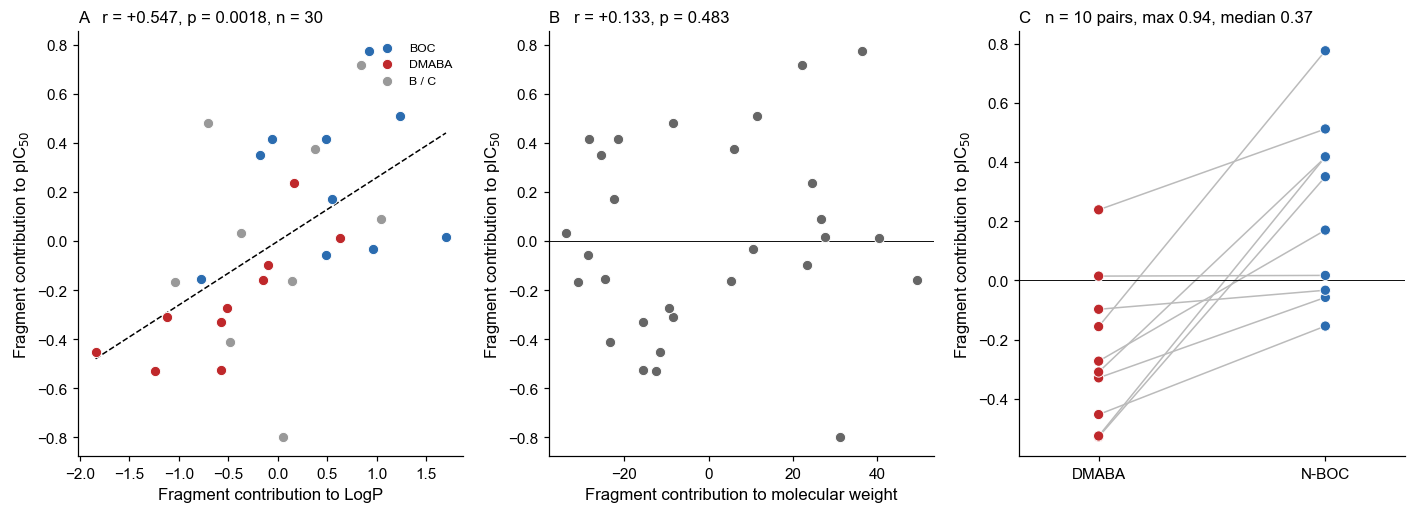

In [80]:
assert {"LogP", "MolWt", "pIC50"} <= set(coef_desc.columns), \
    "coef_desc is stale, re-run the descriptor-refit cell above"
assert "cap" in coef_A.columns, "coef_A is stale, re-run the descriptor-refit cell above"


plt.rcParams.update({"font.size": 11, "axes.labelsize": 11,
                     "axes.titlesize": 11, "xtick.labelsize": 10,
                     "ytick.labelsize": 10, "legend.fontsize": 10})
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))

ax = axes[0]
cap_lbl = np.where(coef_desc.index.str.contains(r"\((?:N-)?BOC\)", regex=True), "BOC",
          np.where(coef_desc.index.str.contains(r"\(DMABA\)", regex=True), "DMABA", "B / C"))
for lab, col in [("BOC", "#2B6CB0"), ("DMABA", "#bf282b"), ("B / C", "#999999")]:
    m = cap_lbl == lab
    ax.scatter(coef_desc.loc[m, "LogP"], coef_desc.loc[m, "pIC50"], c=col, label=lab,
               s=45, edgecolor="white", linewidth=0.6, zorder=3)
r, p = pearsonr(coef_desc["LogP"], coef_desc["pIC50"])
mm, bb = np.polyfit(coef_desc["LogP"], coef_desc["pIC50"], 1)
xs = np.linspace(coef_desc["LogP"].min(), coef_desc["LogP"].max(), 50)
ax.plot(xs, mm * xs + bb, "k--", lw=1, zorder=2)
ax.set_xlabel("Fragment contribution to LogP")
ax.set_ylabel("Fragment contribution to pIC$_{50}$")
ax.set_title(f"A   r = {r:+.3f}, p = {p:.4f}, n = {len(coef_desc)}", loc="left")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
ax.scatter(coef_desc["MolWt"], coef_desc["pIC50"], c="#666666", s=45,
           edgecolor="white", linewidth=0.6, zorder=3)
r, p = pearsonr(coef_desc["MolWt"], coef_desc["pIC50"])
ax.axhline(0, color="k", lw=0.6, zorder=1)
ax.set_xlabel("Fragment contribution to molecular weight")
ax.set_ylabel("Fragment contribution to pIC$_{50}$")
ax.set_title(f"B   r = {r:+.3f}, p = {p:.3f}", loc="left")
ax.set_ylim(axes[0].get_ylim())

ax = axes[2]
base = coef_A.index.str.replace(r"\((?:N-)?BOC\)|\(DMABA\)", "", regex=True)
lad = (coef_A.assign(base=base)
             .pivot(index="base", columns="cap", values="pIC50")
             .dropna().sort_values("BOC"))
for _, row in lad.iterrows():
    ax.plot([0, 1], [row["DMABA"], row["BOC"]], "-", color="#bbbbbb", lw=1, zorder=1)
    ax.scatter([0, 1], [row["DMABA"], row["BOC"]], c=["#bf282b", "#2B6CB0"],
               s=45, edgecolor="white", linewidth=0.6, zorder=3)
ax.set_xticks([0, 1]); ax.set_xticklabels(["DMABA", "N-BOC"]); ax.set_xlim(-0.35, 1.35)
ax.axhline(0, color="k", lw=0.6, zorder=1)
ax.set_ylabel("Fragment contribution to pIC$_{50}$")
cap_diffs = lad["BOC"] - lad["DMABA"]
ax.set_title(f"C   n = {len(lad)} pairs, max {cap_diffs.max():.2f}, median {cap_diffs.median():.2f}",
             loc="left")

plt.tight_layout()

plt.savefig(RESULTS_FIG / "model_evaluation" / "figure5_fragment_descriptor_mapping.png",
            dpi=300, bbox_inches="tight")

plt.savefig(RESULTS_FIG / "model_evaluation" / "figure5_fragment_descriptor_mapping.svg",
            bbox_inches="tight")

print(f"Matched pairs (BOC - DMABA): max {cap_diffs.max():.3f}, median {cap_diffs.median():.3f}, "
      f"all positive = {(cap_diffs > 0).all()}")
plt.show()

**Figure 5.** The fragment contributions track lipophilicity and not size, under the combined 30-term coding. (A) Potency contribution against the contribution of the same fragment to calculated LogP, obtained by refitting the identical design matrix with LogP as the response. (B) The same plot against the molecular-weight contribution, which is flat, so the effect in (A) is not a generic size or volume effect. (C) The ten matched A-fragment pairs, each N-terminal scaffold in its BOC- and DMABA-capped state, connected by a line. The BOC form is the more potent in every pair.

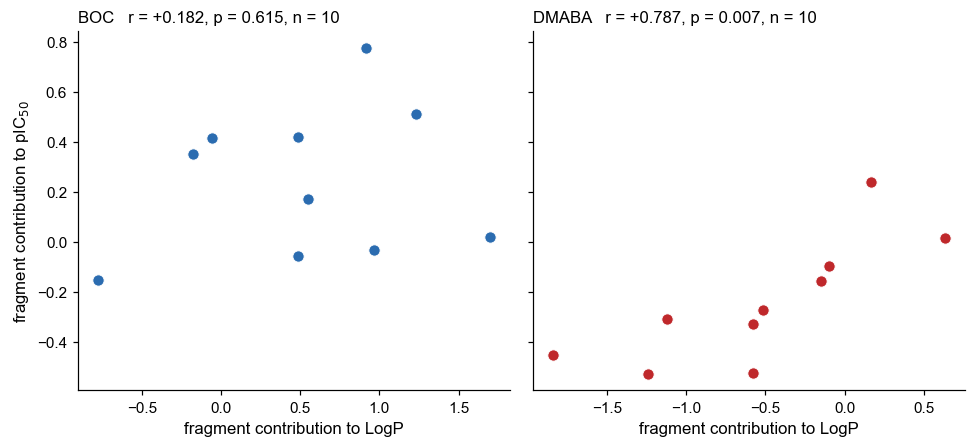

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True)
for ax, (capname, col) in zip(axes, [("BOC", "#2B6CB0"), ("DMABA", "#bf282b")]):
    g = coef_A[coef_A["cap"] == capname]
    ax.scatter(g["LogP"], g["pIC50"], c=col, s=55, edgecolor="white", linewidth=0.6)
    r, p = pearsonr(g["LogP"], g["pIC50"])
    ax.set_title(f"{capname}   r = {r:+.3f}, p = {p:.3f}, n = {len(g)}", loc="left")
    ax.set_xlabel("fragment contribution to LogP")
axes[0].set_ylabel("fragment contribution to pIC$_{50}$")
plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "figureS16_logp_by_cap.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure S16.** Panel A of Figure 5 split by cap. The correlation is present within the DMABA family and is not significant within the BOC family, so part of the overall relationship is separation between the two families.

## 10. Sensitivity, Enrichment and Applicability Domain

### 10.1 Censored-Label Sensitivity and Retrospective Enrichment

In [82]:
cens = censored_flag

keep = ~cens
folds_k = scaffold_split(labelled_df[keep].reset_index(drop=True),
                         n_splits=5, random_state=SEED)
_, br_k = foldwise_cv(br, X_labelled_full[keep], y_labelled[keep], folds_k,
                      return_oof=True)
br_k = np.asarray(br_k)
print("Censored-label sensitivity")
print(f"All 116 compounds  RMSE {np.sqrt(mean_squared_error(y_labelled, br_oof)):.3f}  "
      f"r {pearsonr(y_labelled, br_oof)[0]:.3f}")
print(f"101 uncensored  RMSE {np.sqrt(mean_squared_error(y_labelled[keep], br_k)):.3f}  "
      f"r {pearsonr(y_labelled[keep], br_k)[0]:.3f}")

order = np.argsort(-br_oof)
N = len(y_labelled)
print(f"\nRetrospective enrichment, series median pIC₅₀ {np.median(y_labelled):.2f}\n")
enrich = []
for k in (5, 10, 15, 20, 30):
    hits = len(set(order[:k]) & set(np.argsort(-y_labelled)[:k]))
    p = hypergeom.sf(hits - 1, N, k, k)
    med = np.median(y_labelled[order[:k]])
    enrich.append({"k": k, "recovered": hits, "expected": round(k * k / N, 1),
                   "P_ge": round(p, 4), "median_measured_pIC₅₀": round(med, 2)})
    if k == 20:
        enr20_hits, enr20_exp, enr20_p = hits, k * k / N, p
    print(f"Top-{k}  {hits}/{k} recovered, {k*k/N:.1f} expected, "
          f"P(>= {hits}) = {p:.6f}, median measured pIC₅₀ {med:.2f}")
pd.DataFrame(enrich).to_csv(RESULTS_PRED / "labelled" / "retrospective_enrichment.csv",
                            index=False)

Censored-label sensitivity
All 116 compounds  RMSE 0.738  r 0.566
101 uncensored  RMSE 0.701  r 0.574

Retrospective enrichment, series median pIC₅₀ 4.52

Top-5  0/5 recovered, 0.2 expected, P(>= 0) = 1.000000, median measured pIC₅₀ 5.85
Top-10  2/10 recovered, 0.9 expected, P(>= 2) = 0.206937, median measured pIC₅₀ 5.84
Top-15  4/15 recovered, 1.9 expected, P(>= 4) = 0.104083, median measured pIC₅₀ 5.85
Top-20  9/20 recovered, 3.4 expected, P(>= 9) = 0.001218, median measured pIC₅₀ 5.84
Top-30  18/30 recovered, 7.8 expected, P(>= 18) = 0.000003, median measured pIC₅₀ 5.78


Dropping the fifteen censored labels reduces RMSE from 0.738 to 0.701 and increases Pearson r from 0.566 to 0.574, so the boundary substituted values are not the main source of error. The comparison also rebuilds the folds using 101 compounds and removes the least potent compounds, meaning that part of the improvement is due to these changes and not better model performance.

The retrospective enrichment recovers 9 of the top 20 and 18 of the top 30 measured actives, against 3.4 and 7.8 expected, with hypergeometric P of 0.001 and below 0.001. The top 5, 10 and 15 do not reach significance. The model identifies the more potent compounds as a group but does not reliably identify the single most potent compound.

### 10.2 Applicability Domain of the Unlabelled Set

The primary Bayesian Ridge model and the RF-GP ensemble are applied to the 2,535 unlabelled compounds for three purposes only. The first is to establish whether the nearest-neighbour Tanimoto applicability domain excludes any compounds within the library. The second is to assess agreement between the two models on the same inputs. The third is a consistency check on the one compound whose source tables disagreed.

In [83]:
nn_tanimoto_unl, in_domain_unl = compute_applicability_domain(
    unlabelled_fps, train_fps, threshold=0.4)

pred_br_unl = br.predict(X_unlabelled_full)
pred_ens_unl = w_rf * rf.predict(X_unlabelled_full) + w_gp * gpr.predict(X_unlabelled_full)

print(f"Unlabelled compounds: {len(unlabelled_df)}")
print(f"Inside the Tanimoto 0.4 domain: {int(in_domain_unl.sum())} of {len(in_domain_unl)}")
print(f"Nearest-neighbour Tanimoto range: {nn_tanimoto_unl.min():.2f}-{nn_tanimoto_unl.max():.2f}")

print(f"Predicted pIC₅₀ range across the unlabelled set: "
      f"{pred_br_unl.min():.2f}-{pred_br_unl.max():.2f} "
      f"(range {pred_br_unl.max() - pred_br_unl.min():.2f} log units)")

rho_unl, _ = spearmanr(pred_br_unl, pred_ens_unl)
print(f"\nBayesian Ridge against RF-GP ensemble on the unlabelled set: "
      f"Spearman rho = {rho_unl:.3f}")

CPD128 = "COC(=O)c1cc(NC(=O)c2cc3cc(NC(=O)c4cc5cc(NC(=O)CCCN(C)C)ccc5[nH]4)ccc3s2)cn1C"
_key128 = canonical_smiles(CPD128)
_m128 = unlabelled_df["SMILES"].map(canonical_smiles) == _key128
if _m128.any():
    _i = int(np.flatnonzero(_m128.values)[0])
    print(f"\nCompound 128 curation check, excluded from training on conflicting "
          f"source values of 32 µM (pIC₅₀ 4.49) and 17 µM (pIC₅₀ 4.77)")
    print(f"Predicted pIC₅₀, Bayesian Ridge {pred_br_unl[_i]:.2f}, ensemble {pred_ens_unl[_i]:.2f}")
else:
    print("\nCompound 128 not located in the unlabelled set, check the SMILES above")

Unlabelled compounds: 2535
Inside the Tanimoto 0.4 domain: 2535 of 2535
Nearest-neighbour Tanimoto range: 0.47-1.00
Predicted pIC₅₀ range across the unlabelled set: 3.22-6.19 (range 2.98 log units)

Bayesian Ridge against RF-GP ensemble on the unlabelled set: Spearman rho = 0.989

Compound 128 curation check, excluded from training on conflicting source values of 32 µM (pIC₅₀ 4.49) and 17 µM (pIC₅₀ 4.77)
Predicted pIC₅₀, Bayesian Ridge 4.85, ensemble 4.90


All 2,535 unlabelled compounds fall inside the Tanimoto 0.4 domain, with nearest neighbour similarity ranging from 0.47 to 1.00. The filter therefore does not exclude any compounds from this library and does not distinguish between compounds.

Bayesian Ridge and the RF-GP ensemble agree at Spearman ρ = 0.989 on the same inputs, so the choice between them would not change the ordering.

Compound 128 is predicted at 4.85 by Bayesian Ridge and 4.90 by the ensemble, compared with conflicting source values of 4.49 and 4.77. Both predictions are slightly above the higher of the two readings and within the model RMSE, so neither source value can be selected based on the model predictions. The compound is therefore excluded from training.

The two source readings for this compound differ by 0.28 pIC₅₀ units under the same assay protocol. This is the only estimate of label reproducibility available within the dataset, compared with a pooled out-of-fold RMSE of 0.738 on the labelled set.

## 11. Calibration of the Gaussian Process Uncertainty Estimate

This section evaluates the uncertainty estimate that was the ensemble's stated rationale. Its failure to distinguish between molecules is the reason the ensemble was not retained for further analysis (Section 8). The Gaussian Process estimate is assessed first because it is the base model for the ensemble. Section 11.7 applies the same checks to Bayesian Ridge predictive standard deviation, showing that the finding is not specific to the model used in the ensemble.

An uncertainty estimate is useful only if it is calibrated, meaning that the predicted uncertainty corresponds to the observed prediction error. We check this in three ways, with a calibration curve of RMSE per uncertainty bin, a reliability diagram of observed against expected interval coverage, and the Spearman correlation between uncertainty and absolute error.

Interval bands are based on the GP posterior standard deviation reported around the ensemble mean without rescaling by w_GP. Since the results below show that this σ does not distinguish between molecules, it is treated only as an indicative uncertainty width.

### 11.1 Collect OOF GP Uncertainty Estimates

In [84]:
print("Collecting OOF GP uncertainty")

gpr_oof_preds = np.zeros(len(y_labelled))
gpr_oof_stds = np.zeros(len(y_labelled))
rf_oof_preds = np.zeros(len(y_labelled))

for test_idx in folds:
    test_idx = np.array(test_idx)
    test_set = set(test_idx.tolist())
    train_idx = np.array([i for i in range(len(y_labelled)) if i not in test_set])

    X_train, X_test = X_labelled_full[train_idx], X_labelled_full[test_idx]
    y_train = y_labelled[train_idx]

    # GP refit per fold on its own training set, so these are OOF estimates and not the full-data fit
    kernel_fold = RBF(length_scale=best_gp_params['length_scale']) + WhiteKernel(noise_level=best_gp_params['noise_level'])
    gpr_fold = build_pipeline("gp", kernel=kernel_fold, n_restarts_optimizer=2, random_state=SEED)
    gpr_fold.fit(X_train, y_train)

    rf_fold = build_pipeline(
        "random_forest",
        random_state=SEED,
        n_jobs=-1,
        n_estimators=best_rf_params['n_estimators'],
        max_depth=best_rf_params['max_depth'],
        min_samples_split=best_rf_params['min_samples_split'],
        min_samples_leaf=best_rf_params['min_samples_leaf']
    )
    rf_fold.fit(X_train, y_train)

    gpr_oof_preds[test_idx], gpr_oof_stds[test_idx] = gp_predict_with_std(gpr_fold, X_test)
    rf_oof_preds[test_idx] = rf_fold.predict(X_test)

ensemble_oof_calib = w_rf * rf_oof_preds + w_gp * gpr_oof_preds
residuals = np.abs(y_labelled - ensemble_oof_calib)

print(f"OOF GP uncertainty: mean={gpr_oof_stds.mean():.3f}, min={gpr_oof_stds.min():.3f}, max={gpr_oof_stds.max():.3f}")

OOF GP uncertainty: mean=0.770, min=0.679, max=1.056


This OOF mean comes from per-fold GP refits, so it will not match the single full-data in-sample figure in Section 9.2 exactly.

### 11.2 Calibration Curve of Uncertainty vs Actual Error

Calibration curve
10 uncertainty bins, none merged


**Table S16.** Calibration of GP uncertainty against observed ensemble RMSE (OOF).

Bin,Mean_Uncert,RMSE,N_molecules
0,0.6930,0.9161,12
1,0.7158,0.9739,12
2,0.7277,0.8473,11
3,0.7397,0.9063,12
4,0.7536,0.5916,11
5,0.7676,0.5814,12
6,0.7810,0.5368,11
7,0.7943,0.6281,12
8,0.8232,0.6497,11
9,0.9090,0.7186,12


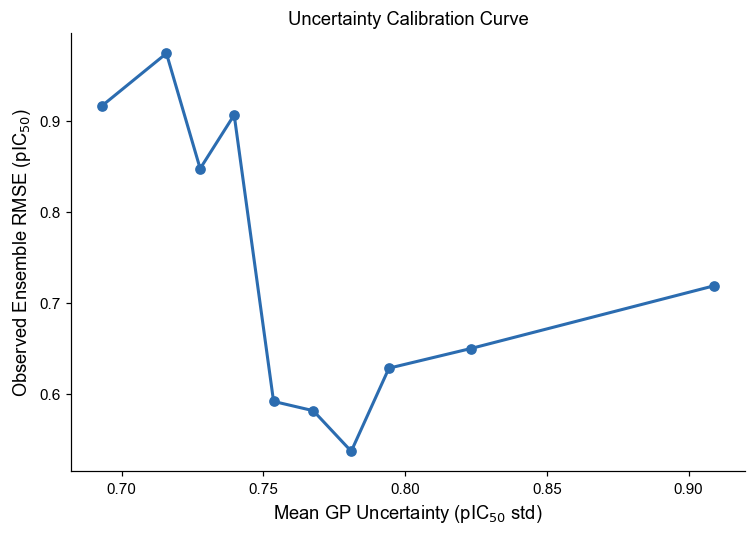

In [85]:
print("Calibration curve")

N_BINS = 10
uncertainty_bins = pd.qcut(gpr_oof_stds, q=N_BINS, labels=False, duplicates='drop')

bin_stats = []
for b in sorted(np.unique(uncertainty_bins)):
    mask = uncertainty_bins == b
    mean_uncert = gpr_oof_stds[mask].mean()
    bin_rmse = np.sqrt(mean_squared_error(y_labelled[mask], ensemble_oof_calib[mask]))
    bin_stats.append({
        'Bin': int(b),
        'Mean_Uncert': round(mean_uncert, 4),
        'RMSE': round(bin_rmse, 4),
        'N_molecules': int(mask.sum())
    })


calib_df = pd.DataFrame(bin_stats)

actual_bins = len(calib_df)
if actual_bins < N_BINS:
    print(f"Note: duplicates='drop' reduced bins from {N_BINS} to {actual_bins}")
else:
    print(f"{N_BINS} uncertainty bins, none merged")

display(Markdown("**Table S16.** Calibration of GP uncertainty against observed ensemble RMSE (OOF)."))
show(calib_df)

plt.figure(figsize=(7, 5))
plt.plot(calib_df['Mean_Uncert'], calib_df['RMSE'], marker='o', linewidth=2)
plt.xlabel('Mean GP Uncertainty (pIC$_{50}$ std)', fontsize=12)
plt.ylabel('Observed Ensemble RMSE (pIC$_{50}$)', fontsize=12)
plt.title('Uncertainty Calibration Curve',
          fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "calibration_curve.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S17.** Observed ensemble RMSE against Mean GP uncertainty, binned out-of-fold (n = 116).

In Table S16 the RMSE varies irregularly from one uncertainty bin to the next with no steady trend. Section 11.4 quantifies this with the Spearman test.

### 11.3 Reliability Diagram of Expected vs Observed Coverage

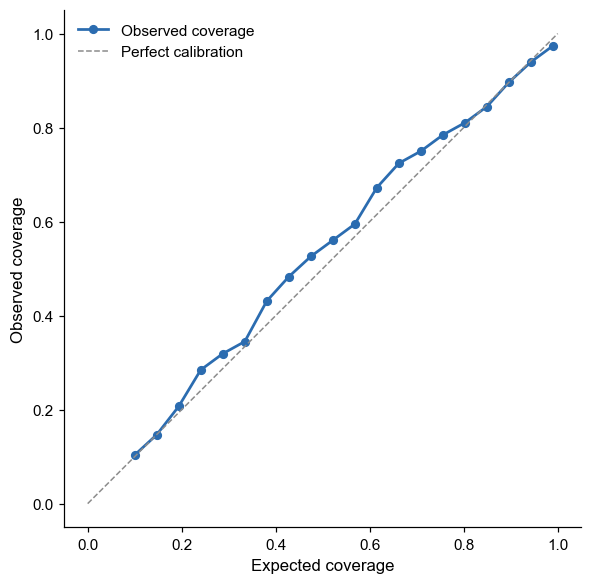

In [86]:
confidence_levels = np.linspace(0.1, 0.99, 20)
observed_coverage = []

for cl in confidence_levels:
    z = norm.ppf(1 - (1 - cl) / 2)
    lower = ensemble_oof_calib - z * gpr_oof_stds
    upper = ensemble_oof_calib + z * gpr_oof_stds
    coverage = np.mean((y_labelled >= lower) & (y_labelled <= upper))
    observed_coverage.append(coverage)

plt.figure(figsize=(5.5, 5.5))
plt.plot(confidence_levels, observed_coverage, marker='o', markersize=5,
         linewidth=1.8, color='#2B6CB0', label='Observed coverage')
plt.plot([0, 1], [0, 1], color='0.55', linestyle='--', linewidth=1,
         label='Perfect calibration')
plt.xlabel('Expected coverage')
plt.ylabel('Observed coverage')
plt.gca().set_aspect('equal')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_FIG / "model_evaluation" / "reliability_diagram.png", dpi=300, bbox_inches='tight')
plt.show();

**Figure S2.** Reliability diagram showing observed against expected coverage of GP prediction intervals, out of fold, n = 116.

Across most confidence levels, the observed coverage is above the diagonal, indicating that the intervals are wider than necessary, while the curve approaches the diagonal at the highest confidence levels. At the 90% level the difference between observed and expected coverage is within the ±5 percentage point tolerance specified in Section 11.4.

### 11.4 Calibration Summary and Interpretation

In [87]:
print("Calibration summary")

spearman_r, spearman_p = spearmanr(gpr_oof_stds, residuals)
print(f"Spearman ρ (uncertainty vs error): {spearman_r:.3f} (p = {spearman_p:.3f})")

if spearman_r > 0 and spearman_p < 0.05:
    print("Uncertainty vs error: positive and significant")
elif spearman_r > 0 and spearman_p >= 0.05:
    print("Uncertainty vs error: positive, not significant")
else:
    print("Uncertainty vs error: not positively correlated")

idx_90 = np.argmin(np.abs(confidence_levels - 0.90))
observed_90 = observed_coverage[idx_90]
coverage_gap = observed_90 - 0.90
print(f"90% nominal coverage: observed = {observed_90:.3f} (gap = {coverage_gap:+.3f})")

if abs(coverage_gap) < 0.05:
    print("Well-calibrated at 90% level")
elif coverage_gap < -0.05:
    print("Over-confident (observed coverage below nominal)")
else:
    print("Under-confident (observed coverage above nominal)")

Calibration summary
Spearman ρ (uncertainty vs error): -0.144 (p = 0.123)
Uncertainty vs error: not positively correlated
90% nominal coverage: observed = 0.897 (gap = -0.003)
Well-calibrated at 90% level


### 11.5 Implications for Interpretation

The reliability diagram and the Spearman test agree that the GP intervals are approximately calibrated on average but do not distinguish between molecules, so the interval on any single prediction should be treated as an approximate bound rather than a ranking criterion.

The likely cause is the RBF kernel, which measures Euclidean distance and is not well suited to binary fingerprint space. The alternative is a Tanimoto kernel working directly on the Morgan fingerprints, introduced for this type of molecular data (9). It does not improve the uncertainty estimate, and this lack of improvement is informative.

### 11.6 Kernel Sensitivity, RBF vs Tanimoto on Binary Fingerprint Space

Section 11.5 attributes the per-molecule uncertainty failure to the radial basis function kernel, which applies a Euclidean geometry to binary fingerprint space, where the Tanimoto coefficient is more appropriate (9). The comparison in Table S5 is controlled, with the same Gaussian Process settings, the same scaffold folds, the same hyperparameter grid, and the same 1024-bit binary block with no descriptors and no scaling. The tuned Gaussian Process of Section 7.2 uses all 1030 features with a StandardScaler and so is not directly comparable to either condition. The effect of the kernel is therefore assessed from the difference between the two fits here.

In [88]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

X_bits = X_labelled_full[:, :-6]
assert set(np.unique(X_bits)).issubset({0.0, 1.0}), "fingerprint block is not binary"
assert not np.any(X_bits.sum(axis=1) == 0), "all-zero fingerprint row (Tanimoto undefined)"
print(f"Binary block: {X_bits.shape}, bit density {X_bits.mean():.4f}\n")

def _gp_oof(kernel_factory):
    """Scaffold-CV out-of-fold GP predictions, stds and per-fold metrics."""
    preds = np.zeros(len(y_labelled))
    stds = np.zeros(len(y_labelled))
    fold_rmse, fold_r2 = [], []
    for test_idx in folds:
        test_idx = np.asarray(test_idx)
        test_set = set(test_idx.tolist())
        train_idx = np.array([i for i in range(len(y_labelled)) if i not in test_set])
        g = GaussianProcessRegressor(kernel=kernel_factory(), normalize_y=True,
                                     n_restarts_optimizer=2, random_state=SEED)
        g.fit(X_bits[train_idx], y_labelled[train_idx])
        p, s = g.predict(X_bits[test_idx], return_std=True)
        preds[test_idx], stds[test_idx] = p, s
        fold_rmse.append(np.sqrt(mean_squared_error(y_labelled[test_idx], p)))
        fold_r2.append(r2_score(y_labelled[test_idx], p))
    return preds, stds, np.array(fold_rmse), np.array(fold_r2)

kernel_arms = {
    "Tanimoto (1024 bits)": (
        {'variance': [0.1, 0.5, 1.0, 2.0, 5.0],
         'noise_level': [1e-3, 1e-2, 1e-1, 3e-1, 1.0]},
        lambda p: TanimotoKernel(variance=p['variance']) + WhiteKernel(noise_level=p['noise_level'])),
    "RBF (1024 bits)": (
        {'length_scale': [1.0, 5.0, 10.0, 20.0, 50.0],
         'noise_level': [1e-3, 1e-2, 1e-1, 3e-1, 1.0]},
        lambda p: RBF(length_scale=p['length_scale']) + WhiteKernel(noise_level=p['noise_level'])),
}

kernel_rows = []
for arm_name, (grid, make_kernel) in kernel_arms.items():
    best = None
    for params in ParameterGrid(grid):
        pr, st, frm, fr2 = _gp_oof(lambda p=params: make_kernel(p))
        if best is None or frm.mean() < best[0]:
            best = (float(frm.mean()), params, pr, st, frm, fr2)
    rmse_fold, params, pr, st, frm, fr2 = best

    resid = np.abs(y_labelled - pr)
    sp_r, sp_p = spearmanr(st, resid)
    cov90 = float(np.mean(resid <= norm.ppf(0.95) * st))

    kernel_rows.append({
        "Kernel": arm_name,
        "Best_params": str(params),
        "RMSE_foldavg": round(rmse_fold, 3),
        "RMSE_foldsd": round(float(frm.std(ddof=1)), 3),
        "R2_foldavg": round(float(fr2.mean()), 3),
        "RMSE_pooled": round(float(np.sqrt(mean_squared_error(y_labelled, pr))), 3),
        "R2_pooled": round(float(r2_score(y_labelled, pr)), 3),
        "Pearson_pooled": round(float(pearsonr(y_labelled, pr)[0]), 3),
        "Unc_vs_err_rho": round(float(sp_r), 3),
        "Unc_vs_err_p": round(float(sp_p), 3),
        "Coverage_90": round(cov90, 3),
        "Mean_std": round(float(st.mean()), 3),
        "SD_of_std": round(float(st.std(ddof=1)), 4),
    })
    print(f"{arm_name:22s} | {str(params):48s}\n"
          f"{'':22s} | RMSE (fold-avg) {rmse_fold:.3f} ± {frm.std(ddof=1):.3f} | "
          f"RMSE (pooled) {np.sqrt(mean_squared_error(y_labelled, pr)):.3f}\n"
          f"{'':22s} | uncertainty-vs-error ρ {sp_r:+.3f} (p = {sp_p:.3f}) | "
          f"90% coverage {cov90:.3f} | mean(sigma) {st.mean():.3f} | "
          f"sd(sigma) {st.std(ddof=1):.4f}\n")

kernel_df = pd.DataFrame(kernel_rows)
display(Markdown("**Table S5.** Gaussian Process kernel comparison on the 1024-bit "
                 "binary fingerprint block, RBF against Tanimoto, under 5-fold "
                 "scaffold cross-validation, with both fold-averaged and pooled metrics reported."))
show(kernel_df)
kernel_df.to_csv(RESULTS_PRED / "labelled" / "gp_kernel_comparison.csv", index=False)

Binary block: (116, 1024), bit density 0.0620

Tanimoto (1024 bits)   | {'noise_level': 0.01, 'variance': 0.5}          
                       | RMSE (fold-avg) 0.747 ± 0.097 | RMSE (pooled) 0.752
                       | uncertainty-vs-error ρ -0.168 (p = 0.071) | 90% coverage 0.871 | mean(sigma) 0.762 | sd(sigma) 0.0396

RBF (1024 bits)        | {'length_scale': 5.0, 'noise_level': 0.3}       
                       | RMSE (fold-avg) 0.748 ± 0.096 | RMSE (pooled) 0.754
                       | uncertainty-vs-error ρ -0.180 (p = 0.054) | 90% coverage 0.897 | mean(sigma) 0.761 | sd(sigma) 0.0392



**Table S5.** Gaussian Process kernel comparison on the 1024-bit binary fingerprint block, RBF against Tanimoto, under 5-fold scaffold cross-validation, with both fold-averaged and pooled metrics reported.

Kernel,Best_params,RMSE_foldavg,RMSE_foldsd,R2_foldavg,RMSE_pooled,R2_pooled,Pearson_pooled,Unc_vs_err_rho,Unc_vs_err_p,Coverage_90,Mean_std,SD_of_std
Tanimoto (1024 bits),"{'noise_level': 0.01, 'variance': 0.5}",0.747,0.097,0.265,0.752,0.294,0.542,-0.168,0.071,0.871,0.762,0.0396
RBF (1024 bits),"{'length_scale': 5.0, 'noise_level': 0.3}",0.748,0.096,0.260,0.754,0.291,0.540,-0.180,0.054,0.897,0.761,0.0392


The two kernels cannot be distinguished on accuracy, at fold-averaged RMSE 0.747 against 0.748, or on uncertainty, at ρ = −0.168 against −0.180.

This explains the result reported in Section 11.5. The standard deviation of the posterior uncertainty across molecules is about 0.039, against a mean of 0.761. Both kernels therefore return an almost constant σ, and a quantity with so little variation cannot meaningfully rank molecules. The comparison therefore does not identify the kernel as the cause of the weak uncertainty ranking. The sample size and the flatness of the potency signal are possible explanations, but are not tested directly here.

### 11.7 Bayesian Ridge Predictive Uncertainty

Bayesian Ridge is the primary model and gives a predictive standard deviation, so the same three checks are applied here. The out-of-fold estimates use the same scaffold folds and tuned settings throughout, with the model refitted within each fold which keeps the σ values out of sample.

In [89]:
br_mu_oof = np.zeros(len(y_labelled))
br_sigma_oof = np.zeros(len(y_labelled))

for test_idx in folds:
    test_idx = np.asarray(test_idx)
    test_set = set(test_idx.tolist())
    train_idx = np.array([i for i in range(len(y_labelled)) if i not in test_set])

    br_fold = build_br(**best_br_params)
    br_fold.fit(X_labelled_full[train_idx], y_labelled[train_idx])

    X_test_scaled = br_fold.named_steps['scaler'].transform(X_labelled_full[test_idx])
    br_mu_oof[test_idx], br_sigma_oof[test_idx] = br_fold.named_steps['model'].predict(
        X_test_scaled, return_std=True)

br_resid = np.abs(y_labelled - br_mu_oof)
br_rho, br_rho_p = spearmanr(br_sigma_oof, br_resid)
br_cov90 = float(np.mean(br_resid <= norm.ppf(0.95) * br_sigma_oof))

print(f"Bayesian Ridge | mean σ {br_sigma_oof.mean():.3f} | "
      f"sd(σ) {br_sigma_oof.std(ddof=1):.4f} | "
      f"uncertainty-vs-error ρ {br_rho:+.3f} (p = {br_rho_p:.3f}) | "
      f"90% coverage {br_cov90:.3f}")

print(f"Gaussian Process | mean σ {gpr_oof_stds.mean():.3f} | "
      f"sd(σ) {gpr_oof_stds.std(ddof=1):.4f} | "
      f"uncertainty-vs-error ρ {spearman_r:+.3f} (p = {spearman_p:.3f}) | "
      f"90% coverage {observed_90:.3f}")

Bayesian Ridge | mean σ 0.752 | sd(σ) 0.0632 | uncertainty-vs-error ρ -0.185 (p = 0.047) | 90% coverage 0.897
Gaussian Process | mean σ 0.770 | sd(σ) 0.0626 | uncertainty-vs-error ρ -0.144 (p = 0.123) | 90% coverage 0.897


Both models produce a near-constant σ, varying by only around 8% of its mean in each case. Neither shows a positive rank correlation with absolute error. Although the 90% coverage is close to the nominal level for both models, this does not indicate a useful per-molecule uncertainty. Using Bayesian Ridge as the primary model would therefore not have provided a meaningful per-molecule uncertainty either, so the conclusion in Section 11.5 is not dependent on which model was used for the estimate.

## 12. Summary

### Key Results

In [90]:
r_br, _ = pearsonr(y_labelled, br_oof)
rmse_br = np.sqrt(mean_squared_error(y_labelled, br_oof))
r2_br = r2_score(y_labelled, br_oof)
rmse_ens = np.sqrt(mean_squared_error(y_labelled, ensemble_oof_final))
n_cens = int(cens.sum())

rmse_br_foldavg = results_df.loc[results_df['Model'] == 'Bayesian Ridge', 'RMSE_Tuned'].iloc[0]

display(Markdown(f"""
**Table S17.** Summary of key quantitative results, generated from this analysis.

| Metric | Value |
|--------|-------|
| Labelled / unlabelled compounds | {len(labelled_df)} / {len(unlabelled_df)} |
| Bayesian Ridge (primary) OOF RMSE, fold-averaged | {rmse_br_foldavg:.3f} |
| Bayesian Ridge (primary) OOF RMSE, pooled | {rmse_br:.3f} |
| Bayesian Ridge (primary) OOF R² / Pearson r, pooled | {r2_br:.3f} / {r_br:.3f} |
| Bayesian Ridge (primary) OOF Spearman ρ | {rho_br:.3f} |
| Retrospective enrichment, top 20 | {enr20_hits}/20 recovered, {enr20_exp:.1f} expected, P = {enr20_p:.3f} |
| RF-GP ensemble OOF RMSE, pooled (comparison) | {rmse_ens:.3f} (95% CI [{ci_rmse[0]:.3f}-{ci_rmse[1]:.3f}]) |
| Nested-CV RMSE (RF backbone) | {nested_rmse_mean:.3f} ± {nested_rmse_std:.3f} |
| Free-Wilson scaffold-CV R², combined A coding, uncensored | {fw_unc_scaffold_r2:.3f} |
| Free-Wilson scaffold-CV R², split stem and cap coding, uncensored | {cv_rows[1]["R2_scaffold"]:.3f} |
| GP 90% interval coverage | {observed_90:.3f} |
| GP uncertainty Spearman ρ vs error | {spearman_r:.3f} (p = {spearman_p:.3f}) |
| Censored compounds | {n_cens} |
"""))


**Table S17.** Summary of key quantitative results, generated from this analysis.

| Metric | Value |
|--------|-------|
| Labelled / unlabelled compounds | 116 / 2535 |
| Bayesian Ridge (primary) OOF RMSE, fold-averaged | 0.732 |
| Bayesian Ridge (primary) OOF RMSE, pooled | 0.738 |
| Bayesian Ridge (primary) OOF R² / Pearson r, pooled | 0.319 / 0.566 |
| Bayesian Ridge (primary) OOF Spearman ρ | 0.541 |
| Retrospective enrichment, top 20 | 9/20 recovered, 3.4 expected, P = 0.001 |
| RF-GP ensemble OOF RMSE, pooled (comparison) | 0.759 (95% CI [0.655-0.863]) |
| Nested-CV RMSE (RF backbone) | 0.759 ± 0.144 |
| Free-Wilson scaffold-CV R², combined A coding, uncensored | 0.360 |
| Free-Wilson scaffold-CV R², split stem and cap coding, uncensored | 0.407 |
| GP 90% interval coverage | 0.897 |
| GP uncertainty Spearman ρ vs error | -0.144 (p = 0.123) |
| Censored compounds | 15 |


The pipeline trains four model families under scaffold-based cross-validation and fits an additive fragment model on the combinatorial subset, with the headline numbers in Table S17.

### Uncertainty

The GP uncertainty estimates calibrate well on average but do not separate molecules individually. Replacing the RBF kernel with a Tanimoto kernel on the binary fingerprint block does not improve that separation (Section 11.6), and neither does the Bayesian Ridge predictive standard deviation (Section 11.7). No per-prediction uncertainty is therefore reported for any model.

### Limitations

Fifteen labelled compounds are censored readings represented by their boundary pIC₅₀ values and treated as exact values. Section 10 quantifies the effect of excluding them. The fragment contributions describe this library and should not be expected to transfer to structurally distinct minor-groove binders.

In [91]:
saved_files = [
    RESULTS_PRED / "labelled" / "RF_GP_ensemble_labelled_insample.csv",
    RESULTS_PRED / "labelled" / "retrospective_enrichment.csv",
    RESULTS_PRED / "labelled" / "descriptor_pIC50_correlations.csv",
    RESULTS_PRED / "labelled" / "feature_block_comparison.csv",
    RESULTS_PRED / "labelled" / "gp_kernel_comparison.csv",
    RESULTS_PRED / "free_wilson_fragment_contributions_ci.csv",
    RESULTS_PRED / "logp_partial_correlations.csv",
    RESULTS_PRED / "shape_descriptors_uncensored.csv",
    RESULTS_PRED / "fragment_descriptor_coefficients.csv",
    RESULTS_PRED / "free_wilson_Asplit_contributions_ci.csv",
    RESULTS_PRED / "free_wilson_Asplit_cv.csv",
    RESULTS_PRED / "free_wilson_position_variance.csv",
    RESULTS_PRED / "model_comparison_matched.csv",
    RESULTS_FIG / "eda" / "chembl_l1210_neighbours_a.png",
    RESULTS_FIG / "eda" / "chembl_l1210_neighbours_b.png",
    MODELS_DIR / "rf_pipeline.pkl",
    MODELS_DIR / "gp_pipeline.pkl",
    MODELS_DIR / "xgb_pipeline.pkl",
    MODELS_DIR / "bayesian_ridge_pipeline.pkl",
    MODELS_DIR / "RF_GP_ensemble.pkl",
]

missing = [f for f in saved_files if not f.exists()]
assert not missing, f"Missing output files: {missing}"

## References

1. Boger DL, Fink BE, Hedrick MP. Total Synthesis of Distamycin A and 2640 Analogues: A Solution-Phase Combinatorial Approach to the Discovery of New, Bioactive DNA Binding Agents and Development of a Rapid, High-Throughput Screen for Determining Relative DNA Binding Affinity or DNA Binding Sequence Selectivity. Journal of the American Chemical Society. 2000;122(27):6382–94.

2. Boger DL, Dechantsreiter MA, Ishii T, Fink BE, Hedrick MP. Assessment of solution-phase positional scanning libraries based on distamycin A for the discovery of new DNA binding agents. Bioorg Med Chem. 2000;8(8):2049–57.

3. Bemis GW, Murcko MA. The properties of known drugs. 1. Molecular frameworks. J Med Chem. 1996;39(15):2887–93.

4. Belfield SJ, Cronin MTD, Enoch SJ, Firman JW. Guidance for good practice in the application of machine learning in development of toxicological quantitative structure-activity relationships (QSARs). PLoS One. 2023;18(5):e0282924.

5. Sheridan RP. Time-split cross-validation as a method for estimating the goodness of prospective prediction. J Chem Inf Model. 2013;53(4):783–90.

6. Wallach I, Heifets A. Most Ligand-Based Classification Benchmarks Reward Memorization Rather than Generalization. J Chem Inf Model. 2018;58(5):916–32.

7. Lundberg S, Lee S-I. A Unified Approach to Interpreting Model Predictions. Advances in Neural Information Processing Systems. 2017;30:4765–74.

8. Lundberg SM, Erion G, Chen H, DeGrave A, Prutkin JM, Nair B, et al. From Local Explanations to Global Understanding with Explainable AI for Trees. Nat Mach Intell. 2020;2(1):56–67.

9. Ralaivola L, Swamidass SJ, Saigo H, Baldi P. Graph kernels for chemical informatics. Neural Netw. 2005;18(8):1093–110.



End of Supporting Information.